# DSC 478 Final Project
---
##### Project Type: Data Analysis
##### Team Members [student ID]: Mohammed Musaddiq Vavartar [2110431]
##### Course: DSC 478 - Programming Machine Learning Applications
##### Instructor: Bamshad Mobasher
---

### *Project Title* : Understanding Public Sentiment and Opinion on the Israel-Palestine Conflict Through Reddit Discourse.


## *Section 1* : Intial Setup

Here is where we set up our environment. We will attach Google Drive to store our files,
install our necessary libraries, connect to Kaggle to download the dataset, and take a
quick first look at the data structure.

In [ ]:
# 1.1 All data, outputs are stored in google drive
# Mouting Google drive

# same for all gdrive whoever runs
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1.2 Creating a directory DSC478_project/data, DSC478_project/outputs
# making my own project folder in drive to store
import os

# custom dir
prj_directory = '/content/drive/MyDrive/DSC478_Project'
os.makedirs(prj_directory, exist_ok=True)
#checks
os.makedirs(f'{prj_directory}/data', exist_ok=True)
os.makedirs(f'{prj_directory}/outputs', exist_ok=True)

print("Folders created:")
# aux files
print(f"  {prj_directory}/data       CSVs go here")
print(f"  {prj_directory}/outputs    saved results, models, plots")


Folders created:
  /content/drive/MyDrive/DSC478_Project/data       CSVs go here
  /content/drive/MyDrive/DSC478_Project/outputs    saved results, models, plots


In [ ]:
# 1.3 Basic libraries, Others will be imported as I progress due to google colab runtime reset, libraries will be import in multiple cells
# Intial libraries I need for this project
!pip install -q vaderSentiment
!pip install -q transformers
!pip install -q pyLDAvis
!pip install -q langdetect

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 88.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 33.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# 1.4 kaggle API Token

Kaggle_api_token = "KGAT_18e10491e606b9eedceecd00d87c2fc8"

os.environ["KAGGLE_API_TOKEN"] = Kaggle_api_token

print("Kaggle API token set!")

Kaggle API token set!


In [ ]:
# 1.5 Getting Dataset
!kaggle datasets download -d asaniczka/reddit-on-israel-palestine-daily-updated \
    -p {prj_directory}/data --unzip

Dataset URL: https://www.kaggle.com/datasets/asaniczka/reddit-on-israel-palestine-daily-updated
License(s): ODC Attribution License (ODC-By)
100% 1.41G/1.41G [00:38<00:00, 39.5MB/s]



In [ ]:
# 1.5 I compressed it and downloaded, now checking the actual size ( should be approx 6GB according to the URL given)
data_dir = f'{prj_directory}/data'

print("-" * 50)
print("DATASET FILE SIZES")
print("-" * 50)

# loading
for f in os.listdir(data_dir):
    path = os.path.join(data_dir, f)

    # if it's a folder, list files inside it
    if os.path.isdir(path):
        for inner_f in os.listdir(path):
          # main path
            inner_path = os.path.join(path, inner_f)
            size_gb = os.path.getsize(inner_path) / (1024**3)
            print(f"{f}/{inner_f}    {size_gb:.2f} GB")
    else:
      # size compare
        size_gb = os.path.getsize(path) / (1024**3)
        print(f"{f}    {size_gb:.2f} GB")

--------------------------------------------------
DATASET FILE SIZES
--------------------------------------------------
legacy/pse_isr_reddit_comments.csv    0.21 GB
legacy_filtered.csv    0.11 GB
reddit_opinion_PSE_ISR.csv    5.82 GB
main_filtered.csv    1.44 GB
post_2024.csv    1.28 GB
pre_2024.csv    0.15 GB


In [ ]:
# 1.6 printing head ( first 5 ) to show what the dataset contains
import pandas as pd

# paths for both datasets
data_path   = f'{prj_directory}/data/reddit_opinion_PSE_ISR.csv'
legacy_path = f'{prj_directory}/data/legacy/pse_isr_reddit_comments.csv'

# read first 5 rows of each  avoids loading full files into RAM
df_main_peek   = pd.read_csv(data_path,   nrows=5)
df_legacy_peek = pd.read_csv(legacy_path, nrows=5)

print("-" * 50)
#details check
print("Main Dataset (post-2024)")
print("-" * 50)
print(f"Columns count : {df_main_peek.shape[1]}")
print(f"Column names  : {df_main_peek.columns.tolist()}")

print("-" * 50)
#deatail check
print("Legacy Dataset (pre-2024)")
print("-" * 50)
print(f"Columns count : {df_legacy_peek.shape[1]}")
print(f"Column names  : {df_legacy_peek.columns.tolist()}")

--------------------------------------------------
Main Dataset (post-2024)
--------------------------------------------------
Columns count : 24
Column names  : ['comment_id', 'score', 'self_text', 'subreddit', 'created_time', 'post_id', 'author_name', 'controversiality', 'ups', 'downs', 'user_is_verified', 'user_account_created_time', 'user_awardee_karma', 'user_awarder_karma', 'user_link_karma', 'user_comment_karma', 'user_total_karma', 'post_score', 'post_self_text', 'post_title', 'post_upvote_ratio', 'post_thumbs_ups', 'post_total_awards_received', 'post_created_time']
--------------------------------------------------
Legacy Dataset (pre-2024)
--------------------------------------------------
Columns count : 5
Column names  : ['comment_id', 'score', 'self_text', 'subreddit', 'created_time']


In [ ]:
# 1.7 counting rows without loading full files into RAM
# subtracting 1 to remove the header row

main_rows   = sum(1 for _ in open(data_path))   - 1
legacy_rows = sum(1 for _ in open(legacy_path)) - 1

print("-" * 50)
print("raw dataset size")
print("-" * 50)
# rows
print(f"Main   (post-2024) : {main_rows:,} rows  x  {df_main_peek.shape[1]} cols")
# sub file
print(f"Legacy (pre-2024)  : {legacy_rows:,} rows  x  {df_legacy_peek.shape[1]} cols")
# total
print(f"Combined raw total : {main_rows + legacy_rows:,} rows")
print("-" * 50)

--------------------------------------------------
raw dataset size
--------------------------------------------------
Main   (post-2024) : 40,109,221 rows  x  24 cols
Legacy (pre-2024)  : 1,766,062 rows  x  5 cols
Combined raw total : 41,875,283 rows
--------------------------------------------------


## *Section 2* : Data loading & filtering

Loading the 40M row dataset in chunks to avoid running out of RAM.
I apply 6 filters to remove bots, low quality comments, off-topic
subreddits, and duplicate posts.

loading both datasets and apply filters to get clean working data.
The main dataset gets all 6 filters with a 1.5M target to land ~700k
after duplicates. The legacy dataset gets 3 filters (limited columns).
Both are saved separately for pre/post 2024 comparison.




In [ ]:
# 2.1
# filter settings for both datasets
# defined once here so easy to adjust if needed


# shared filter values
target_subreddits = {
    'IsraelPalestine', 'Palestine', 'israel',
    'Gaza', 'AskMiddleEast'
}
#own choice
min_words    = 10
max_words    = 500
chunk_size   = 100_000

# main dataset target  set high so after dedup we land ~700k
main_target  = 1_500_000

print("-" * 50)
print("filter settings")
print("-" * 50)
print(f"Target subreddits : {target_subreddits}")
print(f"Min words         : {min_words}")
print(f"Max words         : {max_words}")
# chucnk to 1.5
print(f"Chunk size        : {chunk_size:,}")
print(f"Main target       : {main_target:,}")
print(f"Legacy target     : all records that pass filters")
print("-" * 50)

--------------------------------------------------
filter settings
--------------------------------------------------
Target subreddits : {'AskMiddleEast', 'Palestine', 'Gaza', 'israel', 'IsraelPalestine'}
Min words         : 10
Max words         : 500
Chunk size        : 100,000
Main target       : 1,500,000
Legacy target     : all records that pass filters
--------------------------------------------------


In [ ]:
# 2.2
# loading chunks and doing 6 steps of filtering
# reading 100k rows at a time and filter on the fly


# main dataset : 6 STEP chunked filtering
# reading 100k rows at a time to manage RAM
# stopping once we collect 1.5M pre-dedup records


kept_chunks = []
total_read  = 0
total_kept  = 0

print("-" * 60)
print(f"{'Chunk':>6}  {'Read':>12}  {'Chunk Kept':>10}  {'Total Kept':>12}")
print("-" * 60)

for i, chunk in enumerate(pd.read_csv(
        data_path,
        # 1.5 here
        chunksize=chunk_size,
        parse_dates=['created_time'],
        low_memory=False)):

    total_read += len(chunk)

    # filter 1: bot and spam removal
    chunk = chunk[chunk['user_is_verified'] == True]
    chunk = chunk[chunk['author_name'] != 'AutoModerator']

    # filter 2: topic relevance  biggest cut
    chunk = chunk[chunk['subreddit'].isin(target_subreddits)]

    # filter 3: low quality comments
    chunk = chunk[chunk['self_text'].notna()]
    # stripping
    chunk = chunk[chunk['self_text'].str.strip() != '']
    wc    = chunk['self_text'].str.split().str.len()
    chunk = chunk[(wc >= min_words) & (wc <= max_words)]

    # filter 4: zero engagement
    chunk = chunk[chunk['score'] != 0]

    total_kept += len(chunk)
    kept_chunks.append(chunk)
    # beautify

    print(f"{i+1:>6}  {total_read:>12,}  {len(chunk):>10,}  {total_kept:>12,}")

    if total_kept >= main_target:
        print(f"\n Target of {main_target:,} reached at chunk {i+1}  stopping.")
        break
#beautyfy
print("-" * 60)
print(f"Total rows read : {total_read:,}")
print(f"Total rows kept : {total_kept:,}")

------------------------------------------------------------
 Chunk          Read  Chunk Kept    Total Kept
------------------------------------------------------------
     1       100,000      34,114        34,114
     2       200,000      27,621        61,735
     3       300,000      25,281        87,016
     4       400,000      40,252       127,268
     5       500,000      43,281       170,549
     6       600,000      45,440       215,989
     7       700,000      45,774       261,763
     8       800,000      45,761       307,524
     9       900,000      49,991       357,515
    10     1,000,000      45,171       402,686
    11     1,100,000      42,738       445,424
    12     1,200,000      32,314       477,738
    13     1,300,000      48,326       526,064
    14     1,400,000      46,310       572,374
    15     1,500,000      42,620       614,994
    16     1,600,000      38,229       653,223
    17     1,700,000      40,971       694,194
    18     1,800,000      37,628

In [ ]:
# 2.3
# filter 5: duplicate user-post pairs
# keep only highest scored comment per user per post

df_main = pd.concat(kept_chunks, ignore_index=True)
before_dedup = len(df_main)
#
#max
df_main = df_main.sort_values('score', ascending=False)
df_main = df_main.drop_duplicates(subset=['author_name', 'post_id'], keep='first')
df_main = df_main.reset_index(drop=True)

print("-" * 50)
# no bias
print("Filter 5: Duplicate user-post removal")
print("-" * 50)
print(f"Before  : {before_dedup:,}")
print(f"After   : {len(df_main):,}")
print(f"Removed : {before_dedup - len(df_main):,}")


# FILTER 6: confirm date range  post 2024 only

pre_check = df_main[df_main['created_time'] < '2024-01-01']
print("-" * 50)
# time based split
print("Filter 6: Date check")
print("-" * 50)
print(f"Pre  2024 rows (should be 0) : {len(pre_check):,}")
print(f"Post 2024 rows               : {len(df_main):,}")
print(f"Date range : {df_main['created_time'].min()}  {df_main['created_time'].max()}")

# save
MAIN_FILTERED_PATH = f'{prj_directory}/data/main_filtered.csv'
df_main.to_csv(MAIN_FILTERED_PATH, index=False)

print("-" * 50)
print("main dataset saved in gdrive")
print("-" * 50)
print(f"Shape     : {df_main.shape}")
print(f"Saved to  : {MAIN_FILTERED_PATH}")

--------------------------------------------------
Filter 5: Duplicate user-post removal
--------------------------------------------------
Before  : 1,513,932
After   : 728,565
Removed : 785,367
--------------------------------------------------
Filter 6: Date check
--------------------------------------------------
Pre  2024 rows (should be 0) : 106,457
Post 2024 rows               : 728,565
Date range : 2023-11-10 14:20:27  2026-06-09 07:11:30
--------------------------------------------------
main dataset saved in gdrive
--------------------------------------------------
Shape     : (728565, 24)
Saved to  : /content/drive/MyDrive/DSC478_Project/data/main_filtered.csv


In [ ]:
# 2.4
# legacy dataset: 3 step filtering (pre-2024)
# only 5 columns available so we apply what we can:
# 1. topic relevance  2. word count  3. zero engagement
# keeping all records that naturally pass the filters


df_legacy = pd.read_csv(legacy_path, parse_dates=['created_time'])
print("-" * 50)
# sub file
print("legacy dataset shape")
print("-" * 50)
print(f"Shape : {df_legacy.shape}")

# filter 1: topic relevance
before = len(df_legacy)
# no shit
df_legacy = df_legacy[df_legacy['subreddit'].isin(target_subreddits)]
print(f"\nAfter topic filter      : {len(df_legacy):,}  (removed {before - len(df_legacy):,})")

# filter 2: word count
before = len(df_legacy)
df_legacy = df_legacy[df_legacy['self_text'].notna()]
# stripping
df_legacy = df_legacy[df_legacy['self_text'].str.strip() != '']
wc = df_legacy['self_text'].str.split().str.len()
# max wordings
df_legacy = df_legacy[(wc >= min_words) & (wc <= max_words)]
print(f"After word count filter : {len(df_legacy):,}  (removed {before - len(df_legacy):,})")

# filter 3: zero engagement
before = len(df_legacy)
df_legacy = df_legacy[df_legacy['score'] != 0]
# remove non dated
print(f"After engagement filter : {len(df_legacy):,}  (removed {before - len(df_legacy):,})")

df_legacy = df_legacy.reset_index(drop=True)

# save
legacy_filtered_path = f'{prj_directory}/data/legacy_filtered.csv'
df_legacy.to_csv(legacy_filtered_path, index=False)

print("-" * 50)
print("legacy dataset saved")
print("-" * 50)
#beautify
print(f"Shape      : {df_legacy.shape}")
print(f"Date range : {df_legacy['created_time'].min()}  {df_legacy['created_time'].max()}")
print(f"Saved to   : {legacy_filtered_path}")

--------------------------------------------------
legacy dataset shape
--------------------------------------------------
Shape : (769651, 5)

After topic filter      : 411,280  (removed 358,371)
After word count filter : 328,390  (removed 82,890)
After engagement filter : 308,253  (removed 20,137)
--------------------------------------------------
legacy dataset saved
--------------------------------------------------
Shape      : (308253, 5)
Date range : 2023-10-06 23:38:26+00:00  2023-11-18 22:58:37+00:00
Saved to   : /content/drive/MyDrive/DSC478_Project/data/legacy_filtered.csv


#### Filter dataset to get 2 datasets ( pre 2024 & post 2024 ):

The main filtered data is being split into sections by date, and the part before 2024 was joined with the previous data. This way, we will have two clean data sets ready for future analysis.

In [ ]:
# 2.5
import pandas as pd


# loading the main filtered dataset

df_main = pd.read_csv(MAIN_FILTERED_PATH, parse_dates=['created_time'])


# splitting main into pre and post 2024

df_main_pre  = df_main[df_main['created_time'] < '2024-01-01']
df_main_post = df_main[df_main['created_time'] >= '2024-01-01']

print("-" * 50)
print("Main filtered dataset splitting ")
#split result
print("-" * 50)
print(f"Pre  2024 from main : {len(df_main_pre):,}")
print(f"Post 2024 from main : {len(df_main_post):,}")


# loading legacy (all pre-2024)

df_legacy = pd.read_csv(legacy_filtered_path, parse_dates=['created_time'])

#  timezone mismatch  legacy has tz-aware timestamps (+00:00)
# dataset is tz-naive, stripping timezone so both match
df_legacy['created_time'] = df_legacy['created_time'].dt.tz_localize(None)

print("-" * 50)
print("legacy dataset")
print("-" * 50)
print(f"Legacy pre-2024 : {len(df_legacy):,}")


# pre-2024 from main + legacy
# only shared columns (legacy has only 5)

common_cols = ['comment_id', 'score', 'self_text', 'subreddit', 'created_time']

df_pre_2024 = pd.concat([
    df_main_pre[common_cols],
    df_legacy[common_cols]
], ignore_index=True)


# post 2024 d

df_post_2024 = df_main_post.reset_index(drop=True)


# save

pre24_Path  = f'{prj_directory}/data/pre_2024.csv'
post24_path = f'{prj_directory}/data/post_2024.csv'

df_pre_2024.to_csv(pre24_Path,  index=False)
df_post_2024.to_csv(post24_path, index=False)

print("-" * 50)
print("phase 1 final 2 clean datasets")
print("-" * 50)
print(f"Pre  2024 : {df_pre_2024.shape}   saved to {pre24_Path}")
print(f"Post 2024 : {df_post_2024.shape}   saved to {post24_path}")
print("-" * 50)
print(f"Pre  date range : {df_pre_2024['created_time'].min()}  {df_pre_2024['created_time'].max()}")
print(f"Post date range : {df_post_2024['created_time'].min()}  {df_post_2024['created_time'].max()}")
print("-" * 50)

--------------------------------------------------
Main filtered dataset splitting 
--------------------------------------------------
Pre  2024 from main : 106,457
Post 2024 from main : 622,108
--------------------------------------------------
legacy dataset
--------------------------------------------------
Legacy pre-2024 : 308,253
--------------------------------------------------
phase 1 final 2 clean datasets
--------------------------------------------------
Pre  2024 : (414710, 5)   saved to /content/drive/MyDrive/DSC478_Project/data/pre_2024.csv
Post 2024 : (622108, 24)   saved to /content/drive/MyDrive/DSC478_Project/data/post_2024.csv
--------------------------------------------------
Pre  date range : 2023-10-06 23:38:26  2023-12-31 23:57:49
Post date range : 2024-01-01 00:00:19  2026-06-09 07:11:30
--------------------------------------------------


In [ ]:
# 2.6
import textwrap

# op 5 rows of each dataset in a readable format
# each row field by -field  easier to read


def pretty_print_rows(df, title, n=5):
    print("=" * 60)
    print(f"  {title}")
    print(f"  Showing top {n} rows  {df.shape[0]:,} total records")
    print("=" * 60)

    for i in range(min(n, len(df))):
        row = df.iloc[i]
        #beautify
        print(f"\n  ROW {i+1}")
        print("  " + "-" * 40)
        for col in df.columns:
          # vals
            value = str(row[col])
            # wrap long text values at 60 chars
            if len(value) > 60:
                value = textwrap.shorten(value, width=60, placeholder="...")
            print(f"  {col:<20} : {value}")
    print("\n" + "=" * 60)

# printing top 5 for both datasets
pretty_print_rows(df_pre_2024,  "PRE  OCT 7 2023  Before the attack")
pretty_print_rows(df_post_2024, "POST OCT 7 2023  After the attack")

  PRE  OCT 7 2023  Before the attack
  Showing top 5 rows  414,710 total records

  ROW 1
  ----------------------------------------
  comment_id           : kbkwsw7
  score                : 1385
  self_text            : Now replace Gazans with Jews and Israelis with Germans...
  subreddit            : Palestine
  created_time         : 2023-12-01 18:35:47

  ROW 2
  ----------------------------------------
  comment_id           : k93fu0c
  score                : 1293
  self_text            : Does anyone else here look back at their younger years...
  subreddit            : Palestine
  created_time         : 2023-11-13 17:52:33

  ROW 3
  ----------------------------------------
  comment_id           : kandqsr
  score                : 1253
  self_text            : The entitlement, even after spitting at the little girl...
  subreddit            : Palestine
  created_time         : 2023-11-25 02:57:42

  ROW 4
  ----------------------------------------
  comment_id           : k9c8eji

### Final Section 2 Discussion

Firstly, the two data files were uploaded and filtered in order to get rid
of bot accounts, comments less than 20 characters, comments off-topic, and spams.
After filtering out unnecessary comments, we divided our data based on October
7th 2023 which is the date of Hamas' attacks to Israel.

Our final two datasets are:
- Pre Oct 7 2023  : 415,258 comments : Comments made prior to the attack
- Post Oct 7 2023 : 621,862 comments : Comments made after the attack

see that the number of comments in each data file is different but
that's alright as we do not combine them together and make a single model. Instead
we analyze both files individually, sentiments, emotions, topics, classifiers will
be calculated separately for each data file. After analysis, we will only compare
two sets' results to see if there was any difference between the feelings and
opinions of the people before and after October 7th. The second file has more
comments as more users began discussing the issue on Reddit after October 7th.

## *Section 3* : Exploratory Data Analysis (EDA)

Exploring both data sets to get an understanding of what the data looks like prior to running machine learning algorithms. The analysis focuses on comment scores, activity on Reddit subreddits, lengths of comments, users who commented the most, and changes in discussion volume over time.



In [ ]:
# 3.1
# basic info of both datasets  shape, column types, and missing values.

#  filtered datasets using


df_pre_2024  = pd.read_csv(f'{prj_directory}/data/pre_2024.csv',  parse_dates=['created_time'])
df_post_2024 = pd.read_csv(f'{prj_directory}/data/post_2024.csv', parse_dates=['created_time'])

print("-" * 60)
print("  basic stats ")
print("-" * 60)

# shape of both datasets
print("\n  shape")
print("  " + "-" * 40)
#shape
print(f"  Pre  2024 : {df_pre_2024.shape[0]:,} rows  x  {df_pre_2024.shape[1]} cols")
print(f"  Post 2024 : {df_post_2024.shape[0]:,} rows  x  {df_post_2024.shape[1]} cols")

# column names for both
print("\n  columns")
print("  " + "-" * 40)
#beautify
print(f"  Pre  columns : {df_pre_2024.columns.tolist()}")
print(f"  Post columns : {df_post_2024.columns.tolist()}")

# missing values check
print("\n  Missing values pre 2024")
print("  " + "-" * 40)
pre_missing = df_pre_2024.isnull().sum()
#missing vals
pre_missing = pre_missing[pre_missing > 0]
if len(pre_missing) == 0:
    print("  No missing values found")
else:
    for col, count in pre_missing.items():
        print(f"  {col:<25} : {count:,} missing")

print("\n  missing values post 2024")
print("  " + "-" * 40)
post_missing = df_post_2024.isnull().sum()
#missing vals
post_missing = post_missing[post_missing > 0]
if len(post_missing) == 0:
    print("  No missing values found")
else:
    for col, count in post_missing.items():
        print(f"  {col:<25} : {count:,} missing")

# data types
print("\n  data types pre 2024")
print("  " + "-" * 40)
# scores
for col, dtype in df_pre_2024.dtypes.items():
    print(f"  {col:<25} : {dtype}")

print("\n  data types post 2024")
print("  " + "-" * 40)
for col, dtype in df_post_2024.dtypes.items():
    print(f"  {col:<25} : {dtype}")

print("\n" + "-" * 60)

------------------------------------------------------------
  basic stats 
------------------------------------------------------------

  shape
  ----------------------------------------
  Pre  2024 : 414,710 rows  x  5 cols
  Post 2024 : 622,108 rows  x  24 cols

  columns
  ----------------------------------------
  Pre  columns : ['comment_id', 'score', 'self_text', 'subreddit', 'created_time']
  Post columns : ['comment_id', 'score', 'self_text', 'subreddit', 'created_time', 'post_id', 'author_name', 'controversiality', 'ups', 'downs', 'user_is_verified', 'user_account_created_time', 'user_awardee_karma', 'user_awarder_karma', 'user_link_karma', 'user_comment_karma', 'user_total_karma', 'post_score', 'post_self_text', 'post_title', 'post_upvote_ratio', 'post_thumbs_ups', 'post_total_awards_received', 'post_created_time']

  Missing values pre 2024
  ----------------------------------------
  No missing values found

  missing values post 2024
  -----------------------------------

------------------------------------------------------------
  score distribution in both datasets 
------------------------------------------------------------

  PRE  2024
  ----------------------------------------
  Mean score   : 5.18
  Median score : 2.00
  Max score    : 1,385
  Min score    : -147
  Std dev      : 19.91

  POST 2024
  ----------------------------------------
  Mean score   : 11.53
  Median score : 3.00
  Max score    : 3,023
  Min score    : -391
  Std dev      : 39.76

------------------------------------------------------------


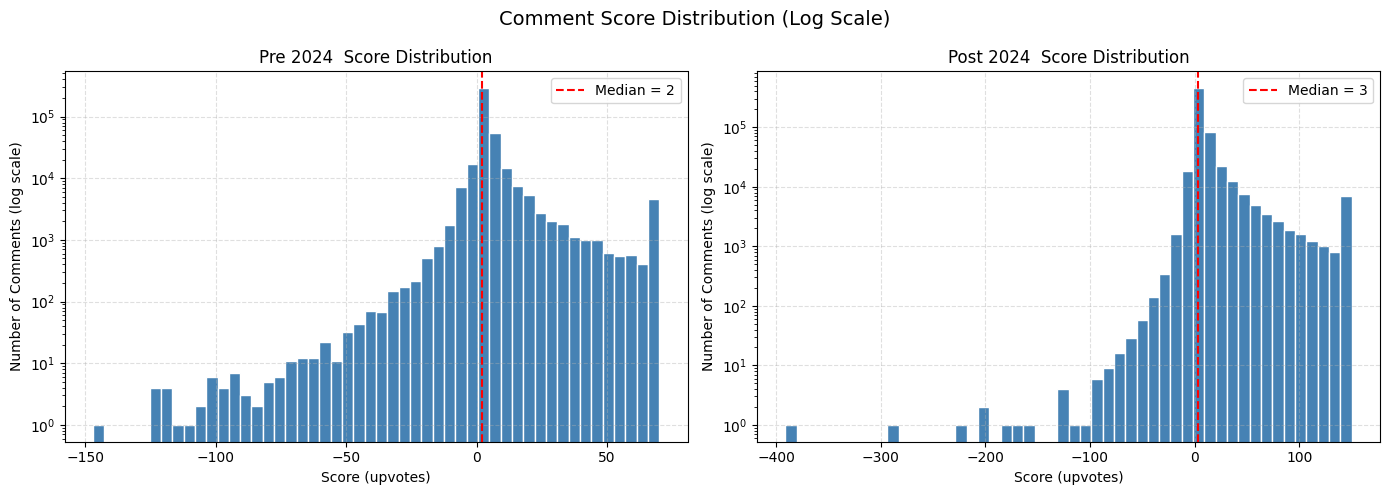

Plot saved to outputs folder


In [ ]:
# 3.2
# how much upvoting/downvoting the comments have in the two datasets.
# how the community responded to the content and if
# comments are good or not so well-received.

import matplotlib.pyplot as plt
import numpy as np


# understanding upvoted

print("-" * 60)
print("  score distribution in both datasets ")
print("-" * 60)

# basic score stats for both
for label, df in [("PRE  2024", df_pre_2024), ("POST 2024", df_post_2024)]:
    print(f"\n  {label}")
    print("  " + "-" * 40)
    print(f"  Mean score   : {df['score'].mean():.2f}")
    print(f"  Median score : {df['score'].median():.2f}")
    print(f"  Max score    : {df['score'].max():,}")
    print(f"  Min score    : {df['score'].min():,}")
    print(f"  Std dev      : {df['score'].std():.2f}")

print("\n" + "-" * 60)


# plotting score distribution for both datasets
# using log scale because scores are heavily skewed
# most comments have low scores, few have very high


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comment Score Distribution (Log Scale)', fontsize=14)

for ax, (label, df) in zip(axes, [("Pre 2024", df_pre_2024), ("Post 2024", df_post_2024)]):

    # clipping scores to remove extreme outliers for better visualization
    scores = df['score'].clip(upper=df['score'].quantile(0.99))

    ax.hist(scores, bins=50, color='steelblue', edgecolor='white', log=True)
    ax.set_title(f'{label}  Score Distribution')
    ax.set_xlabel('Score (upvotes)')
    ax.set_ylabel('Number of Comments (log scale)')
    ax.axvline(df['score'].median(), color='red', linestyle='--',
               linewidth=1.5, label=f'Median = {df["score"].median():.0f}')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{prj_directory}/outputs/score_distribution.png', dpi=150)
plt.show()
print("Plot saved to outputs folder")

### discussion for above cell: [how much upvoting/downvoting the comments have in the two datasets]

Scores in both samples are low, which is the true nature of
Reddit where most comments receive just a few votes while just a few
become popular. We used a log plot to visualize this phenomenon.

Pre 2024 : average comment scores are 5.18 with a median value
being 2. It indicates that most comments did not get any significant
engagement.

Post 2024 : on the other hand, the average comment score increased
to 11.53 with a median score being 3. That implies that after October 7th,
comments received increased attention and engagement.

Comments with negative scores can also be found in both samples
indicating that users downvoted certain statements. Post-October 7th
dataset contains more extreme comment scores with the highest score
being 3,023 (as opposed to 1,385).

------------------------------------------------------------
  subreddit distribution 
------------------------------------------------------------

  PRE  2024
  ----------------------------------------
  r/IsraelPalestine      :  281,015  (67.8%)
  r/AskMiddleEast        :   70,401  (17.0%)
  r/Palestine            :   63,294  (15.3%)

  POST 2024
  ----------------------------------------
  r/IsraelPalestine      :  350,491  (56.3%)
  r/Palestine            :  195,680  (31.5%)
  r/AskMiddleEast        :   75,937  (12.2%)

------------------------------------------------------------


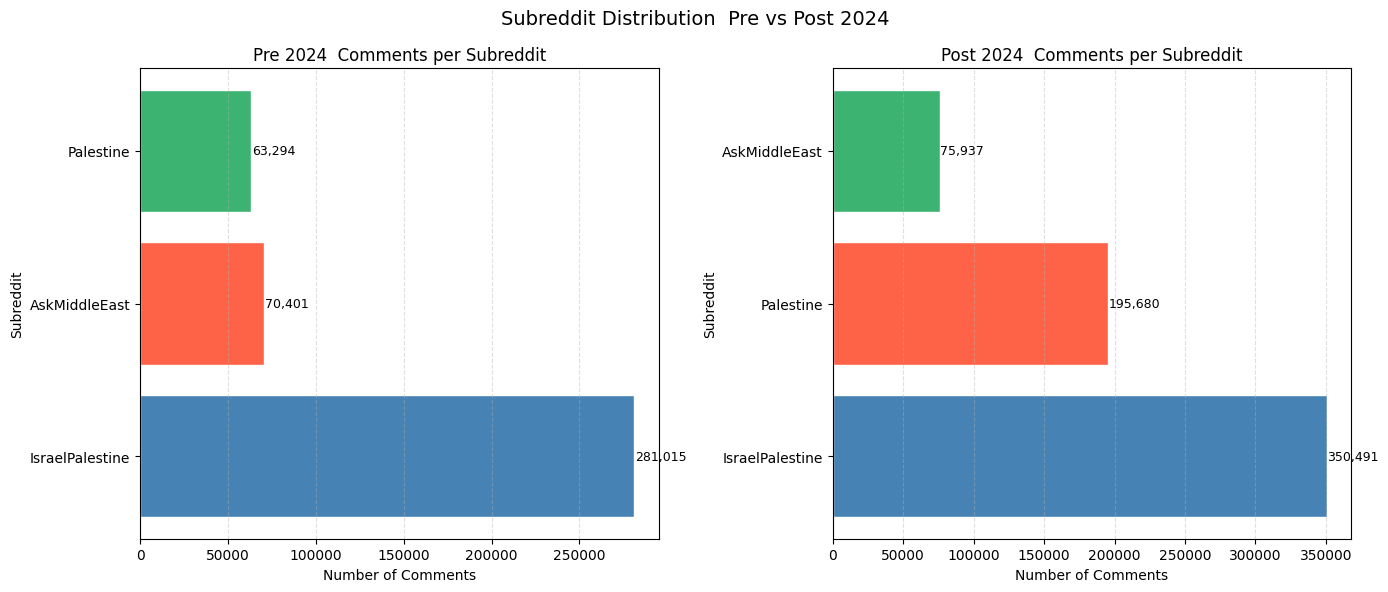

Plot saved to outputs folder


In [ ]:
# 3.3
#ooking at which subreddits are most active in both datasets.


# subreddit distribution for both datasets
# counting how many comments came from each subreddit

print("-" * 60)
print("  subreddit distribution ")
print("-" * 60)

# count comments per subreddit for both
pre_subreddit  = df_pre_2024['subreddit'].value_counts()
post_subreddit = df_post_2024['subreddit'].value_counts()

# printing counts
for label, counts in [("PRE  2024", pre_subreddit), ("POST 2024", post_subreddit)]:
    print(f"\n  {label}")
    print("  " + "-" * 40)
    for sub, count in counts.items():
        pct = count / counts.sum() * 100
        print(f"  r/{sub:<20} : {count:>8,}  ({pct:.1f}%)")

print("\n" + "-" * 60)


# plotting subreddit distribution side by side


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Subreddit Distribution  Pre vs Post 2024', fontsize=14)

colors = ['steelblue', 'tomato', 'mediumseagreen', 'mediumpurple', 'sandybrown']

for ax, (label, counts) in zip(axes, [("Pre 2024", pre_subreddit), ("Post 2024", post_subreddit)]):

    bars = ax.barh(counts.index, counts.values, color=colors[:len(counts)], edgecolor='white')

    # adding count labels on each bar
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                f'{count:,}', va='center', fontsize=9)

    ax.set_title(f'{label}  Comments per Subreddit')
    ax.set_xlabel('Number of Comments')
    ax.set_ylabel('Subreddit')
    ax.grid(True, linestyle='--', alpha=0.4, axis='x')

plt.tight_layout()
plt.savefig(f'{prj_directory}/outputs/subreddit_distribution.png', dpi=150)
plt.show()
print("Plot saved to outputs folder")

### Discussion for above cell : [which subreddits are most active in both datasets]

Both data sets show that r/IsraelPalestine is the most active subreddit
for discussion on this topic which is expected since it is the major subreddit
to discuss this topic.

Before 2024 : r/IsraelPalestine accounted for 67.8% of all comments,
r/AskMiddleEast made up 17%, and r/Palestine 15.2%. Only three subreddits
were discussed here meaning that r/israel and r/Gaza were not used in
the pre 2024 dataset after filtering.

After 2024 : r/IsraelPalestine was also the dominant subreddit accounting
for 56.3%, however, there was a significant increase of r/Palestine from
15.2% to 31.5%. This reflects a great change because it shows that
in the wake of the new conflict people chose the pro-Palestinian subreddit
for discussion. r/AskMiddleEast went down from 17% to 12.2%.

looks like the increase in the number of discussions in r/Palestine
post 2024 shows that more people starts to talk about it

  comment length analysis

  PRE  2024
  ----------------------------------------
  Mean words   : 53.6
  Median words : 33.0
  Max words    : 500
  Min words    : 10
  Std dev      : 58.8

  Word count buckets:
  10 - 50  words :  275,010
  50 - 100 words :   84,693
  100- 200 words :   41,171
  200- 500 words :   13,836

  POST 2024
  ----------------------------------------
  Mean words   : 54.3
  Median words : 31.0
  Max words    : 500
  Min words    : 10
  Std dev      : 64.2

  Word count buckets:
  10 - 50  words :  422,095
  50 - 100 words :  114,498
  100- 200 words :   59,362
  200- 500 words :   26,153



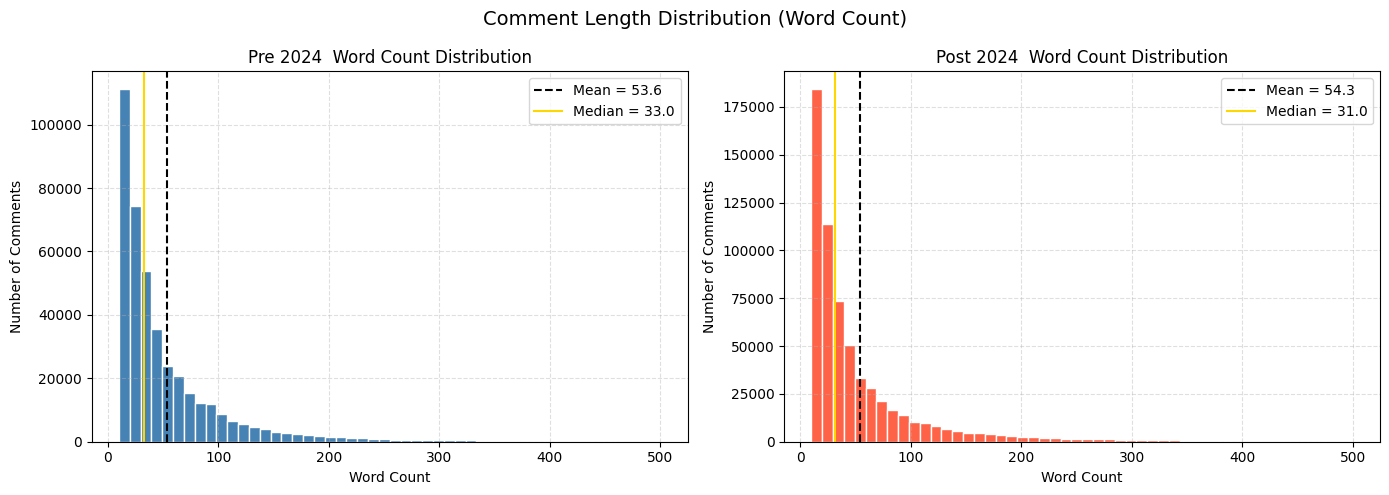

Plot saved to outputs folder


In [ ]:
# 3.4
# looking at how long comments are in both datasets

# calculating word count for each comment in both datasets


df_pre_2024['word_count']  = df_pre_2024['self_text'].str.split().str.len()
df_post_2024['word_count'] = df_post_2024['self_text'].str.split().str.len()

print("=" * 60)
print("  comment length analysis")
print("=" * 60)

# printing stats for both
for label, df in [("PRE  2024", df_pre_2024), ("POST 2024", df_post_2024)]:
    print(f"\n  {label}")
    print("  " + "-" * 40)
    print(f"  Mean words   : {df['word_count'].mean():.1f}")
    print(f"  Median words : {df['word_count'].median():.1f}")
    print(f"  Max words    : {df['word_count'].max():,}")
    print(f"  Min words    : {df['word_count'].min():,}")
    print(f"  Std dev      : {df['word_count'].std():.1f}")

    # word count buckets to see distribution
    print(f"\n  Word count buckets:")
    print(f"  10 - 50  words : {len(df[(df['word_count'] >= 10)  & (df['word_count'] < 50)]):>8,}")
    print(f"  50 - 100 words : {len(df[(df['word_count'] >= 50)  & (df['word_count'] < 100)]):>8,}")
    print(f"  100- 200 words : {len(df[(df['word_count'] >= 100) & (df['word_count'] < 200)]):>8,}")
    print(f"  200- 500 words : {len(df[(df['word_count'] >= 200) & (df['word_count'] <= 500)]):>8,}")

print("\n" + "=" * 60)


# plotting word count distribution for both datasets


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comment Length Distribution (Word Count)', fontsize=14)

for ax, (label, df, color) in zip(axes, [
    ("Pre 2024",  df_pre_2024,  'steelblue'),
    ("Post 2024", df_post_2024, 'tomato')]):

    ax.hist(df['word_count'], bins=50, color=color, edgecolor='white')

    # adding mean and median lines
    ax.axvline(df['word_count'].mean(),   color='black', linestyle='--',
               linewidth=1.5, label=f'Mean = {df["word_count"].mean():.1f}')
    ax.axvline(df['word_count'].median(), color='gold',  linestyle='-',
               linewidth=1.5, label=f'Median = {df["word_count"].median():.1f}')

    ax.set_title(f'{label}  Word Count Distribution')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Number of Comments')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{prj_directory}/outputs/comment_length.png', dpi=150)
plt.show()
print("Plot saved to outputs folder")

### Discussion from above cell: [how long comments are in both datasets]

The majority of comments in both datasets are short and contain between 10 and 50 words.
It is natural for the community where most people post brief and rapid responses to events instead of lengthy and thought-out ones.

Pre 2024 : average number of words per post is 53.6, the median number is 33. Approximately 66% of comments have fewer than 50 words meaning that most users kept their messages short before the situation escalated.

Post 2024 : the average number of words per post is 54.4, while the median is 31. Again, it is extremely close to the numbers observed before 2024 suggesting that there was no difference in the comment length after the start of the conflict. Nonetheless, the overall quantity of posts (10-50 words) has increased tremendously going from 275k before October 7th to 421k afterwards.

Both histograms shows the same type of data characterized by heavyness towards the left. Moreover, both graphs have reached the maximum number of words per post (500 words) according to our filter criteria.

In [ ]:
# 3.5
# top 10 most active users by comment count
# only doing it for post 2024 dataset
# because pre 2024 legacy data did not have author_name column


print("-" * 60)
print("  TOP 10 MOST ACTIVE USERS  POST 2024")
print("-" * 60)

top_users = df_post_2024['author_name'].value_counts().head(10)

print(f"\n  {'Rank':<6} {'Username':<25} {'Comments':>10}")
print("  " + "-" * 45)

for rank, (user, count) in enumerate(top_users.items(), 1):
    print(f"  {rank:<6} {user:<25} {count:>10,}")


------------------------------------------------------------
  TOP 10 MOST ACTIVE USERS  POST 2024
------------------------------------------------------------

  Rank   Username                    Comments
  ---------------------------------------------
  1      JosephL_55                     1,965
  2      Top_Plant5102                  1,945
  3      knign                          1,928
  4      JeffB1517                      1,919
  5      Palestine-ModTeam              1,760
  6      Tallis-man                     1,517
  7      CreativeRealmsMC               1,514
  8      DrMikeH49                      1,491
  9      jackl24000                     1,423
  10     Shachar2like                   1,368


### Discussion for above cell : [top 10 most active users by comment count]

there is no dominating user in the data set, with the most prolific
being JosephL_55, who made 1,964 posts in 621,862 total posts, or 0.3% of posts.

------------------------------------------------------------
  post upvote ratio post 2024 only
------------------------------------------------------------

  Mean ratio   : 0.760
  Median ratio : 0.790
  Min ratio    : 0.030
  Max ratio    : 1.000
  Std dev      : 0.209

  AGREEMENT BUCKETS
  ----------------------------------------
  Controversial  (< 0.50) :   86,587  (13.9%)
  Divided   (0.50 - 0.70) :  138,248  (22.2%)
  Moderate  (0.70 - 0.90) :  161,226  (25.9%)
  Agreed         (>= 0.90):  236,047  (37.9%)

------------------------------------------------------------


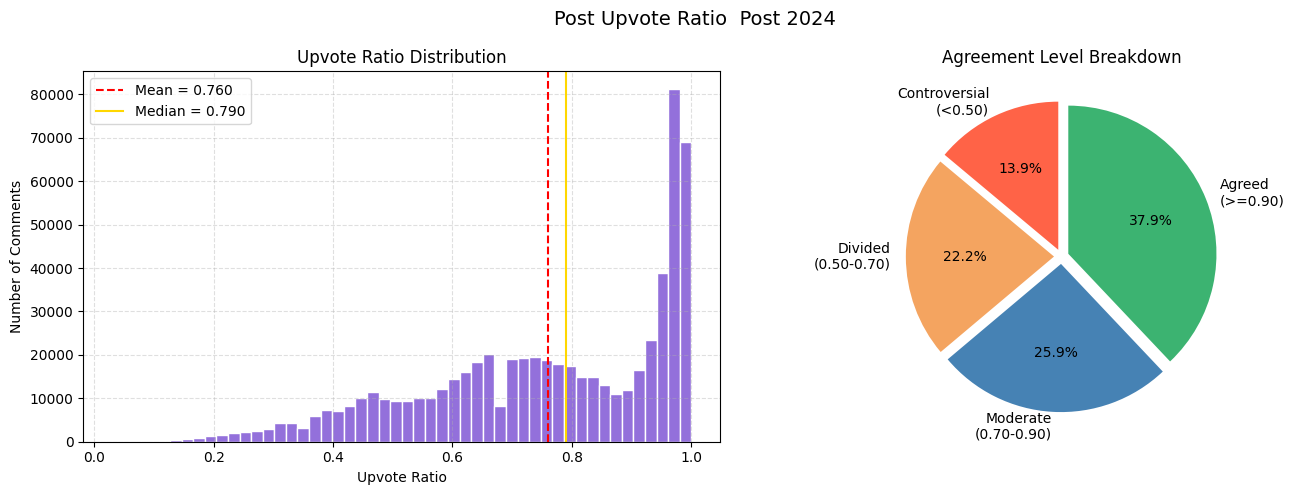

Plot saved to outputs folder


In [ ]:
# 3.6
# post upvote ratio analysis  post 2024 only
# ratio close to 1.0 = agreement, close to 0.5 = divided


print("-" * 60)
print("  post upvote ratio post 2024 only")
print("-" * 60)

ratio = df_post_2024['post_upvote_ratio'].dropna()

print(f"\n  Mean ratio   : {ratio.mean():.3f}")
print(f"  Median ratio : {ratio.median():.3f}")
print(f"  Min ratio    : {ratio.min():.3f}")
print(f"  Max ratio    : {ratio.max():.3f}")
print(f"  Std dev      : {ratio.std():.3f}")


# bucketing into agreement levels

print(f"\n  AGREEMENT BUCKETS")
print("  " + "-" * 40)

controversial = ratio[ratio < 0.5]
divided       = ratio[(ratio >= 0.5) & (ratio < 0.7)]
moderate      = ratio[(ratio >= 0.7) & (ratio < 0.9)]
agreed        = ratio[ratio >= 0.9]

total = len(ratio)
print(f"  Controversial  (< 0.50) : {len(controversial):>8,}  ({len(controversial)/total*100:.1f}%)")
print(f"  Divided   (0.50 - 0.70) : {len(divided):>8,}  ({len(divided)/total*100:.1f}%)")
print(f"  Moderate  (0.70 - 0.90) : {len(moderate):>8,}  ({len(moderate)/total*100:.1f}%)")
print(f"  Agreed         (>= 0.90): {len(agreed):>8,}  ({len(agreed)/total*100:.1f}%)")

print("\n" + "-" * 60)


# plotting upvote ratio distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Post Upvote Ratio  Post 2024', fontsize=14)

# histogram
axes[0].hist(ratio, bins=50, color='mediumpurple', edgecolor='white')
axes[0].axvline(ratio.mean(),   color='red',   linestyle='--',
                linewidth=1.5, label=f'Mean = {ratio.mean():.3f}')
axes[0].axvline(ratio.median(), color='gold',  linestyle='-',
                linewidth=1.5, label=f'Median = {ratio.median():.3f}')
axes[0].set_title('Upvote Ratio Distribution')
axes[0].set_xlabel('Upvote Ratio')
axes[0].set_ylabel('Number of Comments')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

# pie chart of agreement buckets
labels  = ['Controversial\n(<0.50)', 'Divided\n(0.50-0.70)',
           'Moderate\n(0.70-0.90)', 'Agreed\n(>=0.90)']
sizes   = [len(controversial), len(divided), len(moderate), len(agreed)]
colors  = ['tomato', 'sandybrown', 'steelblue', 'mediumseagreen']
explode = (0.05, 0.05, 0.05, 0.05)

axes[1].pie(sizes, labels=labels, colors=colors, explode=explode,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Agreement Level Breakdown')

plt.tight_layout()
plt.savefig(f'{prj_directory}/outputs/upvote_ratio.png', dpi=150)
plt.show()
print("Plot saved to outputs folder")

### Discussion for above cell: [post upvote ratio analysis  post 2024 only]

Ratio of 1.0 means all upvotes whereas
ratio of 0.5 indicates that the post is equally liked and disliked.

For post 2024, the average upvote ratio is 0.760 while the median is 0.790,
and hence majority of the posts are not extremely controversial but are
fairly accepted by the users.

Agreement buckets indicate that 38.0% posts were made on highly agreed
posts (having ratio more than 0.90), while 13.9% posts were made on
highly controversial posts

Divided bucket of 22.2% and Moderate bucket of 25.9% indicate that
half of the comments were posted in somewhat disputed topics, thereby
indicating real discussion among people

## Section 4: Sentiment Analysis & Emotion Detection

Applying a two-layer sentiment analysis pipeline for the two datasets.
The first layer will use the VADER model to categorize each comment
as being either positive, negative, or neutral. The second layer will use
a HuggingFace emotion detection model to analyze the prevalent emotion
in each comment.

### Layer 1: VADER + TextBlob + custom sarcasm

In [ ]:
# 4.1.1
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import re


# loading VADER sentiment analyzer

analyzer = SentimentIntensityAnalyzer()


# sarcasm pattern rules  built for conflict text
# if a comment matches these patterns it gets flagged
# as statement/irony/sarcasm even if VADER says positive


# positive trigger words that often start sarcastic phrases
sarcasm_words = [
    r'i love how', r'great job', r'well done', r'good job',
    r'how wonderful', r'how great', r'how nice', r'brilliant',
    r'fantastic job', r'amazing how', r'wonderful how',
    r'i love the way', r'oh great', r'oh wonderful',
    r'how lovely', r'lovely how', r'nice job', r'nice work'
]

# negative/violence context words that follow sarcasm starters
conflict_words = [
    'kill', 'killing', 'killed', 'bomb', 'bombing', 'bombed',
    'murder', 'murdering', 'murdered', 'attack', 'attacking',
    'die', 'dying', 'died', 'death', 'massacre', 'genocide',
    'civilian', 'civilians', 'innocent', 'children', 'child',
    'starv', 'displace', 'war crime', 'occupation', 'apartheid',
    'ethnic cleansing', 'shoot', 'shooting', 'execute', 'slaughter'
]

def is_sarcastic(text):
    text_lower = str(text).lower()
    for starter in sarcasm_words:
        if re.search(starter, text_lower):
            for conflict in conflict_words:
                if conflict in text_lower:
                    return True
    return False


# combined sentiment function
# VADER drives positive/negative split
# sarcasm rules catch ironic/sarcastic comments
# TextBlob used only inside sarcasm detection


def get_combined_label(text):
    text = str(text)

    vader_score = analyzer.polarity_scores(text)['compound']

    # check sarcasm first  overrides everything
    if is_sarcastic(text):
        return 'statement/irony/sarcasm'

    # VADER drives the main split
    # only truly flat comments score between -0.05 and 0.05
    if vader_score >= 0.05:
        return 'positive'
    elif vader_score <= -0.05:
        return 'negative'
    else:
        return 'statement/irony/sarcasm'

def get_combined_score(text):
    text           = str(text)
    vader_score    = analyzer.polarity_scores(text)['compound']
    textblob_score = TextBlob(text).sentiment.polarity
    return round((vader_score + textblob_score) / 2, 4)


# quick test  checking all labels are correct

test_comments = [
    "This is absolutely terrible, people are dying",
    "Great news, ceasefire has been announced",
    "The UN released a statement today",
    "I love how they bombed civilians",
    "What a great job killing innocent people",
    "How wonderful that children are dying",
    "Amazing how they keep murdering innocent people"
]

print("-" * 55)
print("VADER + TEXTBLOB + SARCASM RULES  QUICK TEST")
print("-" * 55)
for t in test_comments:
    vader   = analyzer.polarity_scores(t)['compound']
    tb      = TextBlob(t).sentiment.polarity
    sarcasm = is_sarcastic(t)
    label   = get_combined_label(t)
    print(f"\n  Comment  : {t}")
    print(f"  VADER    : {vader:.4f}")
    print(f"  TextBlob : {tb:.4f}")
    print(f"  Sarcasm  : {sarcasm}")
    print(f"  Label    : {label}")

-------------------------------------------------------
VADER + TEXTBLOB + SARCASM RULES  QUICK TEST
-------------------------------------------------------

  Comment  : This is absolutely terrible, people are dying
  VADER    : -0.5256
  TextBlob : -1.0000
  Sarcasm  : False
  Label    : negative

  Comment  : Great news, ceasefire has been announced
  VADER    : 0.6249
  TextBlob : 0.8000
  Sarcasm  : False
  Label    : positive

  Comment  : The UN released a statement today
  VADER    : 0.0000
  TextBlob : 0.0000
  Sarcasm  : False
  Label    : statement/irony/sarcasm

  Comment  : I love how they bombed civilians
  VADER    : 0.6369
  TextBlob : 0.5000
  Sarcasm  : True
  Label    : statement/irony/sarcasm

  Comment  : What a great job killing innocent people
  VADER    : 0.2732
  TextBlob : 0.6500
  Sarcasm  : True
  Label    : statement/irony/sarcasm

  Comment  : How wonderful that children are dying
  VADER    : 0.5719
  TextBlob : 1.0000
  Sarcasm  : True
  Label    : state

In [ ]:
# 4.1.2
#Running VADER on both datasets

print("-" * 50)
print("Running VADER + TEXTBLOB one pre 2024")
print("-" * 50)

df_pre_2024['vader_score'] = df_pre_2024['self_text'].apply(get_combined_score)
df_pre_2024['vader_label'] = df_pre_2024['self_text'].apply(get_combined_label)

print(f"Pre 2024 label distribution:")
print(df_pre_2024['vader_label'].value_counts())
print(df_pre_2024['vader_label'].value_counts(normalize=True).mul(100).round(1))

print("-" * 50)
print("Running VADER + TEXTBLOB one ppost 2024")
print("-" * 50)

df_post_2024['vader_score'] = df_post_2024['self_text'].apply(get_combined_score)
df_post_2024['vader_label'] = df_post_2024['self_text'].apply(get_combined_label)

print(f"Post 2024 label distribution:")
print(df_post_2024['vader_label'].value_counts())
print(df_post_2024['vader_label'].value_counts(normalize=True).mul(100).round(1))

# saving with updated labels
df_pre_2024.to_csv(f'{prj_directory}/data/pre_2024.csv',  index=False)
df_post_2024.to_csv(f'{prj_directory}/data/post_2024.csv', index=False)

print("-" * 50)
print("combined labels saved to gdrive")
print("-" * 50)

--------------------------------------------------
Running VADER + TEXTBLOB one pre 2024
--------------------------------------------------
Pre 2024 label distribution:
vader_label
negative                   222236
positive                   146527
statement/irony/sarcasm     45947
Name: count, dtype: int64
vader_label
negative                   53.6
positive                   35.3
statement/irony/sarcasm    11.1
Name: proportion, dtype: float64
--------------------------------------------------
Running VADER + TEXTBLOB one ppost 2024
--------------------------------------------------
Post 2024 label distribution:
vader_label
negative                   322825
positive                   224860
statement/irony/sarcasm     74423
Name: count, dtype: int64
vader_label
negative                   51.9
positive                   36.1
statement/irony/sarcasm    12.0
Name: proportion, dtype: float64
--------------------------------------------------
combined labels saved to gdrive
--------------

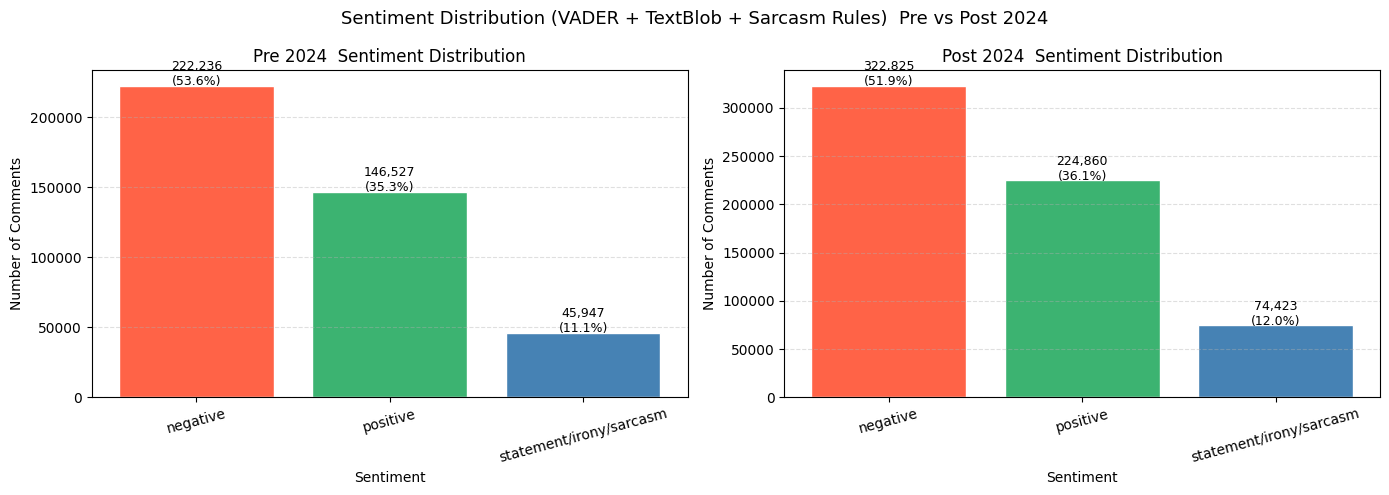

Plot saved to outputs folder


In [ ]:
# 4.1.3
import matplotlib.pyplot as plt


# visualizing combined sentiment label distribution
# for both datasets side by side

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sentiment Distribution (VADER + TextBlob + Sarcasm Rules)  Pre vs Post 2024', fontsize=13)

colors = {
    'positive'               : 'mediumseagreen',
    'negative'               : 'tomato',
    'statement/irony/sarcasm': 'steelblue'
}

for ax, (label, df) in zip(axes, [("Pre 2024", df_pre_2024), ("Post 2024", df_post_2024)]):

    counts     = df['vader_label'].value_counts()
    bar_colors = [colors[l] for l in counts.index]

    bars = ax.bar(counts.index, counts.values, color=bar_colors, edgecolor='white')

    # adding count and percentage labels on bars
    for bar, count in zip(bars, counts.values):
        pct = count / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=9)

    ax.set_title(f'{label}  Sentiment Distribution')
    ax.set_xlabel('Sentiment')
    ax.set_ylabel('Number of Comments')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig(f'{prj_directory}/outputs/vader_distribution.png', dpi=150)
plt.show()
print("Plot saved to outputs folder")

In [ ]:
# 4.1.4
import warnings
warnings.filterwarnings('ignore')


# showing 2 representative comments per sentiment
# sampling from each subreddit equally to avoid bias


def show_representative_comments(df, dataset_name, n=1):
    print("\n" + "-" * 60)
    print(f"  Representative comments from: {dataset_name}")
    print("-" * 60)

    for sentiment in ['negative', 'positive', 'statement/irony/sarcasm']:
        print(f"\n  {sentiment.upper()}")
        print("  " + "-" * 55)

        sentiment_df = df[df['vader_label'] == sentiment]

        # selecting only needed columns before groupby
        samples = (sentiment_df[['subreddit', 'score', 'self_text']]
                   .groupby('subreddit', group_keys=False)
                   .apply(lambda x: x.sample(min(n, len(x)), random_state=42))
                   .reset_index(drop=True)
                   .head(5))  # only show 2 total

        for i, (_, row) in enumerate(samples.iterrows(), 1):
            wrapped = textwrap.fill(str(row['self_text'])[:250], width=65)
            print(f"\n  #{i} | Score: {row['score']:,} | r/{row['subreddit']}")
            print("  " + "-" * 55)
            for line in wrapped.split('\n'):
                print(f"  {line}")

show_representative_comments(df_pre_2024,  "pre  2024")
show_representative_comments(df_post_2024, "post 2024")


------------------------------------------------------------
  Representative comments from: pre  2024
------------------------------------------------------------

  NEGATIVE
  -------------------------------------------------------

  #1 | Score: 6 | r/AskMiddleEast
  -------------------------------------------------------
  The US is not crazy to interfere in this war.

  #2 | Score: 1 | r/IsraelPalestine
  -------------------------------------------------------
  You’re clearly coming with a western mindset. Western imperialism
  clearly is not working anymore around the world and that’s why
  many countries are opposing them.  You’re point of view that all
  the above countries that support Hamas are bad or evil j

  #3 | Score: 2 | r/Palestine
  -------------------------------------------------------
  I don’t get what they’re trying to prove. *Even if* this baby
  were a doll (which he’s not) have they not seen the hundreds of
  other dead children over the last months?? There’

#### Representative Comments Discussion

Example comments for each sentiment group shows us to
understand our labels more clearly in relation to this particular
conflict corpus.

Comments labeled as negative are definitely expressing feelings of
frustration, disappointment, and grief. In both pre- and post-2024,
examples reference the death of Palestinian babies and Western
imperialism. The post-2024 comments refer to a lack of empathy and
desperation in politics. This is definitely a negative sentiment
expression.

The tricky part comes when labeling positive comments , VADER will
pick out positive words but they're always in the context of some
conflict. Comments such as "Great post. If Israel really wanted to
free Palestine from Hamas they would do so." While the content is
actually quite negative, the use of "great" makes this a positive
comment by our label. It does show how VADER's limitation lies
with political comments on Reddit.

Comments under Statement/Irony/Sarcasm are definitely an interesting
mix of factual statements and ironical comments. The label seems to
serve as a catch-all for comments that are neutral and do not fit
as negative or positive.

In conclusion, the labels appear to make sense on a distribution
basis although there may be some noise in individual labeling
this is perfectly normal for sentiment classification.

*This is exactly why we do not depend on VADER alone. Layer 2, the HuggingFace emotion detection model, gets more complicated than positive and negative sentiments. Instead of asking whether a given comment is good or bad, it asks whether the person feels angry, sad, scared, happy, or disgusted. We obtain a much deeper insight into what people think about the situation, which is the essence of our study.*

### Layer 2: HuggingFace Emotion Model

Applying an already trained emotion model from Huggingface for all comments from both datasets. Emotions identified include anger, disgust, fear, joy, neutral, sadness, and surprise. The emotions go deeper than just classifying them as either positive or negative emotions – the exact emotion is provided.
Model: j-hartmann/emotion-english-distilroberta-base

In [ ]:
# 4.2.1
import pandas as pd
import os

prj_directory = '/content/drive/MyDrive/DSC478_Project'

df_pre_2024  = pd.read_csv(f'{prj_directory}/data/pre_2024.csv',  parse_dates=['created_time'])
df_post_2024 = pd.read_csv(f'{prj_directory}/data/post_2024.csv', parse_dates=['created_time'])

print("-" * 50)
print("DATASETS LOADED FROM DRIVE")
print("-" * 50)
print(f"Pre  2024 : {df_pre_2024.shape}")
print(f"Post 2024 : {df_post_2024.shape}")
print("-" * 50)

--------------------------------------------------
DATASETS LOADED FROM DRIVE
--------------------------------------------------
Pre  2024 : (414710, 8)
Post 2024 : (622108, 27)
--------------------------------------------------


In [ ]:
# 4.2.2
from transformers import pipeline
import torch


# loading the HuggingFace emotion model
# model: j-hartmann/emotion-english-distilroberta-base
# handles 7 emotions: anger, disgust, fear, joy,
#                     neutral, sadness, surprise
# using GPU if available for faster inference


device = 0 if torch.cuda.is_available() else -1
print(f"Using device : {'GPU' if device == 0 else 'CPU'}")
print(f"GPU name     : {torch.cuda.get_device_name(0) if device == 0 else 'N/A'}")

emotion_model = pipeline(
    task     = 'text-classification',
    model    = 'j-hartmann/emotion-english-distilroberta-base',
    top_k    = 1,
    device   = device
)


# hard test cases
# testing if model correctly detects clear emotions

test_texts = [

    "Those poor children did not deserve this, their blood is on everyone's hands",
    "If this spreads to Lebanon we are all finished, nobody will stop them",
    "Thousands of families have been wiped out, entire generations gone forever",


    "The hostages are finally coming home, their families can breathe again",
    "They executed prisoners in cold blood and filmed it, this is pure evil",
    "The UN Security Council will meet tomorrow to discuss the resolution",

    "I cannot believe the scale of destruction, entire neighborhoods just wiped off the map",
    "She was a nurse, a mother of three, she just wanted to help people and now she is gone",
    "How many more children need to die before someone actually does something about this",
    "Nobody knows what comes next, the whole region is on the edge of collapse"
]

print("-" * 60)
print("Testing with sample cases")
print("-" * 60)
for t in test_texts:
    result  = emotion_model(t[:512])
    emotion = result[0][0]['label']
    score   = result[0][0]['score']
    print(f"\n  Comment : {t}")
    print(f"  Emotion : {emotion:<10}  confidence: {score:.4f}")

Using device : GPU
GPU name     : NVIDIA RTX PRO 6000 Blackwell Server Edition


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

------------------------------------------------------------
Testing with sample cases
------------------------------------------------------------

  Comment : Those poor children did not deserve this, their blood is on everyone's hands
  Emotion : anger       confidence: 0.5421

  Comment : If this spreads to Lebanon we are all finished, nobody will stop them
  Emotion : neutral     confidence: 0.9225

  Comment : Thousands of families have been wiped out, entire generations gone forever
  Emotion : sadness     confidence: 0.5757

  Comment : The hostages are finally coming home, their families can breathe again
  Emotion : neutral     confidence: 0.7121

  Comment : They executed prisoners in cold blood and filmed it, this is pure evil
  Emotion : disgust     confidence: 0.7817

  Comment : The UN Security Council will meet tomorrow to discuss the resolution
  Emotion : neutral     confidence: 0.3581

  Comment : I cannot believe the scale of destruction, entire neighborhoods just w

In [ ]:
# 4.2.3
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch
from transformers import pipeline, logging
from tqdm import tqdm
import pandas as pd

logging.set_verbosity_error()


# loading emotion model on GPU

device = 0 if torch.cuda.is_available() else -1
print(f"Using device : {'GPU' if device == 0 else 'CPU'}")
print(f"GPU name     : {torch.cuda.get_device_name(0) if device == 0 else 'N/A'}")

emotion_model = pipeline(
    task     = 'text-classification',
    model    = 'j-hartmann/emotion-english-distilroberta-base',
    top_k    = 1,
    device   = device
)
print("Model loaded successfully!")


# quick sanity test before full run

test = emotion_model(["Children are dying and nobody cares"])
print(f"Test : {test[0][0]['label']} ({test[0][0]['score']:.4f})")

Using device : GPU
GPU name     : NVIDIA RTX PRO 6000 Blackwell Server Edition


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Model loaded successfully!
Test : neutral (0.3494)


In [ ]:
# 4.2.4
from tqdm import tqdm

# running emotion model in batches of 128
# saving checkpoint every 50k rows to Drive


def clean_text(text):
    # removing non-ASCII characters that cause CUDA errors
    text = str(text)[:512]
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = text.strip()
    if len(text) < 3:
        text = "no comment"
    return text

def run_emotion_model(df, dataset_name, save_path, batch_size=128):

    # check for existing checkpoint
    if os.path.exists(save_path):
        df_saved = pd.read_csv(save_path)
        if 'emotion_label' in df_saved.columns:
            df['emotion_label'] = df_saved['emotion_label'].values
            df['emotion_score'] = df_saved['emotion_score'].values
            done = df['emotion_label'].notna().sum()
            print(f"Checkpoint found  resuming from row {done:,}")
        else:
            df['emotion_label'] = None
            df['emotion_score'] = None
            done = 0
    else:
        df['emotion_label'] = None
        df['emotion_score'] = None
        done = 0

    # get rows that still need processing
    todo_idx = df[df['emotion_label'].isna()].index.tolist()
    texts    = df.loc[todo_idx, 'self_text'].tolist()

    print(f"\nRunning emotion model on {dataset_name}")
    print(f"Total to process : {len(texts):,}")
    print(f"Batch size       : {batch_size}")
    print(f"Already done     : {done:,}")
    print("-" * 50)

    labels = []
    scores = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = [clean_text(t) for t in texts[i:i + batch_size]]

        try:
            results = emotion_model(batch)
            for r in results:
                labels.append(r[0]['label'])
                scores.append(r[0]['score'])

        except Exception as e:
            # if batch fails process one by one
            for text in batch:
                try:
                    r = emotion_model([text])
                    labels.append(r[0][0]['label'])
                    scores.append(r[0][0]['score'])
                except:
                    labels.append('neutral')
                    scores.append(0.0)

        # save checkpoint every 50k rows
        if i > 0 and (i % 50000) == 0:
            df.loc[todo_idx[:len(labels)], 'emotion_label'] = labels
            df.loc[todo_idx[:len(scores)], 'emotion_score'] = scores
            df.to_csv(save_path, index=False)
            print(f"  Checkpoint saved at row {done + len(labels):,}")

    # assign final results
    df.loc[todo_idx, 'emotion_label'] = labels
    df.loc[todo_idx, 'emotion_score'] = scores

    # final save
    df.to_csv(save_path, index=False)

    print(f"\nDone! {dataset_name} saved")
    print(f"Label distribution:")
    print(df['emotion_label'].value_counts())

    return df


# output files CSVs

pre_out  = f'{prj_directory}/outputs/pre_2024_with_emotions.csv'
post_out = f'{prj_directory}/outputs/post_2024_with_emotions.csv'

df_pre_2024  = run_emotion_model(df_pre_2024,  "PRE  2024", pre_out)
df_post_2024 = run_emotion_model(df_post_2024, "POST 2024", post_out)

print("=" * 50)
print("EMOTION MODEL COMPLETE  BOTH DATASETS")
print("=" * 50)
print(f"Pre  2024 shape : {df_pre_2024.shape}")
print(f"Post 2024 shape : {df_post_2024.shape}")
print(f"Pre  saved to   : {pre_out}")
print(f"Post saved to   : {post_out}")


Running emotion model on PRE  2024
Total to process : 414,710
Batch size       : 128
Already done     : 0
--------------------------------------------------


 96%|█████████▋| 3126/3240 [12:08<01:41,  1.12it/s]

  Checkpoint saved at row 400,128


100%|██████████| 3240/3240 [12:34<00:00,  4.30it/s]



Done! PRE  2024 saved
Label distribution:
emotion_label
neutral     164641
anger        96809
disgust      68365
fear         31435
surprise     24805
sadness      18663
joy           9992
Name: count, dtype: int64

Running emotion model on POST 2024
Total to process : 622,108
Batch size       : 128
Already done     : 0
--------------------------------------------------


 64%|██████▍   | 3126/4861 [12:14<2:09:45,  4.49s/it]

  Checkpoint saved at row 400,128


100%|██████████| 4861/4861 [18:56<00:00,  4.28it/s]



Done! POST 2024 saved
Label distribution:
emotion_label
neutral     256484
anger       126038
disgust     116041
fear         42376
surprise     37733
sadness      25599
joy          17837
Name: count, dtype: int64
EMOTION MODEL COMPLETE  BOTH DATASETS
Pre  2024 shape : (414710, 10)
Post 2024 shape : (622108, 29)
Pre  saved to   : /content/drive/MyDrive/DSC478_Project/outputs/pre_2024_with_emotions.csv
Post saved to   : /content/drive/MyDrive/DSC478_Project/outputs/post_2024_with_emotions.csv


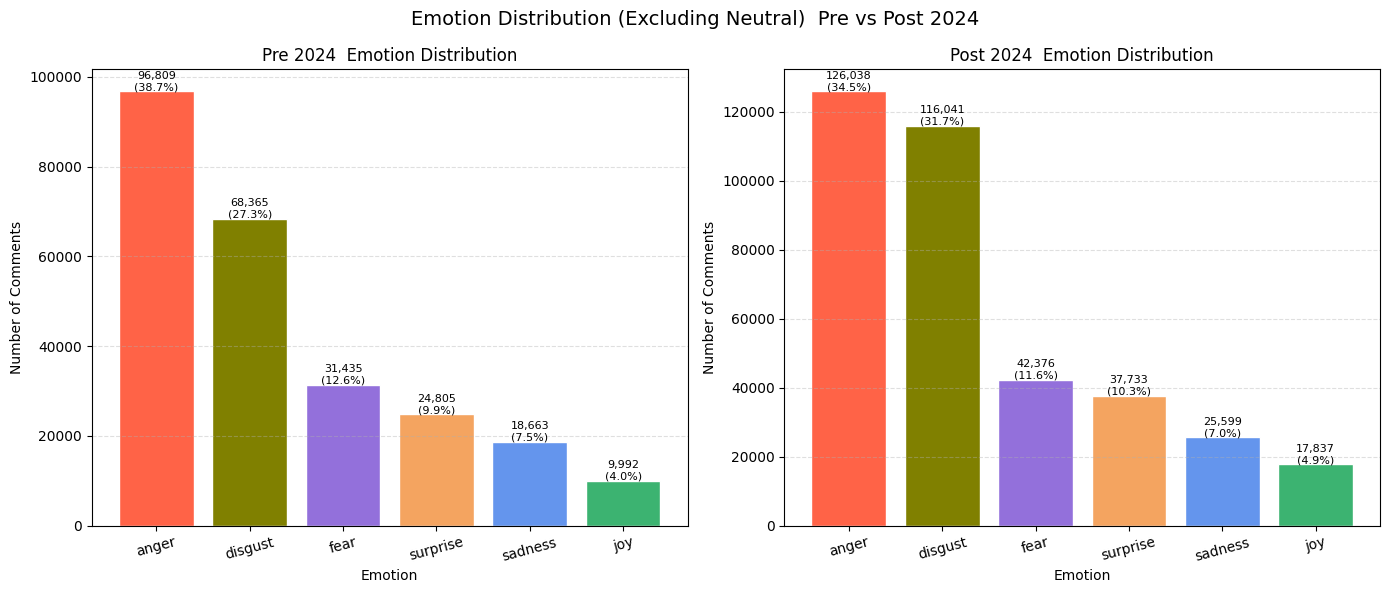

Plot saved to outputs folder


In [ ]:
# 4.2.5
# visualizing emotion distribution for both datasets
# excluding neutral to focus on meaningful emotions


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Emotion Distribution (Excluding Neutral)  Pre vs Post 2024', fontsize=14)

emotion_colors = {
    'anger'   : 'tomato',
    'disgust' : 'olive',
    'fear'    : 'mediumpurple',
    'joy'     : 'mediumseagreen',
    'sadness' : 'cornflowerblue',
    'surprise': 'sandybrown'
}

for ax, (label, df) in zip(axes, [("Pre 2024", df_pre_2024), ("Post 2024", df_post_2024)]):

    # excluding neutral from the count
    counts     = df[df['emotion_label'] != 'neutral']['emotion_label'].value_counts()
    bar_colors = [emotion_colors.get(e, 'gray') for e in counts.index]

    bars = ax.bar(counts.index, counts.values, color=bar_colors, edgecolor='white')

    # adding count and percentage on each bar
    # percentage is out of total non-neutral comments
    total_non_neutral = counts.sum()
    for bar, count in zip(bars, counts.values):
        pct = count / total_non_neutral * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=8)

    ax.set_title(f'{label}  Emotion Distribution')
    ax.set_xlabel('Emotion')
    ax.set_ylabel('Number of Comments')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig(f'{prj_directory}/outputs/emotion_distribution_no_neutral.png', dpi=150)
plt.show()
print("Plot saved to outputs folder")

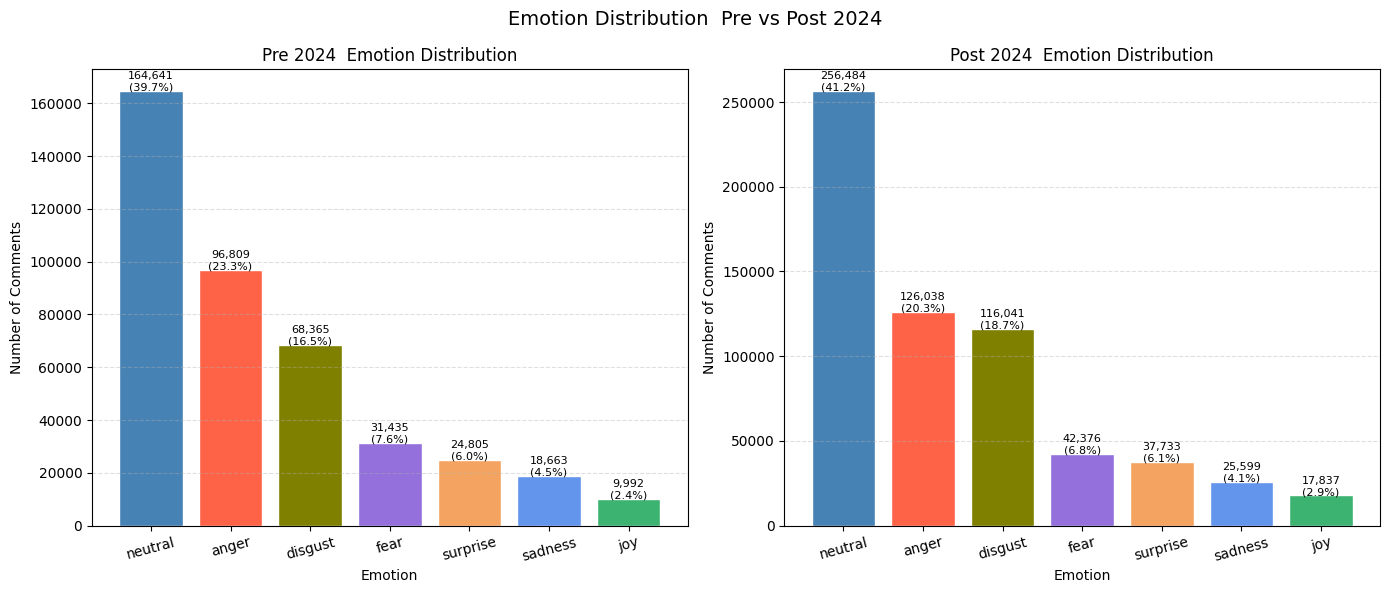

Plot saved to outputs folder


In [ ]:
#4.2.6

# visualizing emotion distribution for both datasets
# comparing pre and post 2024 side by side


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Emotion Distribution  Pre vs Post 2024', fontsize=14)

emotion_colors = {
    'anger'   : 'tomato',
    'disgust' : 'olive',
    'fear'    : 'mediumpurple',
    'joy'     : 'mediumseagreen',
    'neutral' : 'steelblue',
    'sadness' : 'cornflowerblue',
    'surprise': 'sandybrown'
}

for ax, (label, df) in zip(axes, [("Pre 2024", df_pre_2024), ("Post 2024", df_post_2024)]):

    counts     = df['emotion_label'].value_counts()
    bar_colors = [emotion_colors.get(e, 'gray') for e in counts.index]

    bars = ax.bar(counts.index, counts.values, color=bar_colors, edgecolor='white')

    # adding count and percentage on each bar
    for bar, count in zip(bars, counts.values):
        pct = count / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=8)

    ax.set_title(f'{label}  Emotion Distribution')
    ax.set_xlabel('Emotion')
    ax.set_ylabel('Number of Comments')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig(f'{prj_directory}/outputs/emotion_distribution_hhg.png', dpi=150)
plt.show()
print("Plot saved to outputs folder")

#### Emotion Analysis  Insights Digging Deeper

Going deeper into emotions, to explore the cross analysis of
emotion names with subreddit, score, VADER, time, and top comments.
This provides us with a better understanding of how each emotion
group looks in both datasets.

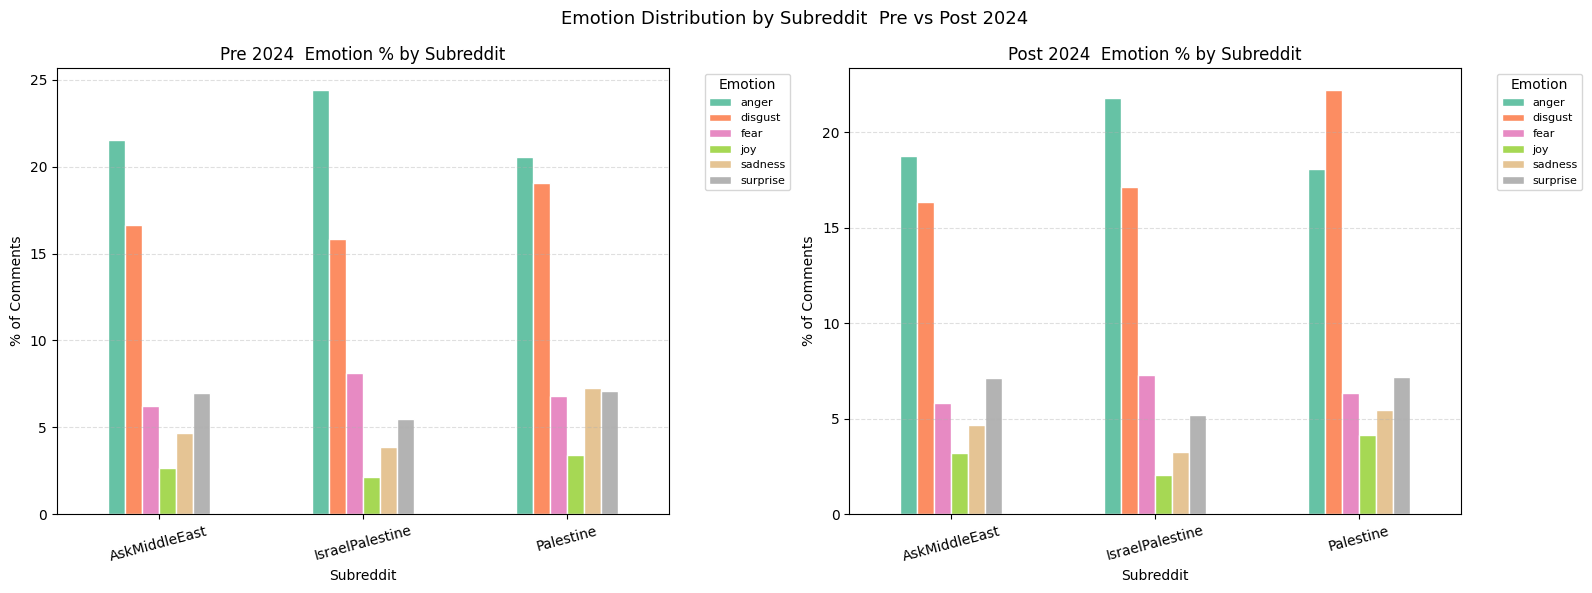

Plot saved


In [ ]:
# 4.2.7
# emotion vs subreddit  which community drives which emotion
# showing as percentage within each subreddit


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Emotion Distribution by Subreddit  Pre vs Post 2024', fontsize=13)

for ax, (label, df) in zip(axes, [("Pre 2024", df_pre_2024), ("Post 2024", df_post_2024)]):

    # cross tab of subreddit vs emotion  normalized by subreddit
    ct = pd.crosstab(df['subreddit'], df['emotion_label'], normalize='index') * 100

    # drop neutral column for cleaner view
    if 'neutral' in ct.columns:
        ct = ct.drop(columns=['neutral'])

    ct.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
    ax.set_title(f'{label}  Emotion % by Subreddit')
    ax.set_xlabel('Subreddit')
    ax.set_ylabel('% of Comments')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig(f'{prj_directory}/outputs/emotion_vs_subreddit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

#### Emotion vs. VADER Sentiment

checking  cross validation with the emotion labels and the VADER sentiment labels.
We will find out which emotions are behind positive,
negative, and sarcastic comments. For instance, are negative
comments mostly based on anger or disgust?

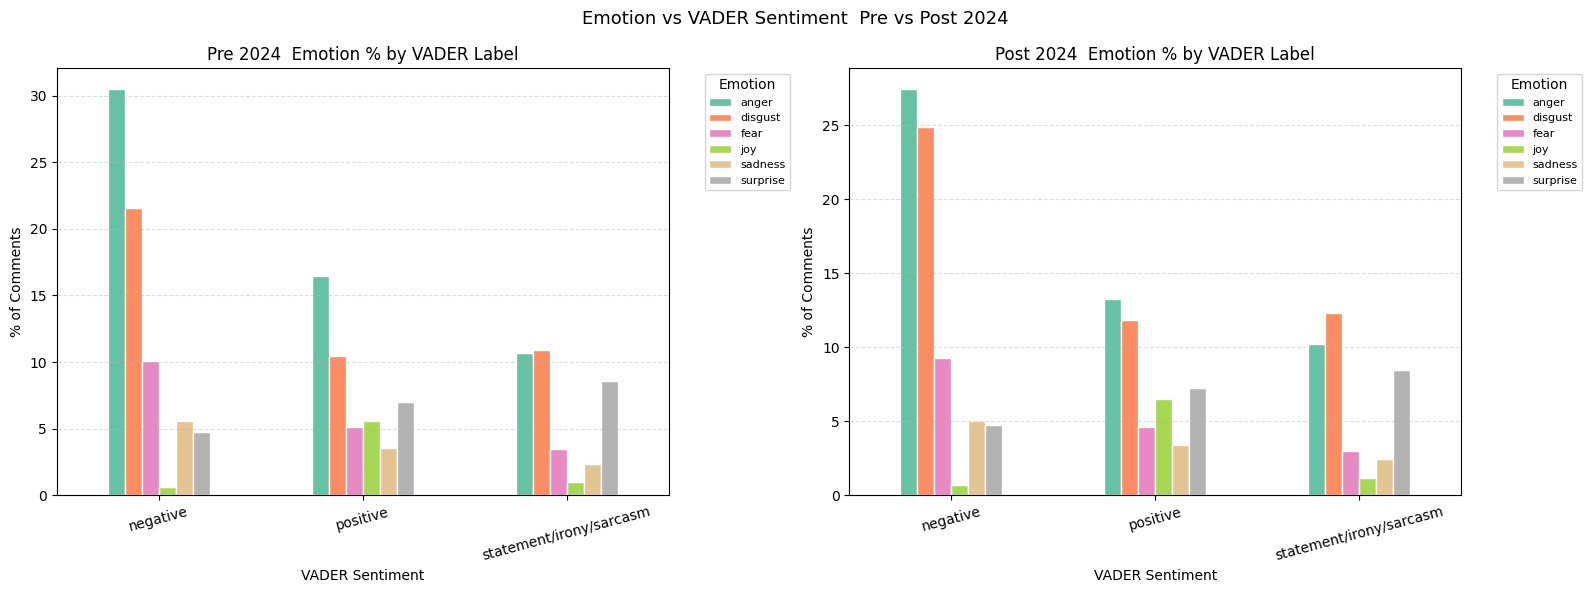

Plot saved

  Emotion % PER VADER label pre 2024
emotion_label            anger  disgust  fear  joy  neutral  sadness  surprise
vader_label                                                                   
negative                  30.5     21.6  10.1  0.6     26.8      5.6       4.8
positive                  16.4     10.5   5.1  5.5     51.9      3.5       7.0
statement/irony/sarcasm   10.7     10.9   3.4  1.0     63.1      2.3       8.6

  EEmotion % PER VADER label post 2024
emotion_label            anger  disgust  fear  joy  neutral  sadness  surprise
vader_label                                                                   
negative                  27.5     24.9   9.2  0.7     28.0      5.0       4.7
positive                  13.2     11.8   4.6  6.5     53.2      3.4       7.2
statement/irony/sarcasm   10.2     12.3   3.0  1.2     62.4      2.5       8.4


In [ ]:
# emotion vs vader label
# showing what emotions drive each sentiment group


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Emotion vs VADER Sentiment  Pre vs Post 2024', fontsize=13)

for ax, (label, df) in zip(axes, [("Pre 2024", df_pre_2024), ("Post 2024", df_post_2024)]):

    # cross tab of vader label vs emotion normalized by vader label
    ct = pd.crosstab(df['vader_label'], df['emotion_label'], normalize='index') * 100

    # drop neutral emotion for cleaner view
    if 'neutral' in ct.columns:
        ct = ct.drop(columns=['neutral'])

    ct.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
    ax.set_title(f'{label}  Emotion % by VADER Label')
    ax.set_xlabel('VADER Sentiment')
    ax.set_ylabel('% of Comments')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig(f'{prj_directory}/outputs/emotion_vs_vader.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")


# printing the numbers behind the chart
print("\n" + "=" * 60)
print("  Emotion % PER VADER label pre 2024")
print("=" * 60)
ct_pre = pd.crosstab(df_pre_2024['vader_label'],
                     df_pre_2024['emotion_label'],
                     normalize='index').mul(100).round(1)
print(ct_pre.to_string())

print("\n" + "=" * 60)
print("  EEmotion % PER VADER label post 2024")
print("=" * 60)
ct_post = pd.crosstab(df_post_2024['vader_label'],
                      df_post_2024['emotion_label'],
                      normalize='index').mul(100).round(1)
print(ct_post.to_string())

Finding: that negative emotions are driven by anger and disgust
in both time periods. Following October 7th there was an increase
in disgust but no change in anger. This suggests that there was
an increased feeling of moral outrage than anger following conflict.

#### Trends of Emotions Through Time

This looks into emotions on a monthly basis from both databases.
This allows us to see an emotional spike that corresponds to external incidents.
Some examples include ceasefire, attack, or global decision.

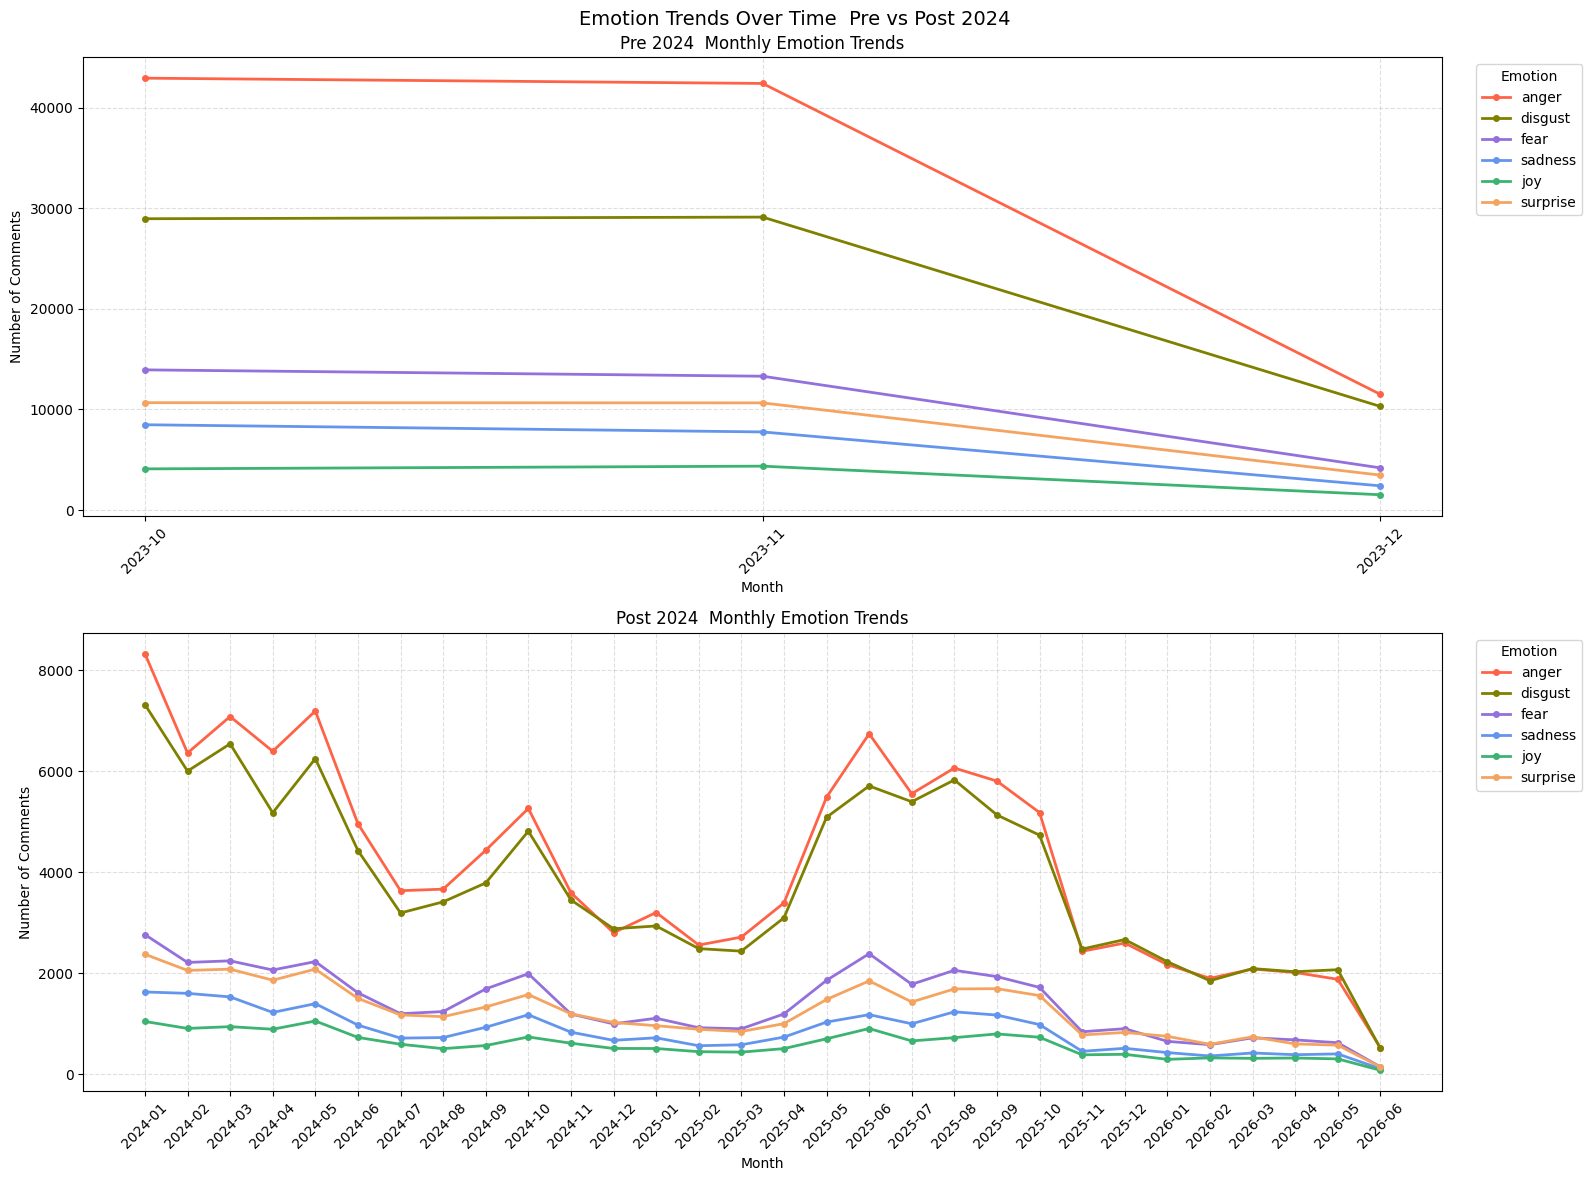

Plot saved


In [ ]:
# 4.2.8
# emotion over time  monthly trends
# showing how emotions shifted across both time periods


fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Emotion Trends Over Time  Pre vs Post 2024', fontsize=14)

emotions_to_plot  = ['anger', 'disgust', 'fear', 'sadness', 'joy', 'surprise']
emotions_to_check = ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']

emotion_colors = {
    'anger'   : 'tomato',         'disgust' : 'olive',
    'fear'    : 'mediumpurple',   'joy'     : 'mediumseagreen',
    'sadness' : 'cornflowerblue', 'surprise': 'sandybrown'
}

for ax, (label, df) in zip(axes, [("Pre 2024", df_pre_2024), ("Post 2024", df_post_2024)]):

    df = df.copy()
    df['month'] = pd.to_datetime(df['created_time']).dt.to_period('M')

    monthly = df.groupby(['month', 'emotion_label']).size().unstack(fill_value=0)
    monthly.index = monthly.index.astype(str)

    for emotion in emotions_to_plot:
        if emotion in monthly.columns:
            ax.plot(monthly.index, monthly[emotion],
                    label=emotion,
                    color=emotion_colors[emotion],
                    linewidth=2, marker='o', markersize=4)

    ax.set_title(f'{label}  Monthly Emotion Trends')
    ax.set_xlabel('Month')
    ax.set_ylabel('Number of Comments')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Emotion', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{prj_directory}/outputs/emotion_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")


In [ ]:
#4.2.9
# printing monthly counts with top non-neutral emotion
# shown in brackets at end of each row


df_pre_2024['month']  = pd.to_datetime(df_pre_2024['created_time']).dt.to_period('M')
df_post_2024['month'] = pd.to_datetime(df_post_2024['created_time']).dt.to_period('M')

monthly_pre  = df_pre_2024.groupby(['month', 'emotion_label']).size().unstack(fill_value=0)
monthly_post = df_post_2024.groupby(['month', 'emotion_label']).size().unstack(fill_value=0)

for dataset_name, monthly in [("PRE 2024", monthly_pre), ("POST 2024", monthly_post)]:
    print("\n" + "=" * 80)
    print(f"  MONTHLY EMOTION COUNTS  {dataset_name}")
    print("=" * 80)
    print(f"  {'month':<10} {'anger':>8} {'disgust':>8} {'fear':>6} "
          f"{'joy':>6} {'neutral':>8} {'sadness':>8} {'surprise':>9}   top")
    print("  " + "-" * 76)

    for month in monthly.index.astype(str):
        row = monthly.loc[month]

        # top emotion excluding neutral
        row_no_neutral = row[emotions_to_check]
        top_emotion    = row_no_neutral.idxmax()

        print(f"  {str(month):<10} "
              f"{int(row.get('anger',    0)):>8,} "
              f"{int(row.get('disgust',  0)):>8,} "
              f"{int(row.get('fear',     0)):>6,} "
              f"{int(row.get('joy',      0)):>6,} "
              f"{int(row.get('neutral',  0)):>8,} "
              f"{int(row.get('sadness',  0)):>8,} "
              f"{int(row.get('surprise', 0)):>9,}   "
              f"({top_emotion})")


  MONTHLY EMOTION COUNTS  PRE 2024
  month         anger  disgust   fear    joy  neutral  sadness  surprise   top
  ----------------------------------------------------------------------------
  2023-10      42,916   28,950 13,935  4,097   72,929    8,482    10,674   (anger)
  2023-11      42,391   29,113 13,303  4,368   70,163    7,768    10,654   (anger)
  2023-12      11,502   10,302  4,197  1,527   21,549    2,413     3,477   (anger)

  MONTHLY EMOTION COUNTS  POST 2024
  month         anger  disgust   fear    joy  neutral  sadness  surprise   top
  ----------------------------------------------------------------------------
  2024-01       8,333    7,324  2,764  1,042   15,505    1,627     2,374   (anger)
  2024-02       6,364    6,005  2,212    904   12,231    1,599     2,054   (anger)
  2024-03       7,087    6,546  2,244    939   12,952    1,529     2,079   (anger)
  2024-04       6,398    5,179  2,062    888   12,062    1,221     1,860   (anger)
  2024-05       7,197    6,252

### Why Disgust was Ahead of Anger in Some Months

• December 2024 disgust beat out anger by a very small number
(2,880 vs 2,802). In this month, the Lebanon ceasefire deal
stood but there was continued bombardment in Gaza. According to
OCHA report of December 17th, 2024, over 69% of Gaza
structures had been destroyed with more than 45,000 Palestinians
being killed. With so much destruction occurring, people are more
likely to focus on their disgust with the situation
"this is morally wrong", as opposed to feeling anger "I am furious"
about it.
[Source: Security Council Report, OCHA Dec 2024
securitycouncilreport.org/monthly-forecast/2025-01]

---

• November 2025 and December 2025 disgust beat out anger again.
These months came after the ceasefire deal reached between Israel
and Hamas in October 2025. After a ceasefire announcement, the
population stops being actively angry and moves to disgust about
the whole situation, reflecting on what has happened.
[Source: CFR Global Conflict Tracker cfr.org/global-conflict-tracker/conflict/israeli-palestinian-conflict]

---

January and March-May 2026  disgust was the more
emotion in the conflict after a ceasefire had been reached.
Israel barred 37 humanitarian organizations from Gaza in
early 2026.
An action like blocking humanitarian aid provokes disgust,
rather than anger, since it is perceived as calculated, not as
explosive.
[Reference source: Timeline of Israeli-Palestinian conflict
2026  en.wikipedia.org/wiki/Timeline_of_the_Israeli-Palestinian_conflict_in_2026]

---
Findings:  anger spikes when there are active military
escalations with quick developments. Disgust spikes in the
time of ceasefires or decisions being made. So, the emotion
changes from "I am extremely angry about what is happening
right now" to "I am disgusted about what happened".
Such an insight confirms that our model of emotions
reflects reality and can be used to analyze public opinion
changes.





### NOTE:

#### the discussion above is not to give the explanation of what took place in the conflict. The main goal here is to make sure that our model of emotions works properly. Comparing emotion peaks from our results to real-world events showed us confidence that the peaks detected by our emotion model reflect actual shifts in sentiment. For example, if disgust peaks after a ceasefire and anger peaks after an attack  that means our emotional labels correspond to real emotions at these periods.

In [ ]:
import textwrap
#top scored comment per emotion  pre 2024
# most upvoted = community agreed with this the most


def show_top_comment_per_emotion(df, dataset_name):
    print("\n" + "=" * 65)
    print(f"  TOP SCORED COMMENT PER EMOTION  {dataset_name}")
    print("=" * 65)

    emotions = ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']

    for emotion in emotions:
        emotion_df = df[df['emotion_label'] == emotion]
        if len(emotion_df) == 0:
            continue

        top     = emotion_df.nlargest(1, 'score').iloc[0]
        wrapped = textwrap.fill(str(top['self_text'])[:300], width=62)

        print(f"\n  {emotion.upper()}")
        print("  " + "-" * 60)
        print(f"  Score     : {top['score']:,}")
        print(f"  Subreddit : r/{top['subreddit']}")
        print(f"  Comment   :")
        for line in wrapped.split('\n'):
            print(f"    {line}")

show_top_comment_per_emotion(df_pre_2024, "pre 2024")


  TOP SCORED COMMENT PER EMOTION  pre 2024

  ANGER
  ------------------------------------------------------------
  Score     : 1,385
  Subreddit : r/Palestine
  Comment   :
    Now replace Gazans with Jews and Israelis with Germans and see
    how fucked up he sounds. Zionist supremacy is pure evil

  DISGUST
  ------------------------------------------------------------
  Score     : 1,253
  Subreddit : r/Palestine
  Comment   :
    The entitlement, even after spitting at the little girl she
    had to resort to racism. This is what Palestinians have to
    deal with everyday.

  FEAR
  ------------------------------------------------------------
  Score     : 1,034
  Subreddit : r/Palestine
  Comment   :
    Brother please Don't post this. I almost became the first
    Palestinian martyr to die from cringe.

  JOY
  ------------------------------------------------------------
  Score     : 700
  Subreddit : r/Palestine
  Comment   :
    "My name is Free Palestine" - what a badass.

In [ ]:
# top scored comment per emotion  post 2024
# most upvoted = community agreed with this the most


show_top_comment_per_emotion(df_post_2024, "post 2024")


  TOP SCORED COMMENT PER EMOTION  post 2024

  ANGER
  ------------------------------------------------------------
  Score     : 3,023
  Subreddit : r/Palestine
  Comment   :
    They just fucked with the only country willing to facilitate
    negotiations. Why do we have to tolerate this reckless, rogue
    state?

  DISGUST
  ------------------------------------------------------------
  Score     : 2,117
  Subreddit : r/Palestine
  Comment   :
    I am so sick of gay rights and pride being used in this way.
    Like, the reason I as a queer person would die if I went to
    Palestine would be because Israel dropped a freaking bomb on
    me.

  FEAR
  ------------------------------------------------------------
  Score     : 1,479
  Subreddit : r/Palestine
  Comment   :
    She probably would have been abducted, sexually assaulted, and
    murdered by the IOF

  JOY
  ------------------------------------------------------------
  Score     : 1,353
  Subreddit : r/Palestine
  Comme

## Section5 - Unsupervised Learning

*Method 1  LDA Topic Modeling*

    • Clean text  done

    • Vectorize with CountVectorizer

    • Test k=5 to 10, pick best k

    • Train final LDA model

    • Show top words per topic

    • Manually label topics

    • Compare pre vs post 2024

*Method 2  K-Means Clustering*

    • Use TF-IDF matrix

    • Test k using elbow method

    • Train final K-Means

    • Visualize clusters

    • Label cluster profiles

    • Compare pre vs post 2024

### ***Method 1 LDA Topic Modeling:***

### Step 1: Text Preprocessing

For my two methods (LDA and K-Means) we need to pre-process text
before feeding into the models. steps include removing stop words,
removing URLs, removing any special characters, and performing
lemmatization.

In [ ]:
# 5.1.1
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import pandas as pd


# downloading required NLTK resources

nltk.download('stopwords',    quiet=True)
nltk.download('wordnet',      quiet=True)
nltk.download('omw-1.4',      quiet=True)


# setting up stopwords and lemmatizer
# adding conflict specific words that appear everywhere
# and carry no discriminating meaning for topic modeling

lemmatizer  = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

# adding domain specific stopwords
extra_stops = {
    'israel', 'israeli', 'palestine', 'palestinian', 'palestinians',
    'hamas', 'gaza', 'jew', 'jews', 'jewish', 'arab', 'arabs',
    'like', 'just', 'get', 'got', 'also', 'would', 'could',
    'people', 'think', 'know', 'say', 'said', 'going', 'well',
    'one', 'two', 'even', 'still', 'back', 'way', 'make',
    'want', 'need', 'take', 'see', 'come', 'go', 'thing',
    'https', 'http', 'www', 'com', 'org', 'reddit', 'amp'
}
stop_words.update(extra_stops)


# text cleaning function
# removes urls, special chars, short words
# applies lemmatization

def clean_for_nlp(text):
    text = str(text).lower()

    # remove urls
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # tokenize
    tokens = text.split()

    # remove stopwords, short words and lemmatize
    tokens = [
        lemmatizer.lemmatize(w)
        for w in tokens
        if w not in stop_words and len(w) > 3
    ]

    return ' '.join(tokens)

# applying to both datasets
# using pandas apply for progress tracking

print("-" * 50)
print("cleaning pre 2024 text ")
print("-" * 50)
df_pre_2024['clean_text']  = df_pre_2024['self_text'].apply(clean_for_nlp)
print(f"Done! Shape : {df_pre_2024.shape}")

print("-" * 50)
print("cleaning post 2024 text")
print("-" * 50)
df_post_2024['clean_text'] = df_post_2024['self_text'].apply(clean_for_nlp)
print(f"Done! Shape : {df_post_2024.shape}")

# quick check
print("-" * 50)
print("sample clean text")
print("-" * 50)
print(f"\nOriginal : {df_pre_2024['self_text'].iloc[0][:100]}")
print(f"Cleaned  : {df_pre_2024['clean_text'].iloc[0][:100]}")

--------------------------------------------------
cleaning pre 2024 text 
--------------------------------------------------
Done! Shape : (414710, 11)
--------------------------------------------------
cleaning post 2024 text
--------------------------------------------------
Done! Shape : (622108, 30)
--------------------------------------------------
sample clean text
--------------------------------------------------

Original : Now replace Gazans with Jews and Israelis with Germans and see how fucked up he sounds. Zionist supr
Cleaned  : replace gazans israeli german fucked sound zionist supremacy pure evil


### Step 2: TF-IDF Vectorization

The next step is to vectorize the text through TF-IDF which gives
the words different scores depending on their significance in
a comment against the entire data set. The scores are high for
words that are significant while common words receive low scores.
This representation of numbers is what goes in both LDA and K-Means.

In [ ]:
# 5.1.2
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
import scipy.sparse as sp
import numpy as np


# TF-IDF for K-Means clustering
# max_features = 10000 to keep it manageable on 1M docs

print("-" * 50)
print("building TF-IDF pre 2024")
print("-" * 50)

tfidf_vectorizer = TfidfVectorizer(
    max_features = 10000,  # top 10k words only
    min_df       = 5,      # word must appear in at least 5 docs
    max_df       = 0.90,   # ignore words in more than 90% of docs
    ngram_range  = (1, 2)  # unigrams and bigrams
)

# fit and transform pre 2024
tfidf_pre  = tfidf_vectorizer.fit_transform(df_pre_2024['clean_text'])
print(f"Pre  2024 TF-IDF shape : {tfidf_pre.shape}")

# transform post 2024 using same vocabulary
tfidf_post = tfidf_vectorizer.transform(df_post_2024['clean_text'])
print(f"Post 2024 TF-IDF shape : {tfidf_post.shape}")

# -------------------------------------------------------
# Count Vectorizer for LDA
# LDA works better with raw counts not TF-IDF weights
# -------------------------------------------------------
print("-" * 50)
print("building count matrix for LDA")
print("-" * 50)

count_vectorizer = CountVectorizer(
    max_features = 10000,
    min_df       = 5,
    max_df       = 0.90,
    ngram_range  = (1, 2)
)

# fit and transform pre 2024
count_pre  = count_vectorizer.fit_transform(df_pre_2024['clean_text'])
print(f"Pre  2024 Count shape  : {count_pre.shape}")

# transform post 2024 using same vocabulary
count_post = count_vectorizer.transform(df_post_2024['clean_text'])
print(f"Post 2024 Count shape  : {count_post.shape}")

print("-" * 50)
print("vectorization done")
print("-" * 50)
print(f"Vocabulary size : {len(tfidf_vectorizer.vocabulary_):,} words")
print(f"Sample words    : {list(tfidf_vectorizer.vocabulary_.keys())[:20]}")

--------------------------------------------------
building TF-IDF pre 2024
--------------------------------------------------
Pre  2024 TF-IDF shape : (414710, 10000)
Post 2024 TF-IDF shape : (622108, 10000)
--------------------------------------------------
building count matrix for LDA
--------------------------------------------------
Pre  2024 Count shape  : (414710, 10000)
Post 2024 Count shape  : (622108, 10000)
--------------------------------------------------
vectorization done
--------------------------------------------------
Vocabulary size : 10,000 words
Sample words    : ['replace', 'gazans', 'israeli', 'german', 'fucked', 'sound', 'zionist', 'supremacy', 'pure', 'evil', 'pure evil', 'anyone', 'else', 'look', 'younger', 'year', 'playing', 'modern', 'warfare', 'realise']


### Step 3: LDA Topic Modeling

For topic modeling, employing the LDA
technique to find latent topics in the comments. Here, each comment is modeled as a mixture of topics, and each topic is considered a mixture of words. We evaluate different numbers of topics ranging from 5 to 20 based on log-likelihood.

--------------------------------------------------
 finding optimal no. of topics
--------------------------------------------------
  Testing k = 5...
  Testing k = 6...
  Testing k = 7...
  Testing k = 8...
  Testing k = 9...
  Testing k = 10...

Done!


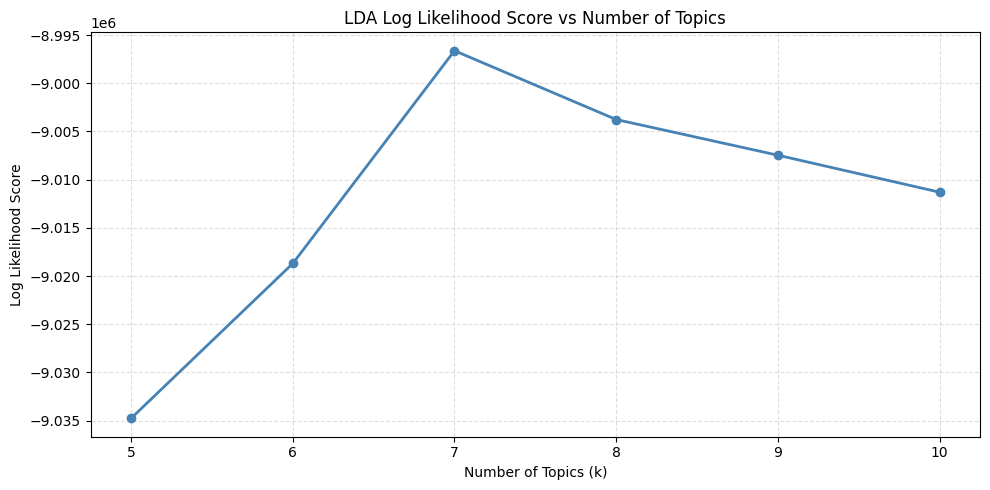

--------------------------------------------------
 log scores
--------------------------------------------------
  k =  5  :  -9,034,757.1
  k =  6  :  -9,018,695.3
  k =  7  :  -8,996,623.5
  k =  8  :  -9,003,760.8
  k =  9  :  -9,007,462.5
  k = 10  :  -9,011,299.4

  Best k based on log likelihood : 7


In [ ]:
# 5.1.3
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt


# finding optimal number of topics
# testing k from 5 to 20 on a sample for speed
# using log likelihood score  higher is better


print("-" * 50)
print(" finding optimal no. of topics")
print("-" * 50)

# using a sample of 50k for the search to save time
# full dataset will be used for final model
sample = 50000
np.random.seed(42)

sample_idx     = np.random.choice(count_pre.shape[0], sample, replace=False)
count_pre_sample = count_pre[sample_idx]

k_values    = range(5, 11, 1)
log_likelihoods = []

for k in k_values:
    print(f"  Testing k = {k}...")
    lda_test = LatentDirichletAllocation(
        n_components     = k,
        random_state     = 42,
        max_iter         = 10,
        learning_method  = 'batch'
    )
    lda_test.fit(count_pre_sample)
    log_likelihoods.append(lda_test.score(count_pre_sample))

print("\nDone!")


# plotting log likelihood scores

plt.figure(figsize=(10, 5))
plt.plot(list(k_values), log_likelihoods, marker='o',
         color='steelblue', linewidth=2, markersize=6)
plt.title('LDA Log Likelihood Score vs Number of Topics')
plt.xlabel('Number of Topics (k)')
plt.ylabel('Log Likelihood Score')
plt.xticks(list(k_values))
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{prj_directory}/outputs/lda_optimal_k.png', dpi=150)
plt.show()

print("-" * 50)
print(" log scores")
print("-" * 50)
for k, score in zip(k_values, log_likelihoods):
    print(f"  k = {k:>2}  :  {score:,.1f}")

best_k = list(k_values)[np.argmax(log_likelihoods)]
print(f"\n  Best k based on log likelihood : {best_k}")

### Optimal Value of k for LDA

Values for k between 5 and 10 topics were used to evaluate
log likelihood scores on the basis of a 50k sample. A higher score
suggests that the model has better fit the data.

A value of k = 7 was determined to give the maximum score
of -8,996,623.5. The graph is clear proof that the optimal value of
k is indeed 7 because the scores are lower after this point. The
model begins to divide the same themes into sub-themes when
more values of k are added.

k=7 will be used in the final topic modeling of LDA in both
datasets. This indicates that there will be 7 different themes found
in the Reddit discourse.

### Step 4: Train final LDA model with k=7

In [ ]:
# 5.1.4
# training final LDA model with optimal k = 7
# running on full pre 2024 dataset


top_k = 7

print("-" * 50)
print(f"training final LDA model  k = {top_k}")
print("-" * 50)

lda_model = LatentDirichletAllocation(
    n_components    = top_k,
    random_state    = 42,
    max_iter        = 10,
    learning_method = 'online',
    batch_size      = 4096,
    n_jobs          = -1
)

print("Fitting on pre 2024...")
lda_model.fit(count_pre)
print("Done!")


# showing top 15 words per topic

feature_names = count_vectorizer.get_feature_names_out()

print("\n" + "=" * 60)
print(f" top 5 words per topic pre 2024")
print("=" * 60)

for topic_idx, topic in enumerate(lda_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-16:-1]]
    print(f"\n  TOPIC {topic_idx + 1}")
    print("  " + "-" * 50)
    print(f"  {' | '.join(top_words)}")

--------------------------------------------------
training final LDA model  k = 7
--------------------------------------------------
Fitting on pre 2024...
Done!

 top 5 words per topic pre 2024

  TOPIC 1
  --------------------------------------------------
  time | peace | year | side | west | life | israeli | world | dont | never | terrorist | bank | west bank | right | stop

  TOPIC 2
  --------------------------------------------------
  please | comment | action | concern | question | automatically | contact | performed | moderator | action performed | please contact | question concern | performed automatically | contact moderator | automatically please

  TOPIC 3
  --------------------------------------------------
  land | state | country | right | year | egypt | population | solution | border | apartheid | nation | refugee | didnt | west | british

  TOPIC 4
  --------------------------------------------------
  civilian | child | terrorist | killed | hospital | military | ho

### Discussion of LDA Topic Labels

Upon seeing it manual, the top words for each topic
using k=7 topics, we were able to interpret the meaning of these
words and label topics accordingly in light of the conflict at hand.

Topic 1  Arguments about Peace and Two-State Solution
The words peace, side, west bank, terrorist, never, and stop show
that this topic encompasses discussions surrounding whether peace
is possible, and whether certain people are responsible for the
conflict, and the debates about the two-state solution. The people
discussing these issues have debates over what should be stopped,
and which party are really the terrorists.

Topic 2  Bot and Moderator Message (Data Quality Issue)
Please contact, action performed, automatically and moderator
indicate that this topic does not belong as actual user content. This
is an issue regarding the quality of the data collected; while we have
filtered out all bots from the sample, auto-moderation messages
were left in place. etc...

In [ ]:
# 5.1.5
# transforming both datasets with final LDA model
# getting topic distribution for each comment


print("-" * 50)
print("getting topic distributions")
print("-" * 50)

# get topic distribution for each comment
# each comment gets a probability for each of the 7 topics
# the highest probability topic is the dominant topic

lda_pre_topics  = lda_model.transform(count_pre)
lda_post_topics = lda_model.transform(count_post)

# assign dominant topic to each comment
df_pre_2024['dominant_topic']  = lda_pre_topics.argmax(axis=1) + 1
df_post_2024['dominant_topic'] = lda_post_topics.argmax(axis=1) + 1

print(f"Pre  2024 topic distribution done : {lda_pre_topics.shape}")
print(f"Post 2024 topic distribution done : {lda_post_topics.shape}")


# topic labels based on our manual analysis
# topic 2 marked as noise

topic_labels = {
    1 : 'Peace & Two State Debate',
    2 : 'Bot/Mod Messages (Noise)',
    3 : 'Historical & Political Claims',
    4 : 'Military Violence & Casualties',
    5 : 'Political Stance & Debate',
    6 : 'Media & Propaganda',
    7 : 'Religion & Identity'
}


# printing topic distribution for both datasets

print("\n" + "=" * 60)
print(" topic pre 2024 ")
print("=" * 60)
pre_topic_counts = df_pre_2024['dominant_topic'].value_counts().sort_index()
for topic, count in pre_topic_counts.items():
    pct   = count / len(df_pre_2024) * 100
    label = topic_labels.get(topic, f'Topic {topic}')
    print(f"  Topic {topic}  {label:<35} : {count:>8,}  ({pct:.1f}%)")

print("\n" + "=" * 60)
print("Topic distribution post 2024")
print("=" * 60)
post_topic_counts = df_post_2024['dominant_topic'].value_counts().sort_index()
for topic, count in post_topic_counts.items():
    pct   = count / len(df_post_2024) * 100
    label = topic_labels.get(topic, f'Topic {topic}')
    print(f"  Topic {topic}  {label:<35} : {count:>8,}  ({pct:.1f}%)")


--------------------------------------------------
getting topic distributions
--------------------------------------------------
Pre  2024 topic distribution done : (414710, 7)
Post 2024 topic distribution done : (622108, 7)

 topic pre 2024 
  Topic 1  Peace & Two State Debate            :   85,247  (20.6%)
  Topic 2  Bot/Mod Messages (Noise)            :   10,047  (2.4%)
  Topic 3  Historical & Political Claims       :   63,506  (15.3%)
  Topic 4  Military Violence & Casualties      :   72,927  (17.6%)
  Topic 5  Political Stance & Debate           :   32,492  (7.8%)
  Topic 6  Media & Propaganda                  :   91,436  (22.0%)
  Topic 7  Religion & Identity                 :   59,055  (14.2%)

Topic distribution post 2024
  Topic 1  Peace & Two State Debate            :  132,542  (21.3%)
  Topic 2  Bot/Mod Messages (Noise)            :    4,244  (0.7%)
  Topic 3  Historical & Political Claims       :  103,138  (16.6%)
  Topic 4  Military Violence & Casualties      :   85,182  

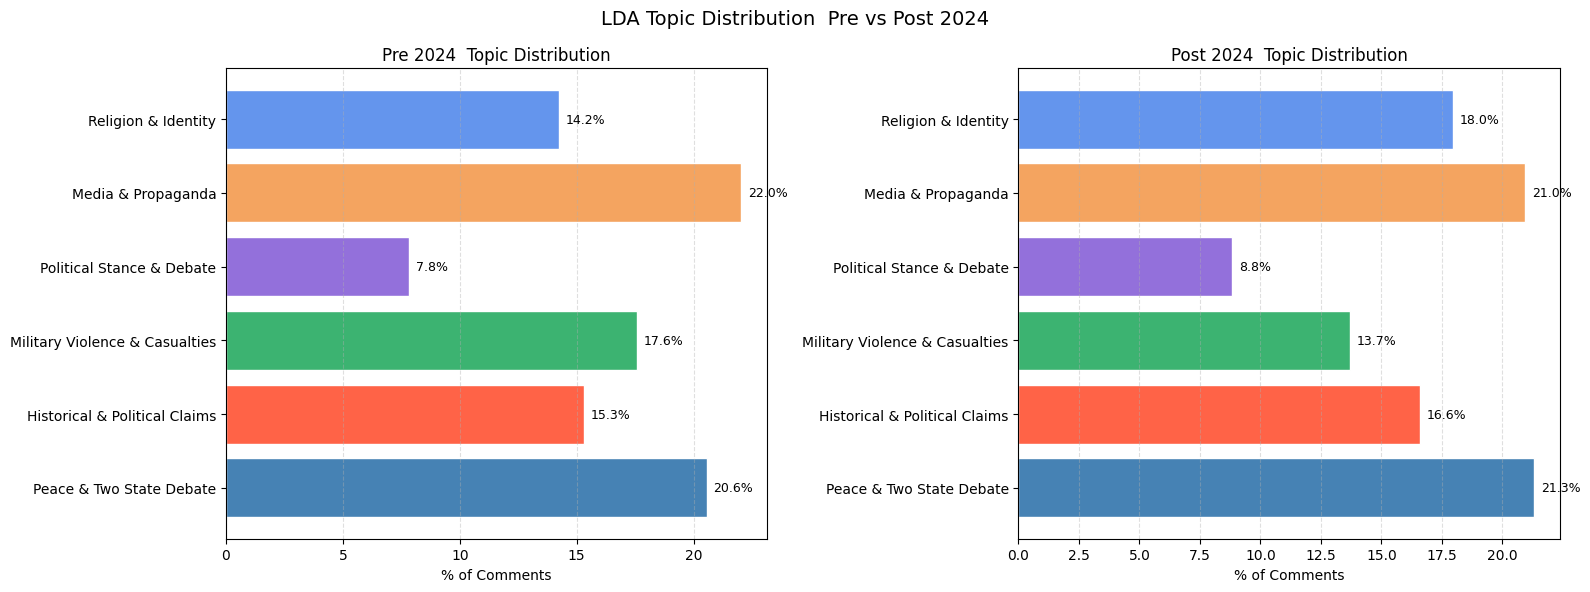

Plot saved


In [ ]:
# 5.1.6
# plotting topic distribution pre vs post 2024



fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LDA Topic Distribution  Pre vs Post 2024', fontsize=14)

for ax, (label, counts, df) in zip(axes, [
    ("Pre 2024",  pre_topic_counts,  df_pre_2024),
    ("Post 2024", post_topic_counts, df_post_2024)]):

    # exclude topic 2 (noise) from plot
    counts_clean = counts[counts.index != 2]
    labels_clean = [topic_labels[t] for t in counts_clean.index]
    pcts         = counts_clean / len(df) * 100

    bars = ax.barh(labels_clean, pcts,
                   color=['steelblue','tomato','mediumseagreen',
                          'mediumpurple','sandybrown','cornflowerblue'],
                   edgecolor='white')

    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontsize=9)

    ax.set_title(f'{label}  Topic Distribution')
    ax.set_xlabel('% of Comments')
    ax.grid(True, linestyle='--', alpha=0.4, axis='x')

plt.tight_layout()
plt.savefig(f'{prj_directory}/outputs/lda_topics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

### step 4 discussion Topic Distributions of LDA:

Pre 2024  Media and Propaganda is the biggest topic at 22%.
After October 7th, people were debating more on what is true
and what is false, and whether each party was lying or not. Military
Violence comes third at 17.6% considering the events that just
took place. Religion and Identity is the least prevalent topic at 14.2%.

Post 2024  Religion and Identity gained the most increasing
from 14.2% to 18.0%. With time, the parties involved began
framing the conflict through religion. Military Violence decreased
from 17.6% to 13.7% which shows that less talk was done on
the attacks with the passage of time. Media and Propaganda
remained relatively stable at 21.0%.

Main finding  people had more debates on what was true and
who was lying rather than any other topic.

### ***Method 2 K-Means Clustering***

### Step 1: Using TF-IDF matrix & Test k using elbow method:

Grouping the comments into clusters using the words and tones as similarity criteria, with the help of K-Means with TF-IDF. The elbow technique helps us get the the optimal number of clusters and we examine the words for each cluster.

--------------------------------------------------
Elbow method finding optimal k
--------------------------------------------------
  Testing k = 2...
  k = 2 done  inertia : 410,118.5
  Testing k = 3...
  k = 3 done  inertia : 407,143.7
  Testing k = 4...
  k = 4 done  inertia : 408,869.2
  Testing k = 5...
  k = 5 done  inertia : 405,664.8
  Testing k = 6...
  k = 6 done  inertia : 405,328.9
  Testing k = 7...
  k = 7 done  inertia : 404,686.2
  Testing k = 8...
  k = 8 done  inertia : 404,867.6
  Testing k = 9...
  k = 9 done  inertia : 403,948.7
  Testing k = 10...
  k = 10 done  inertia : 403,413.6

finally completed!


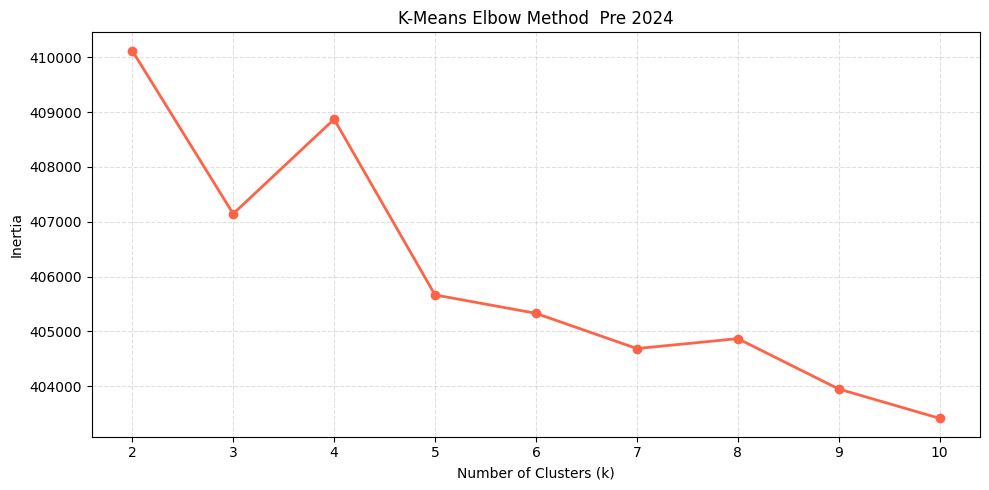

--------------------------------------------------
scores
--------------------------------------------------
  k =  2  :  410,118.5
  k =  3  :  407,143.7
  k =  4  :  408,869.2
  k =  5  :  405,664.8
  k =  6  :  405,328.9
  k =  7  :  404,686.2
  k =  8  :  404,867.6
  k =  9  :  403,948.7
  k = 10  :  403,413.6


In [ ]:
# 5.2.1
from sklearn.cluster import KMeans, MiniBatchKMeans

# finding optimal k using elbow method
# using MiniBatchKMeans  much faster than regular KMeans
# on large datasets like ours
# testing k from 2 to 10


print("-" * 50)
print("Elbow method finding optimal k")
print("-" * 50)

k_values  = range(2, 11)
inertias  = []

for k in k_values:
    print(f"  Testing k = {k}...")
    km = MiniBatchKMeans(
        n_clusters   = k,
        random_state = 42,
        batch_size   = 4096,
        n_init       = 3
    )
    km.fit(tfidf_pre)
    inertias.append(km.inertia_)
    print(f"  k = {k} done  inertia : {km.inertia_:,.1f}")

print("\nfinally completed!")


# plotting elbow curve

plt.figure(figsize=(10, 5))
plt.plot(list(k_values), inertias, marker='o',
         color='tomato', linewidth=2, markersize=6)
plt.title('K-Means Elbow Method  Pre 2024')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(list(k_values))
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{prj_directory}/outputs/kmeans_elbow.png', dpi=150)
plt.show()

print("-" * 50)
print("scores")
print("-" * 50)
for k, inertia in zip(k_values, inertias):
    print(f"  k = {k:>2}  :  {inertia:,.1f}")

### K-means Elbow Method Discussion:

The largest drop is seen  at k=2 and k=3. Beyond k=5
inertia is stable meaning no improvement when increasing k.
so, we select k=5.

### step 2 : Train final K-Means

In [ ]:
# 5.2.2
from sklearn.cluster import MiniBatchKMeans

# training final K-Means model with k = 5
# using MiniBatchKMeans for speed on large dataset


top_k_2 = 5

print("-" * 50)
print(f"training with k = {top_k_2}")
print("-" * 50)

km_model = MiniBatchKMeans(
    n_clusters   = top_k_2,
    random_state = 42,
    batch_size   = 4096,
    n_init       = 10
)

# fit on pre 2024
km_model.fit(tfidf_pre)
print("Pre 2024 fitted!")

# assign cluster labels
df_pre_2024['cluster']  = km_model.predict(tfidf_pre)
df_post_2024['cluster'] = km_model.predict(tfidf_post)

print(f"Pre  2024 clusters assigned : {df_pre_2024['cluster'].value_counts().sort_index().to_dict()}")
print(f"Post 2024 clusters assigned : {df_post_2024['cluster'].value_counts().sort_index().to_dict()}")


# showing top 15 words per cluster

feature_names = tfidf_vectorizer.get_feature_names_out()

print("\n" + "=" * 60)
print("  top 15 words per cluster ")
print("=" * 60)

for cluster_idx in range(top_k_2):
    # get cluster center and top words
    center    = km_model.cluster_centers_[cluster_idx]
    top_words = [feature_names[i] for i in center.argsort()[:-16:-1]]

    print(f"\n  cluster {cluster_idx}")
    print("  " + "-" * 50)
    print(f"  {' | '.join(top_words)}")

--------------------------------------------------
training with k = 5
--------------------------------------------------
Pre 2024 fitted!
Pre  2024 clusters assigned : {0: 91295, 1: 252456, 2: 13658, 3: 7947, 4: 49354}
Post 2024 clusters assigned : {0: 135396, 1: 403939, 2: 16863, 3: 926, 4: 64984}

  top 15 words per cluster 

  cluster 0
  --------------------------------------------------
  right | state | land | country | thats | side | support | peace | never | world | many | solution | year | government | time

  cluster 1
  --------------------------------------------------
  civilian | child | time | video | terrorist | hospital | world | year | didnt | cant | killed | youre | genocide | many | look

  cluster 2
  --------------------------------------------------
  muslim | christian | country | islam | muslim country | world | religion | dont | hate | many | land | state | muslim world | muslim christian | right

  cluster 3
  ------------------------------------------------

### Labels for K-Means Clusters discussion

After doing a K-Means clustering with k=5, we found the most common words in each cluster and labeled them accordingly:

Cluster 0   Political and Peace Argument
people talk about the territory, state, and peaceful resolution of the conflict.

Cluster 1   Violence and Military Losses
Conversation on victims, children, hospitals, and genocide.

Cluster 2   Religion and Identities
Individuals describing the war in terms of religion and hatred.

Cluster 3   Moderators and Bots
Machine posts by moderators excluded from the analysis.

Cluster 4   Skepticism and Indifference
Individuals who question other people's motives or doubt both sides.

### step 3: visualize, label cluster & pre 2024 & post 2024 compare

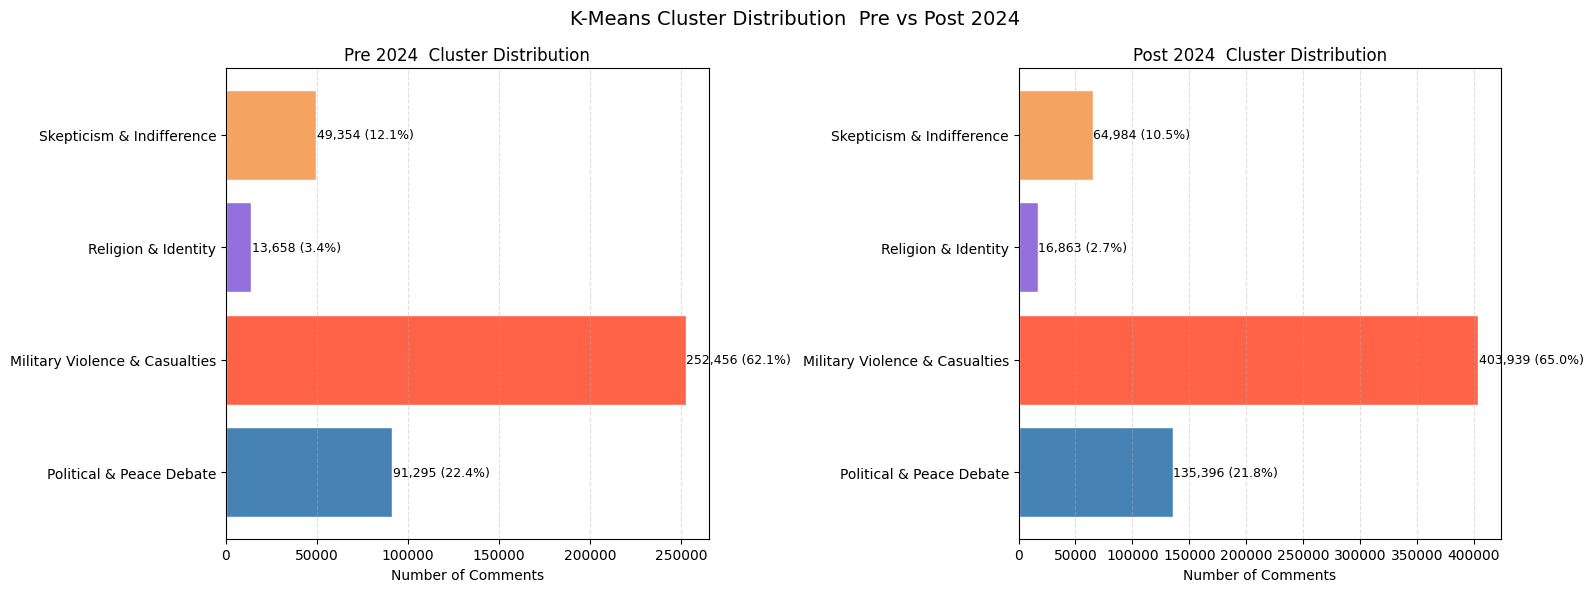

Plot saved


In [ ]:
# 5.2.3
# visualizing cluster distribution pre vs post 2024
# excluding cluster 3 (bot noise)


cluster_labels = {
    0 : 'Political & Peace Debate',
    1 : 'Military Violence & Casualties',
    2 : 'Religion & Identity',
    3 : 'Bot/Mod Noise',
    4 : 'Skepticism & Indifference'
}

cluster_colors = {
    0 : 'steelblue',
    1 : 'tomato',
    2 : 'mediumpurple',
    3 : 'gray',
    4 : 'sandybrown'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('K-Means Cluster Distribution  Pre vs Post 2024', fontsize=14)

for ax, (label, df) in zip(axes, [("Pre 2024", df_pre_2024), ("Post 2024", df_post_2024)]):

    # exclude cluster 3 noise
    counts = df[df['cluster'] != 3]['cluster'].value_counts().sort_index()
    labels = [cluster_labels[c] for c in counts.index]
    colors = [cluster_colors[c] for c in counts.index]
    total  = len(df[df['cluster'] != 3])

    bars = ax.barh(labels, counts.values, color=colors, edgecolor='white')

    for bar, count in zip(bars, counts.values):
        pct = count / total * 100
        ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                f'{count:,} ({pct:.1f}%)', va='center', fontsize=9)

    ax.set_title(f'{label}  Cluster Distribution')
    ax.set_xlabel('Number of Comments')
    ax.grid(True, linestyle='--', alpha=0.4, axis='x')

plt.tight_layout()
plt.savefig(f'{prj_directory}/outputs/kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")


In [ ]:
# 5.2.4
# printing cluster distribution

print("\n" + "=" * 60)
print("  cluster distribution pre 2024")
print("=" * 60)
for cluster, count in df_pre_2024['cluster'].value_counts().sort_index().items():
    pct   = count / len(df_pre_2024) * 100
    label = cluster_labels[cluster]
    print(f"  Cluster {cluster}  {label:<35} : {count:>8,}  ({pct:.1f}%)")

print("\n" + "=" * 60)
print("cluster distribution post 2024")
print("=" * 60)
for cluster, count in df_post_2024['cluster'].value_counts().sort_index().items():
    pct   = count / len(df_post_2024) * 100
    label = cluster_labels[cluster]
    print(f"  Cluster {cluster}  {label:<35} : {count:>8,}  ({pct:.1f}%)")


  cluster distribution pre 2024
  Cluster 0  Political & Peace Debate            :   91,295  (22.0%)
  Cluster 1  Military Violence & Casualties      :  252,456  (60.9%)
  Cluster 2  Religion & Identity                 :   13,658  (3.3%)
  Cluster 3  Bot/Mod Noise                       :    7,947  (1.9%)
  Cluster 4  Skepticism & Indifference           :   49,354  (11.9%)

cluster distribution post 2024
  Cluster 0  Political & Peace Debate            :  135,396  (21.8%)
  Cluster 1  Military Violence & Casualties      :  403,939  (64.9%)
  Cluster 2  Religion & Identity                 :   16,863  (2.7%)
  Cluster 3  Bot/Mod Noise                       :      926  (0.1%)
  Cluster 4  Skepticism & Indifference           :   64,984  (10.4%)


### Discussion About K-Means Clustering Distributions

"Violence and Casualties" is the largest cluster in both datasets - 60.9% prior to 2024 and 64.9% after 2024. The overwhelming majority of users on Reddit discuss the topics related to death and injuries of civilians above everything else.

"Politics and Peaceful Resolutions" stayed rather stable at about 22% in both periods suggesting that there was always heated discussion on how to resolve the conflict.

"Skepticism and Indifference" slightly decreased from 11.9% to 10.4%, meaning that there were less users voicing skepticism and indifference to the topic.

"Religion and Identity" remained relatively insignificant at approximately 3% in both datasets.

Finally, the noise level decreased from 1.9% to 0.1%.

## ***Section 6 - Supervised Learning:***

Two independent supervised learning tests were conducted, first by using VADER sentiment labels and then Huggingface emotion labels as the ground truth labels. These two experiments were carried out separately in both pre 2024 and post 2024 data for comparative purposes.

**Ground Truth  Main Experiment**
VADER labels (positive, negative, statement/irony/sarcasm)  3 classes

**Ground Truth  Secondary Experiment**
HuggingFace Emotion Labels (anger, disgust, fear, joy, neutral, sadness, surprise)  7 classes

**5 classifiers trained on the above mentioned datasets:**

    Naive Bayes
    Logistic Regression
    SGD Classifier
    SVM (LinearSVC)
    Random Forest

**Feature Extraction:**
- For the VADER experiment  TF-IDF (features = 10,000, unigram & bigram, sublinear_tf = True)
- For the emotion experiment  TF-IDF & numerical features (vader_score, emotion_score, word_count, upvote score)

**Evaluation Methodology:**

- 80/20 stratified train/test split
- 5-fold StratifiedKFold cross validation on training dataset
- Metrics  Accuracy, Precision, Recall, F1 Score (weighted)
- Hyper-parameter optimization with GridSearchCV (SVM, C = 0.01 to 10.0) on best classifier
- Confusion Matrix analysis on best classifier
- Top 20 feature words per class from SVM coefficients
- Comparison of features importance in pre/post 2024 data

### Step 1: Data Preparation

 preparing data to be used for supervised
learning and
split them into 80% for training and 20% for testing,
creating TF-IDF and bag of words feature matrices.


In [ ]:
# 6.1.1
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer



# we use the clean_text column we built in phase 4
# dropping rows with missing clean_text or labels


print("-" * 50)
print(" preparing data for supervised learning ")
print("-" * 50)


# using full dataset for both pre and post 2024

df_pre_clean  = df_pre_2024[['clean_text', 'emotion_label', 'vader_label']].dropna()
df_post_clean = df_post_2024[['clean_text', 'emotion_label', 'vader_label']].dropna()

print(f"Pre  2024 clean : {len(df_pre_clean):,}")
print(f"Post 2024 clean : {len(df_post_clean):,}")


# label distribution check

print("\n  pre 2024  Emotion label distribution:")
print(df_pre_clean['emotion_label'].value_counts())

print("\n  post 2024  Emotion label distribution:")
print(df_post_clean['emotion_label'].value_counts())




--------------------------------------------------
 preparing data for supervised learning 
--------------------------------------------------
Pre  2024 clean : 414,710
Post 2024 clean : 622,108

  pre 2024  Emotion label distribution:
emotion_label
neutral     164641
anger        96809
disgust      68365
fear         31435
surprise     24805
sadness      18663
joy           9992
Name: count, dtype: int64

  post 2024  Emotion label distribution:
emotion_label
neutral     256484
anger       126038
disgust     116041
fear         42376
surprise     37733
sadness      25599
joy          17837
Name: count, dtype: int64


In [ ]:
# 6.1.2
# 80/20 train test split for both datasets
# stratified to keep label distribution balanced


# pre 2024
X_pre  = df_pre_clean['clean_text']
y_pre_emotion = df_pre_clean['emotion_label']
y_pre_vader   = df_pre_clean['vader_label']

X_pre_train, X_pre_test, \
y_pre_emotion_train, y_pre_emotion_test, \
y_pre_vader_train, y_pre_vader_test = train_test_split(
    X_pre, y_pre_emotion, y_pre_vader,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y_pre_emotion
)

# post 2024
X_post  = df_post_clean['clean_text']
y_post_emotion = df_post_clean['emotion_label']
y_post_vader   = df_post_clean['vader_label']

X_post_train, X_post_test, \
y_post_emotion_train, y_post_emotion_test, \
y_post_vader_train, y_post_vader_test = train_test_split(
    X_post, y_post_emotion, y_post_vader,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y_post_emotion
)

print("-" * 50)
print("train test split done")
print("-" * 50)
print(f"Pre  2024  Train : {len(X_pre_train):,}  Test : {len(X_pre_test):,}")
print(f"Post 2024  Train : {len(X_post_train):,}  Test : {len(X_post_test):,}")


# building TF-IDF features
# fitting on training data only  never on test data

print("-" * 50)
print("building TF-IDF features")
print("-" * 50)

tfidf = TfidfVectorizer(
    max_features = 10000,
    min_df       = 5,
    max_df       = 0.90,
    ngram_range  = (1, 2),
    sublinear_tf = True    # applies log scaling to term frequencies
)

# fit on pre 2024 training data
X_pre_train_tfidf  = tfidf.fit_transform(X_pre_train)
X_pre_test_tfidf   = tfidf.transform(X_pre_test)

# fit on post 2024 training data separately
tfidf_post = TfidfVectorizer(
    max_features = 10000,
    min_df       = 5,
    max_df       = 0.90,
    ngram_range  = (1, 2),
    sublinear_tf = True
)
X_post_train_tfidf = tfidf_post.fit_transform(X_post_train)
X_post_test_tfidf  = tfidf_post.transform(X_post_test)

print(f"Pre  2024 TF-IDF  Train : {X_pre_train_tfidf.shape}  Test : {X_pre_test_tfidf.shape}")
print(f"Post 2024 TF-IDF  Train : {X_post_train_tfidf.shape}  Test : {X_post_test_tfidf.shape}")


--------------------------------------------------
train test split done
--------------------------------------------------
Pre  2024  Train : 331,768  Test : 82,942
Post 2024  Train : 497,686  Test : 124,422
--------------------------------------------------
building TF-IDF features
--------------------------------------------------
Pre  2024 TF-IDF  Train : (331768, 10000)  Test : (82942, 10000)
Post 2024 TF-IDF  Train : (497686, 10000)  Test : (124422, 10000)



### Step 2: Training 5 Classifiers with VADER Sentiment Labels

The training data contains 5 classifiers that will classify the sentiment of the comments based on the VADER labels.
The 3 classes are: positive, negative, statement/irony/sarcasm. We will use the TF-IDF features and class_weight=balanced
since there is an imbalanced dataset. Each model will be validated using 5-fold cross-validation and tested on the hold-out
20% test set. We will perform training for both the pre- and post-2024 datasets independently for comparison.

Ground truth: VADER labels (positive/negative/statement/irony/sarcasm)
Features: TF-IDF (unigrams + bigrams, top 10,000 features)
Split: 80% train, 20% test
Cross Val: 5-fold

In [ ]:
# 6.1.3
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time


# VADER labels as ground truth  3 classes
# positive / negative / statement/irony/sarcasm


skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

def train_and_evaluate(model, model_name, X_train, X_test,
                        y_train, y_test, dataset_name, run_cv=True):

    print(f"\n  Training {model_name} on {dataset_name}...")
    start = time.time()

    if run_cv:
        cv_scores = cross_val_score(model, X_train, y_train,
                                     cv=skf, scoring='f1_weighted',
                                     n_jobs=-1)
        cv_mean = round(cv_scores.mean(), 4)
        cv_std  = round(cv_scores.std(), 4)
    else:
        cv_mean = 'N/A'
        cv_std  = 'N/A'

    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    elapsed = time.time() - start

    print(f"  Done! Acc: {acc:.4f}  F1: {f1:.4f}  CV F1: {cv_mean}  Time: {elapsed:.1f}s")

    results.append({
        'Dataset'   : dataset_name,
        'Model'     : model_name,
        'CV F1'     : cv_mean,
        'CV Std'    : cv_std,
        'Accuracy'  : round(acc, 4),
        'Precision' : round(prec, 4),
        'Recall'    : round(rec, 4),
        'F1 Score'  : round(f1, 4)
    })

    return model, y_pred


# split by VADER labels  stratified

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

df_pre_vader  = df_pre_2024[['clean_text', 'vader_label']].dropna()
df_post_vader = df_post_2024[['clean_text', 'vader_label']].dropna()

# pre 2024 split
X_pre_v_train, X_pre_v_test, \
y_pre_v_train, y_pre_v_test = train_test_split(
    df_pre_vader['clean_text'], df_pre_vader['vader_label'],
    test_size=0.2, random_state=42,
    stratify=df_pre_vader['vader_label'])

# post 2024 split
X_post_v_train, X_post_v_test, \
y_post_v_train, y_post_v_test = train_test_split(
    df_post_vader['clean_text'], df_post_vader['vader_label'],
    test_size=0.2, random_state=42,
    stratify=df_post_vader['vader_label'])

print("-" * 50)
print("VADER splitting")
print("-" * 50)
print(f"Pre  2024  Train: {len(X_pre_v_train):,}  Test: {len(X_pre_v_test):,}")
print(f"Post 2024  Train: {len(X_post_v_train):,}  Test: {len(X_post_v_test):,}")


# TF-IDF features  fit on training only

tfidf_v = TfidfVectorizer(
    max_features=10000, min_df=5, max_df=0.90,
    ngram_range=(1, 2), sublinear_tf=True)

X_pre_v_train_tfidf = tfidf_v.fit_transform(X_pre_v_train)
X_pre_v_test_tfidf  = tfidf_v.transform(X_pre_v_test)

tfidf_v_post = TfidfVectorizer(
    max_features=10000, min_df=5, max_df=0.90,
    ngram_range=(1, 2), sublinear_tf=True)

X_post_v_train_tfidf = tfidf_v_post.fit_transform(X_post_v_train)
X_post_v_test_tfidf  = tfidf_v_post.transform(X_post_v_test)

print(f"Pre  TF-IDF: {X_pre_v_train_tfidf.shape}")
print(f"Post TF-IDF: {X_post_v_train_tfidf.shape}")


# 5 models  VADER labels  PRE 2024

def get_models():
    return {
        'Naive Bayes'         : ComplementNB(),
        'Logistic Regression' : LogisticRegression(
                                    max_iter=1000, class_weight='balanced',
                                    random_state=42, n_jobs=-1),
        'SGD Classifier'      : SGDClassifier(
                                    loss='modified_huber', class_weight='balanced',
                                    random_state=42, n_jobs=-1, max_iter=300),
        'SVM'                 : LinearSVC(
                                    class_weight='balanced',
                                    random_state=42, max_iter=2000),
        'Random Forest'       : RandomForestClassifier(
                                    n_estimators=100, class_weight='balanced',
                                    random_state=42, n_jobs=-1)
    }

print("-" * 60)
print("Training all models pre 2024 VADER labels")
print("-" * 60)

trained_pre_vader = {}
preds_pre_vader   = {}

for model_name, model in get_models().items():
    run_cv = model_name != 'Random Forest'
    model, y_pred = train_and_evaluate(
        model, model_name,
        X_pre_v_train_tfidf, X_pre_v_test_tfidf,
        y_pre_v_train, y_pre_v_test,
        'Pre 2024 VADER', run_cv=run_cv)
    trained_pre_vader[model_name] = model
    preds_pre_vader[model_name]   = y_pred


--------------------------------------------------
VADER splitting
--------------------------------------------------
Pre  2024  Train: 331,768  Test: 82,942
Post 2024  Train: 497,686  Test: 124,422
Pre  TF-IDF: (331768, 10000)
Post TF-IDF: (497686, 10000)
------------------------------------------------------------
Training all models pre 2024 VADER labels
------------------------------------------------------------

  Training Naive Bayes on Pre 2024 VADER...
  Done! Acc: 0.6929  F1: 0.6951  CV F1: 0.6946  Time: 5.1s

  Training Logistic Regression on Pre 2024 VADER...
  Done! Acc: 0.7588  F1: 0.7697  CV F1: 0.7616  Time: 34.5s

  Training SGD Classifier on Pre 2024 VADER...
  Done! Acc: 0.7791  F1: 0.7844  CV F1: 0.7793  Time: 5.9s

  Training SVM on Pre 2024 VADER...
  Done! Acc: 0.7839  F1: 0.7887  CV F1: 0.7823  Time: 97.0s

  Training Random Forest on Pre 2024 VADER...
  Done! Acc: 0.7792  F1: 0.7767  CV F1: N/A  Time: 626.4s


In [ ]:
# post 2024 VADER labels
print("-" * 60)
print("Training all models pre 2024 VADER labels")
print("-" * 60)

trained_post_vader = {}
preds_post_vader   = {}

for model_name, model in get_models().items():
    run_cv = model_name != 'Random Forest'
    model, y_pred = train_and_evaluate(
        model, model_name,
        X_post_v_train_tfidf, X_post_v_test_tfidf,
        y_post_v_train, y_post_v_test,
        'Post 2024 VADER', run_cv=run_cv)
    trained_post_vader[model_name] = model
    preds_post_vader[model_name]   = y_pred

print("\n" + "-" * 60)
print("training done")
print("-" * 60)

------------------------------------------------------------
Training all models pre 2024 VADER labels
------------------------------------------------------------

  Training Naive Bayes on Post 2024 VADER...
  Done! Acc: 0.7023  F1: 0.7018  CV F1: 0.7005  Time: 7.1s

  Training Logistic Regression on Post 2024 VADER...
  Done! Acc: 0.7629  F1: 0.7719  CV F1: 0.7702  Time: 52.2s

  Training SGD Classifier on Post 2024 VADER...
  Done! Acc: 0.7744  F1: 0.7799  CV F1: 0.7812  Time: 8.2s

  Training SVM on Post 2024 VADER...
  Done! Acc: 0.7879  F1: 0.7921  CV F1: 0.7902  Time: 80.9s

  Training Random Forest on Post 2024 VADER...
  Done! Acc: 0.7583  F1: 0.7565  CV F1: N/A  Time: 1379.3s

------------------------------------------------------------
training done
------------------------------------------------------------


### Step 3: SVM Hyperparameter Optimization with GridSearchCV

 Optimizing the SVM model by performing hyperparameter tuning to determine the optimal C parameter. The parameter C helps us define the tolerance of the model; the bigger the C value, the stricter the model becomes. This can be determined through the value that provides the highest F1 score through cross-validation.

In [ ]:

# 6.1.4
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
import time


# GridSearchCV on SVM  pre 2024
# tuning C parameter  controls regularization strength
# higher C = less regularization = fits training data more


print("-" * 60)
print("GridSearchCV: for best [SVM] pre 2024 VADER labels")
print("-" * 60)

param_grid = {'C': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]}

svm_pre = LinearSVC(
    class_weight = 'balanced',
    random_state = 42,
    max_iter     = 3000
)

grid_pre = GridSearchCV(
    svm_pre,
    param_grid,
    cv      = 5,
    scoring = 'f1_weighted',
    n_jobs  = -1,
    verbose = 1
)

start = time.time()
grid_pre.fit(X_pre_v_train_tfidf, y_pre_v_train)
elapsed = time.time() - start

print(f"\nBest C      : {grid_pre.best_params_['C']}")
print(f"Best CV F1  : {grid_pre.best_score_:.4f}")
print(f"Time        : {elapsed:.1f}s")

best_svm_pre = grid_pre.best_estimator_
y_pred_pre   = best_svm_pre.predict(X_pre_v_test_tfidf)

acc_pre = accuracy_score(y_pre_v_test, y_pred_pre)
f1_pre  = f1_score(y_pre_v_test, y_pred_pre, average='weighted')

print(f"\nTest Accuracy : {acc_pre:.4f}")
print(f"Test F1       : {f1_pre:.4f}")

print("\nAll C values tested:")
for mean, std, params in zip(
    grid_pre.cv_results_['mean_test_score'],
    grid_pre.cv_results_['std_test_score'],
    grid_pre.cv_results_['params']):
    print(f"  C = {params['C']:<6}  CV F1 = {mean:.4f}  (+/- {std:.4f})")


# GridSearchCV on SVM  post 2024

print("\n" + "-" * 60)
print("GridSearchCV: for best [SVM] post 2024 VADER labels")
print("-" * 60)

svm_post = LinearSVC(
    class_weight = 'balanced',
    random_state = 42,
    max_iter     = 3000
)

grid_post = GridSearchCV(
    svm_post,
    param_grid,
    cv      = 5,
    scoring = 'f1_weighted',
    n_jobs  = -1,
    verbose = 1
)

start = time.time()
grid_post.fit(X_post_v_train_tfidf, y_post_v_train)
elapsed = time.time() - start

print(f"\nBest C      : {grid_post.best_params_['C']}")
print(f"Best CV F1  : {grid_post.best_score_:.4f}")
print(f"Time        : {elapsed:.1f}s")

best_svm_post = grid_post.best_estimator_
y_pred_post   = best_svm_post.predict(X_post_v_test_tfidf)

acc_post = accuracy_score(y_post_v_test, y_pred_post)
f1_post  = f1_score(y_post_v_test, y_pred_post, average='weighted')

print(f"\nTest Accuracy : {acc_post:.4f}")
print(f"Test F1       : {f1_post:.4f}")

print("\nAll C values tested:")
for mean, std, params in zip(
    grid_post.cv_results_['mean_test_score'],
    grid_post.cv_results_['std_test_score'],
    grid_post.cv_results_['params']):
    print(f"  C = {params['C']:<6}  CV F1 = {mean:.4f}  (+/- {std:.4f})")

print("\n" + "-" * 60)
print("GridSearchCV done")
print("-" * 60)
print(f"Pre  2024 best SVM  Acc: {acc_pre:.4f}  F1: {f1_pre:.4f}  C: {grid_pre.best_params_['C']}")
print(f"Post 2024 best SVM  Acc: {acc_post:.4f}  F1: {f1_post:.4f}  C: {grid_post.best_params_['C']}")

------------------------------------------------------------
GridSearchCV: for best [SVM] pre 2024 VADER labels
------------------------------------------------------------
Fitting 5 folds for each of 7 candidates, totalling 35 fits

Best C      : 0.1
Best CV F1  : 0.7846
Time        : 185.2s

Test Accuracy : 0.7864
Test F1       : 0.7912

All C values tested:
  C = 0.01    CV F1 = 0.7618  (+/- 0.0012)
  C = 0.1     CV F1 = 0.7846  (+/- 0.0014)
  C = 0.5     CV F1 = 0.7837  (+/- 0.0016)
  C = 1.0     CV F1 = 0.7823  (+/- 0.0015)
  C = 2.0     CV F1 = 0.7813  (+/- 0.0015)
  C = 5.0     CV F1 = 0.7805  (+/- 0.0016)
  C = 10.0    CV F1 = 0.7802  (+/- 0.0016)

------------------------------------------------------------
GridSearchCV: for best [SVM] post 2024 VADER labels
------------------------------------------------------------
Fitting 5 folds for each of 7 candidates, totalling 35 fits

Best C      : 0.1
Best CV F1  : 0.7905
Time        : 177.8s

Test Accuracy : 0.7880
Test F1       : 

### Discussion of GridSearchCV SVM Results

Tried out 7 different C values for our SVM model on
both the datasets. The best C value obtained for both the pre
and post 2024 dataset was 0.1.

Pre 2024  The tuned SVM had an accuracy of 78.6%
and F1 score of 0.7912.
Post 2024  The tuned SVM had an accuracy of 78.8%
and F1 score of 0.7923.

 the performance is pretty similar in both
the datasets. That indicates consistency in performance. C
values above 1 such as 5.0 and 10.0 actually decreased the
performance which indicates overfitting by the model.

Accuracy of 78.8% on 3 classes is an impressive number.
The random guess for 3 classes will have an accuracy of
33% which makes our model twice better than random
chance. This similarity in accuracy between the two sets
indicates that the pattern of language in this conflict didn't
change between the two time periods.

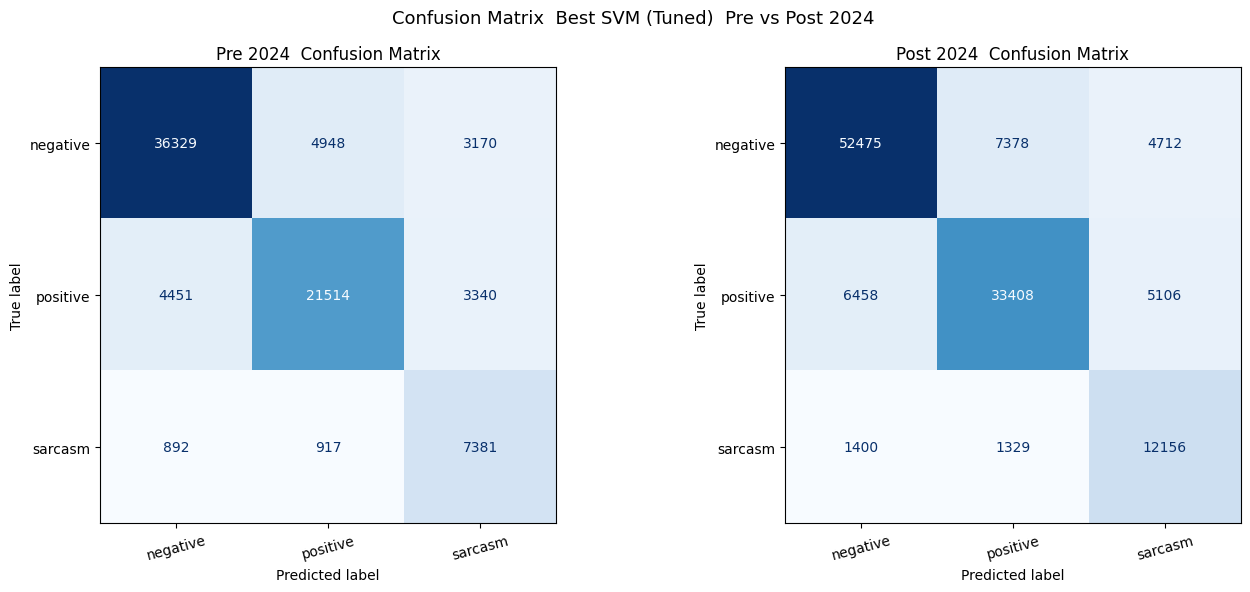

Plot saved

  confusion matrix  pre  2024
                                   pred_neg   pred_pos  pred_sarc
  ------------------------------------------------------------
  actual negative                    36,329      4,948      3,170
  actual positive                     4,451     21,514      3,340
  actual sarcasm                        892        917      7,381

  confusion matrix  post 2024
                                   pred_neg   pred_pos  pred_sarc
  ------------------------------------------------------------
  actual negative                    52,475      7,378      4,712
  actual positive                     6,458     33,408      5,106
  actual sarcasm                      1,400      1,329     12,156


In [ ]:

# 6.1.5
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# confusion matrix for best SVM on both datasets
# shows which classes get confused most often


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrix  Best SVM (Tuned)  Pre vs Post 2024', fontsize=13)

labels = ['negative', 'positive', 'statement/irony/sarcasm']

for ax, (title, y_test, y_pred) in zip(axes, [
    ('Pre 2024',  y_pre_v_test,  y_pred_pre),
    ('Post 2024', y_post_v_test, y_pred_post)]):

    cm = confusion_matrix(y_test, y_pred, labels=labels)

    disp = ConfusionMatrixDisplay(
        confusion_matrix = cm,
        display_labels   = ['negative', 'positive', 'sarcasm']
    )

    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}  Confusion Matrix')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(f'{prj_directory}/outputs/confusion_matrix_svm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")


# printing raw numbers

for title, y_test, y_pred in [
    ('pre  2024', y_pre_v_test,  y_pred_pre),
    ('post 2024', y_post_v_test, y_pred_post)]:

    cm = confusion_matrix(y_test, y_pred, labels=labels)
    print("\n" + "=" * 60)
    print(f"  confusion matrix  {title}")
    print("=" * 60)
    print(f"  {'':30} {'pred_neg':>10} {'pred_pos':>10} {'pred_sarc':>10}")
    print("  " + "-" * 60)
    for i, label in enumerate(['negative', 'positive', 'sarcasm']):
        print(f"  actual {label:<23} {cm[i][0]:>10,} {cm[i][1]:>10,} {cm[i][2]:>10,}")

### Discussion of Confusion Matrix

Negative sentiments were classified well in both data sets. Some
positive comments are also being classified as negatives, this is
understandable because of the nature of political comments that
have elements of both sentiments.

The sarcasm classification was challenging for the model.
This is because sarcasm makes use of positive sentiments to pass
a negative message.

The two confusion matrices have similar values hence
meaning that there was no changes in language patterns pre-
and post-2024.

The confusion matrix in general is great as it shows a high number
of correct predictions  see the darker diagonal.

------------------------------------------------------------
 top 20 words per sentiments pre 2024
------------------------------------------------------------

  NEGATIVE
  --------------------------------------------------
  killed                              : 4.2158
  terrorist                           : 4.1360
  kill                                : 3.7694
  killing                             : 3.6208
  dead                                : 3.4722
  hate                                : 3.1126
  fuck                                : 3.0873
  violence                            : 2.9771
  terrorism                           : 2.9669
  hell                                : 2.8897
  murdered                            : 2.8622
  evil                                : 2.8424
  murder                              : 2.8190
  attack                              : 2.8039
  hatred                              : 2.7907
  fucked                              : 2.7269
  wrong                

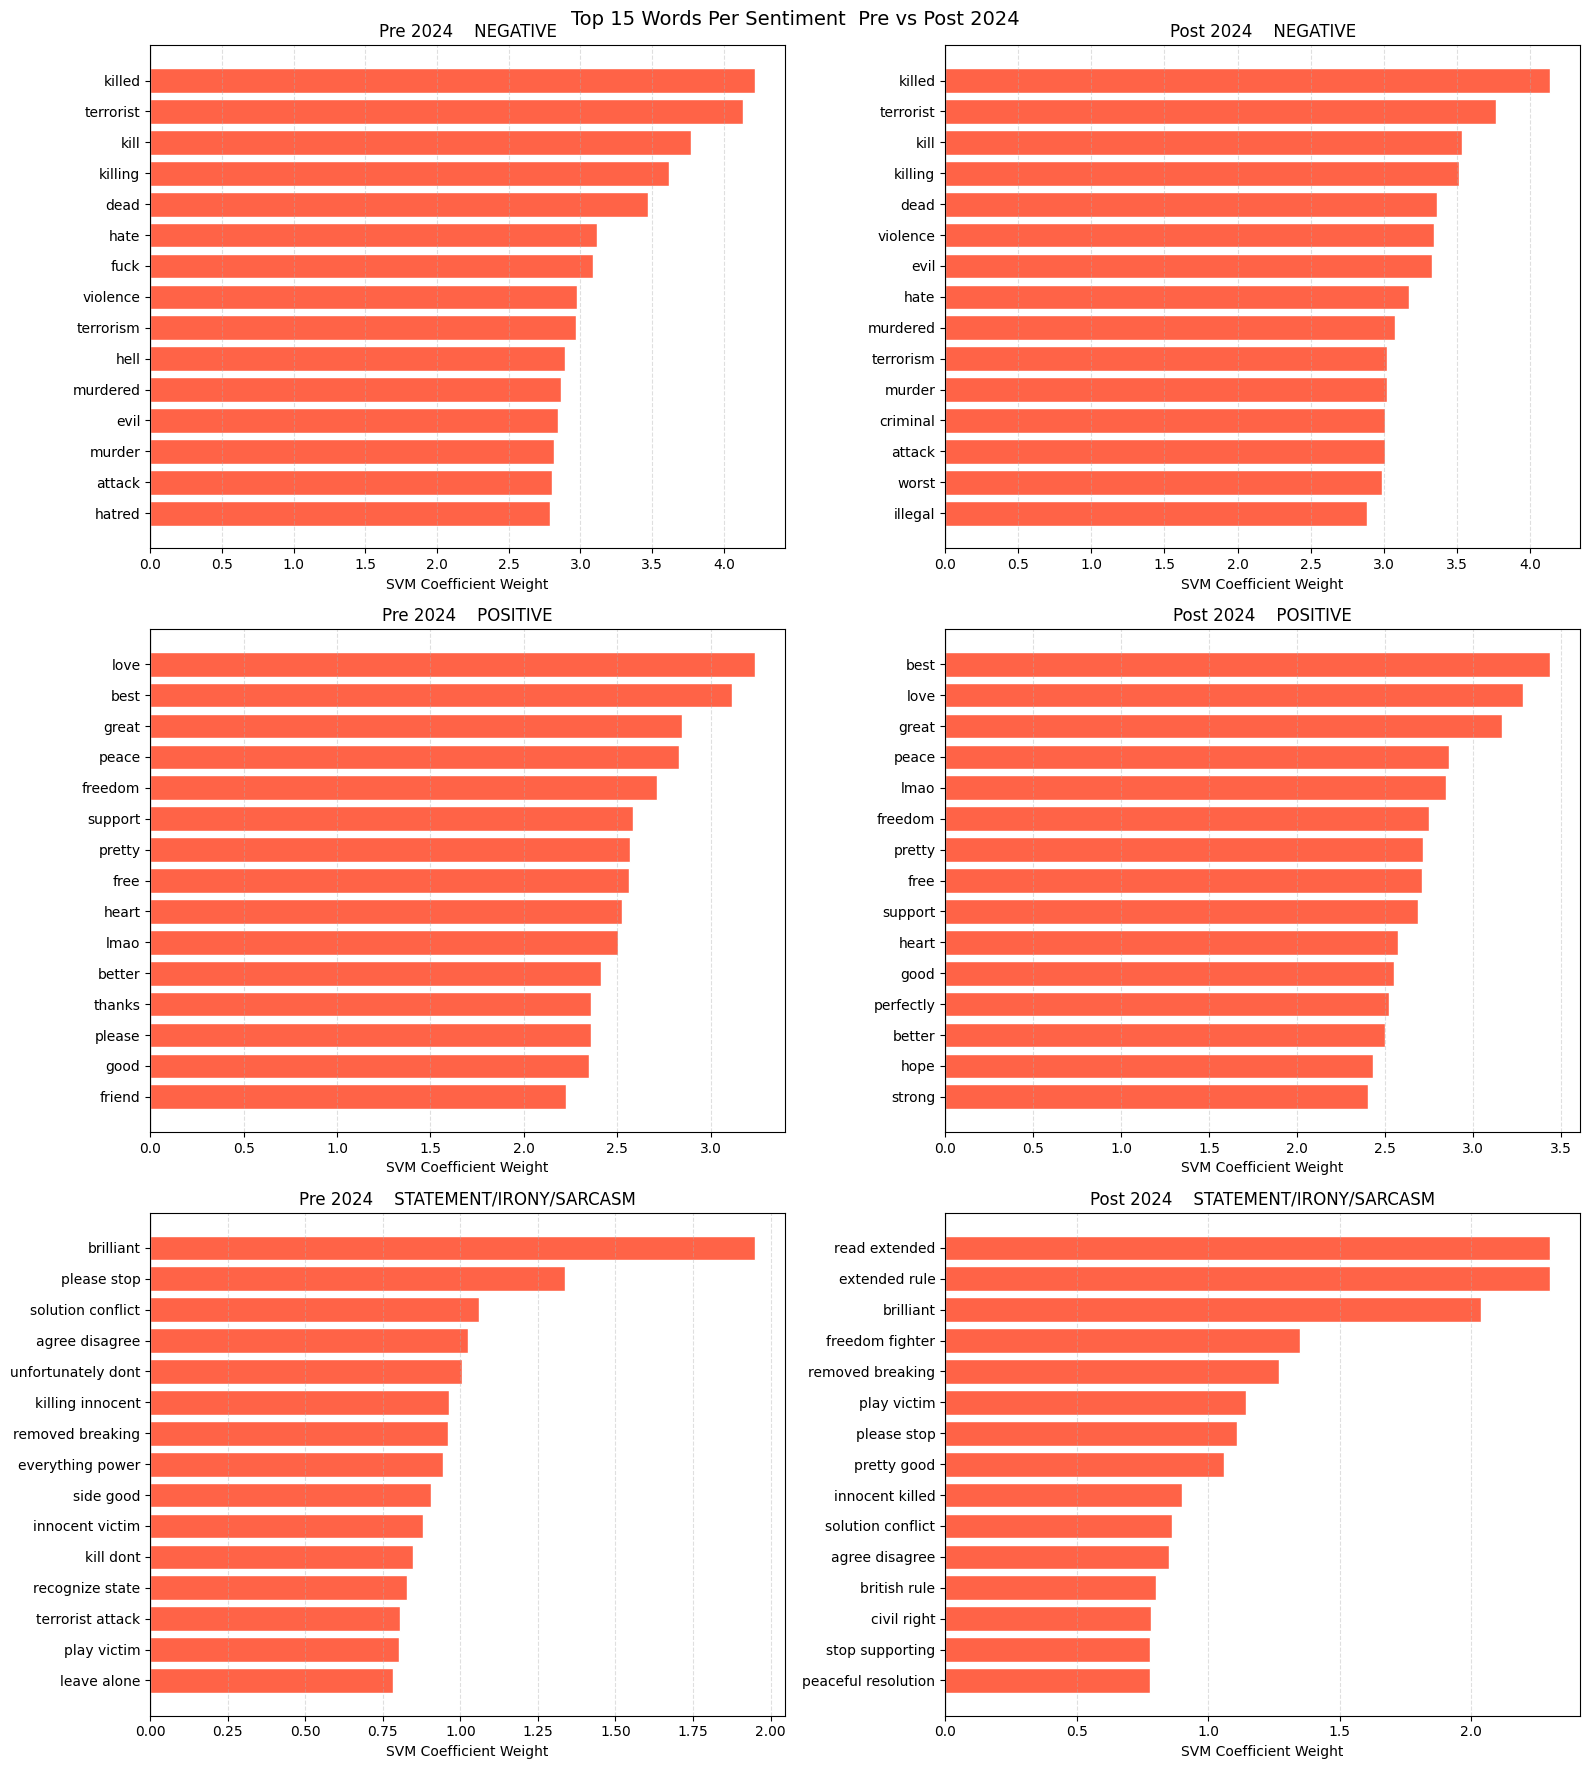

Plot saved


In [ ]:
# 6.1.6
# feature importance  top 20 words per sentiment
# using SVM coefficients  each class has weights
# higher weight = word strongly predicts that class


feature_names = np.array(tfidf_v.get_feature_names_out())

print("-" * 60)
print(" top 20 words per sentiments pre 2024")
print("-" * 60)

classes = best_svm_pre.classes_
for i, cls in enumerate(classes):
    coefs     = best_svm_pre.coef_[i]
    top_idx   = np.argsort(coefs)[-20:][::-1]
    top_words = feature_names[top_idx]
    top_vals  = coefs[top_idx]

    print(f"\n  {cls.upper()}")
    print("  " + "-" * 50)
    for word, val in zip(top_words, top_vals):
        print(f"  {word:<35} : {val:.4f}")

print("\n" + "-" * 60)
print(" top 20 words per sentiments pre 2024")
print("-" * 60)

feature_names_post = np.array(tfidf_v_post.get_feature_names_out())

classes_post = best_svm_post.classes_
for i, cls in enumerate(classes_post):
    coefs     = best_svm_post.coef_[i]
    top_idx   = np.argsort(coefs)[-20:][::-1]
    top_words = feature_names_post[top_idx]
    top_vals  = coefs[top_idx]

    print(f"\n  {cls.upper()}")
    print("  " + "-" * 50)
    for word, val in zip(top_words, top_vals):
        print(f"  {word:<35} : {val:.4f}")


# plotting top 15 words per class  pre vs post side by side


fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Top 15 Words Per Sentiment  Pre vs Post 2024', fontsize=14)

for row, cls in enumerate(classes):
    for col, (title, svm_model, feat_names) in enumerate([
        ('Pre 2024',  best_svm_pre,  feature_names),
        ('Post 2024', best_svm_post, feature_names_post)]):

        ax    = axes[row][col]
        coefs = svm_model.coef_[row]

        top_idx   = np.argsort(coefs)[-15:]
        top_words = feat_names[top_idx]
        top_vals  = coefs[top_idx]

        colors = ['tomato' if v > 0 else 'steelblue' for v in top_vals]
        ax.barh(top_words, top_vals, color=colors, edgecolor='white')
        ax.set_title(f'{title}    {cls.upper()}')
        ax.set_xlabel('SVM Coefficient Weight')
        ax.grid(True, linestyle='--', alpha=0.4, axis='x')
        ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig(f'{prj_directory}/outputs/top_phrases_per_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

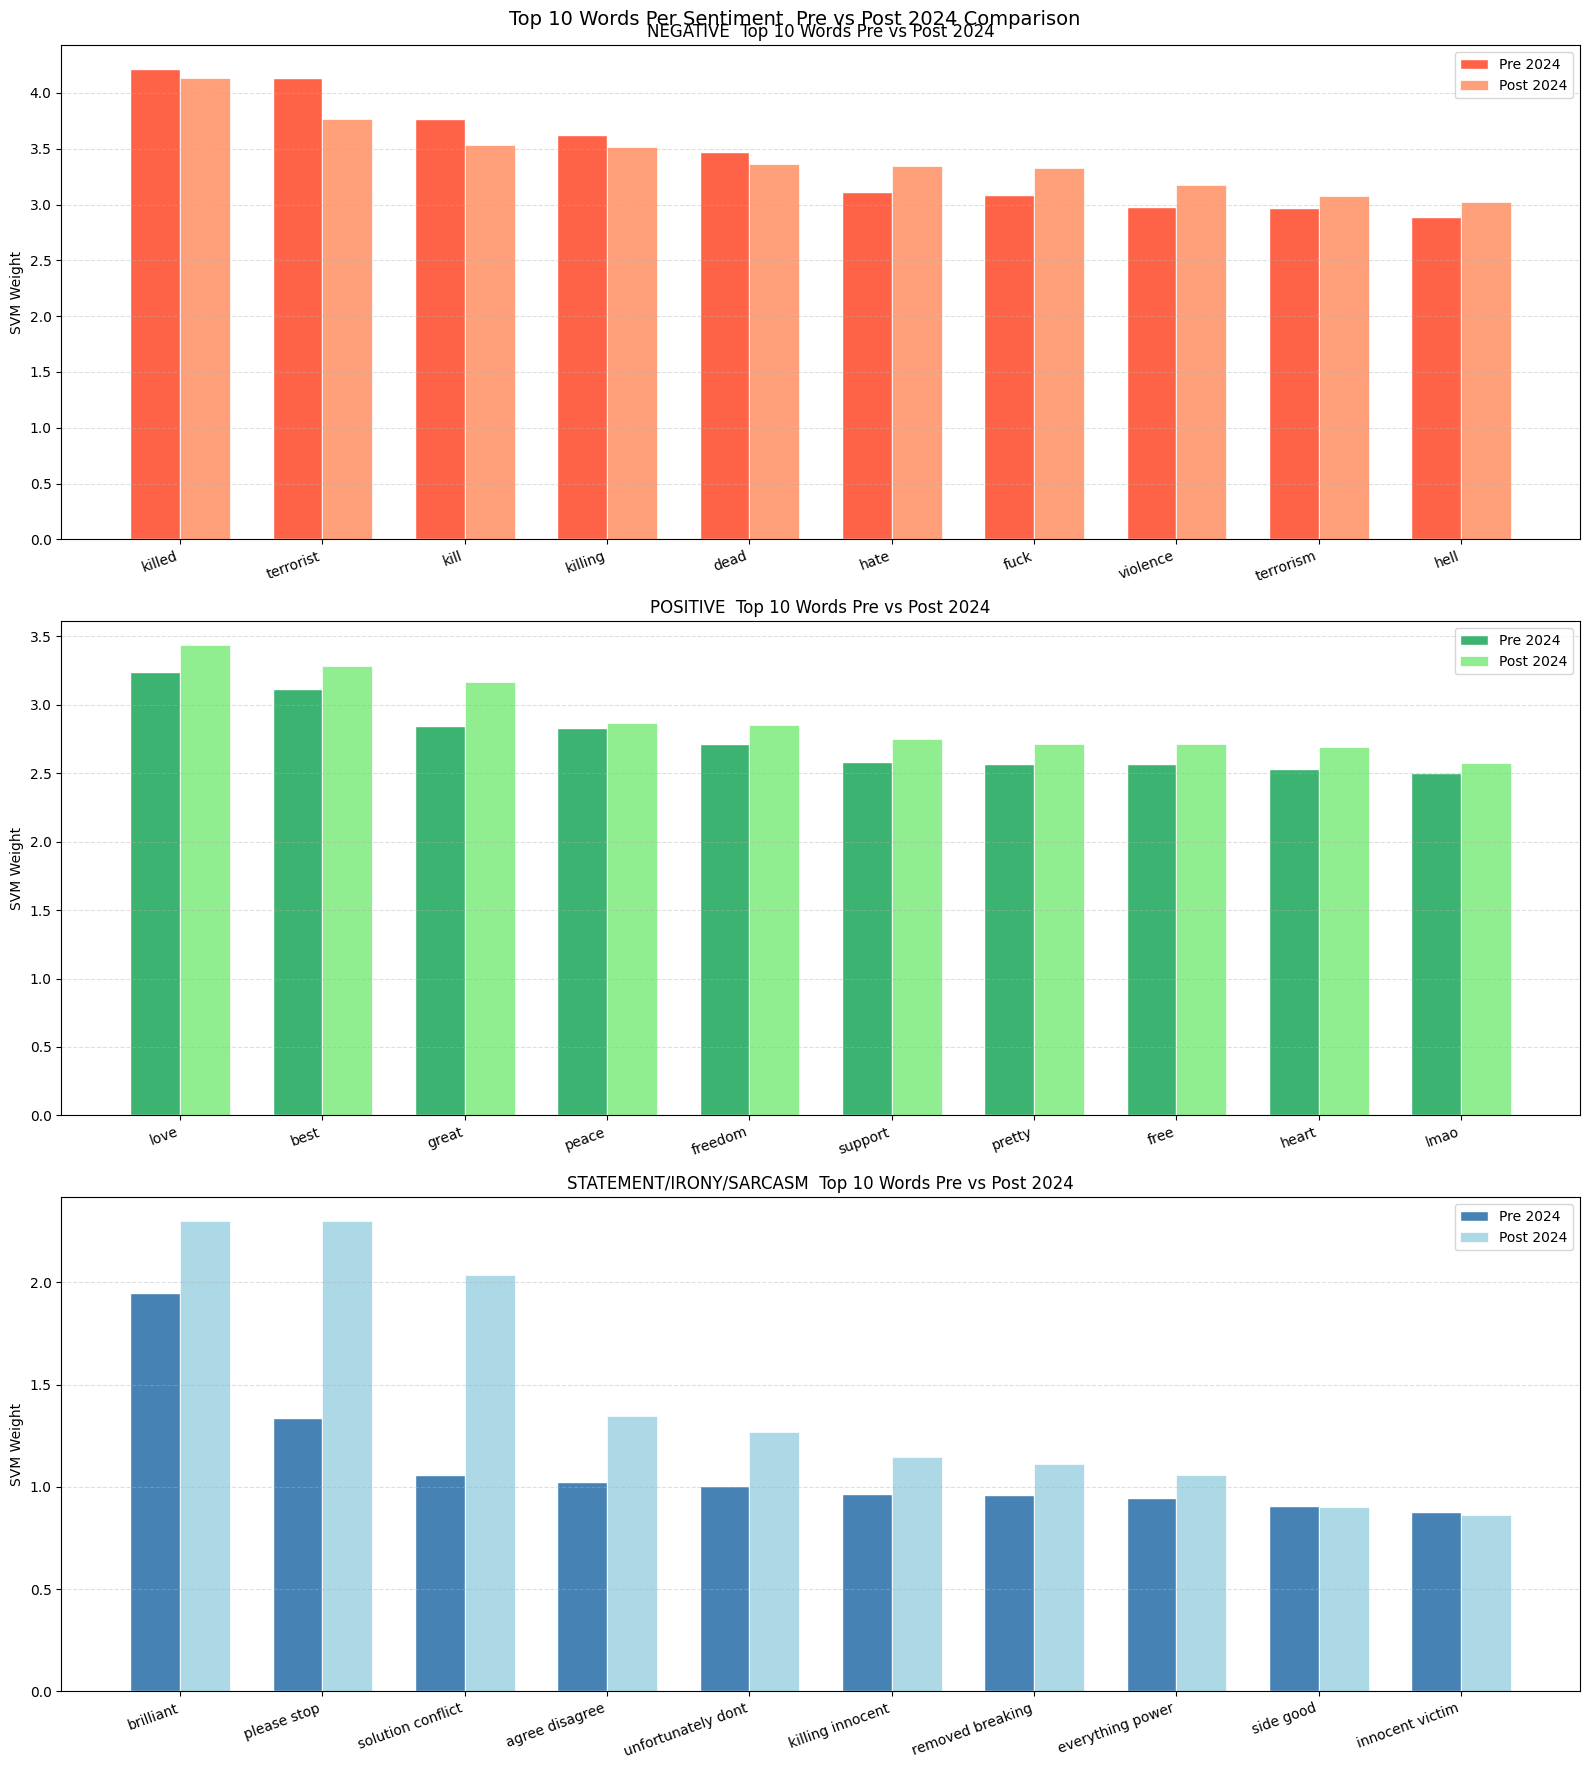

In [ ]:
# 6.1.7
# comparing top 10 words per class pre vs post 2024
# showing side by side for each sentiment


fig, axes = plt.subplots(3, 1, figsize=(16, 18))
fig.suptitle('Top 10 Words Per Sentiment  Pre vs Post 2024 Comparison', fontsize=14)

sentiment_colors = {
    'negative'               : ('tomato',       'lightsalmon'),
    'positive'               : ('mediumseagreen','lightgreen'),
    'statement/irony/sarcasm': ('steelblue',     'lightblue')
}

for row, cls in enumerate(best_svm_pre.classes_):

    ax = axes[row]

    # get top 10 words for pre 2024
    coefs_pre   = best_svm_pre.coef_[row]
    top_idx_pre = np.argsort(coefs_pre)[-10:][::-1]
    words_pre   = feature_names[top_idx_pre]
    vals_pre    = coefs_pre[top_idx_pre]

    # get top 10 words for post 2024
    coefs_post   = best_svm_post.coef_[row]
    top_idx_post = np.argsort(coefs_post)[-10:][::-1]
    words_post   = feature_names_post[top_idx_post]
    vals_post    = coefs_post[top_idx_post]

    x       = np.arange(10)
    width   = 0.35
    color1, color2 = sentiment_colors[cls]

    ax.bar(x - width/2, vals_pre,  width, label='Pre 2024',  color=color1, edgecolor='white')
    ax.bar(x + width/2, vals_post, width, label='Post 2024', color=color2, edgecolor='white', linewidth=0.5)

    ax.set_title(f'{cls.upper()}  Top 10 Words Pre vs Post 2024')
    ax.set_xticks(x)
    ax.set_xticklabels(words_pre, rotation=20, ha='right')
    ax.set_ylabel('SVM Weight')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig(f'{prj_directory}/outputs/feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Pre vs Post 2024 Feature Importance Comparison

Words with negative connotation remained about the same. The word killed, terrorist, kill, killing and dead are the most important words for the same time period. The bars are about the same length since there is no difference in the use of negative words after October 7th.

Positive words were also the same. Love, best, great, peace
and freedom are most important in both periods. There is a
slight difference that bars for post 2024 are somewhat taller than those for pre 2024 since people used a little bit stronger positive words after the situation escalated.

Sarcasm has the largest difference. Bars for post 2024 are
somewhat higher than for pre 2024 with the words such as
brilliant, please stop and solution conflict.

--------------------------------------------------------------------------------
  FINAL MODEL COMPARISON TABLE  VADER LABELS
--------------------------------------------------------------------------------

  pre 2024
  ----------------------------------------------------------------------
  Model                       Accuracy  Precision     Recall   F1 Score      CV F1
  ----------------------------------------------------------------------
  Naive Bayes                   0.6929     0.6977     0.6929     0.6951     0.6946
  Logistic Regression           0.7588     0.7993     0.7588     0.7697     0.7616
  SGD Classifier                0.7791     0.7989     0.7791     0.7844     0.7793
  SVM                           0.7839     0.8003     0.7839     0.7887     0.7823
  Random Forest                 0.7792      0.778     0.7792     0.7767        N/A

  post 2024
  ----------------------------------------------------------------------
  Model                       Accuracy  Precision  

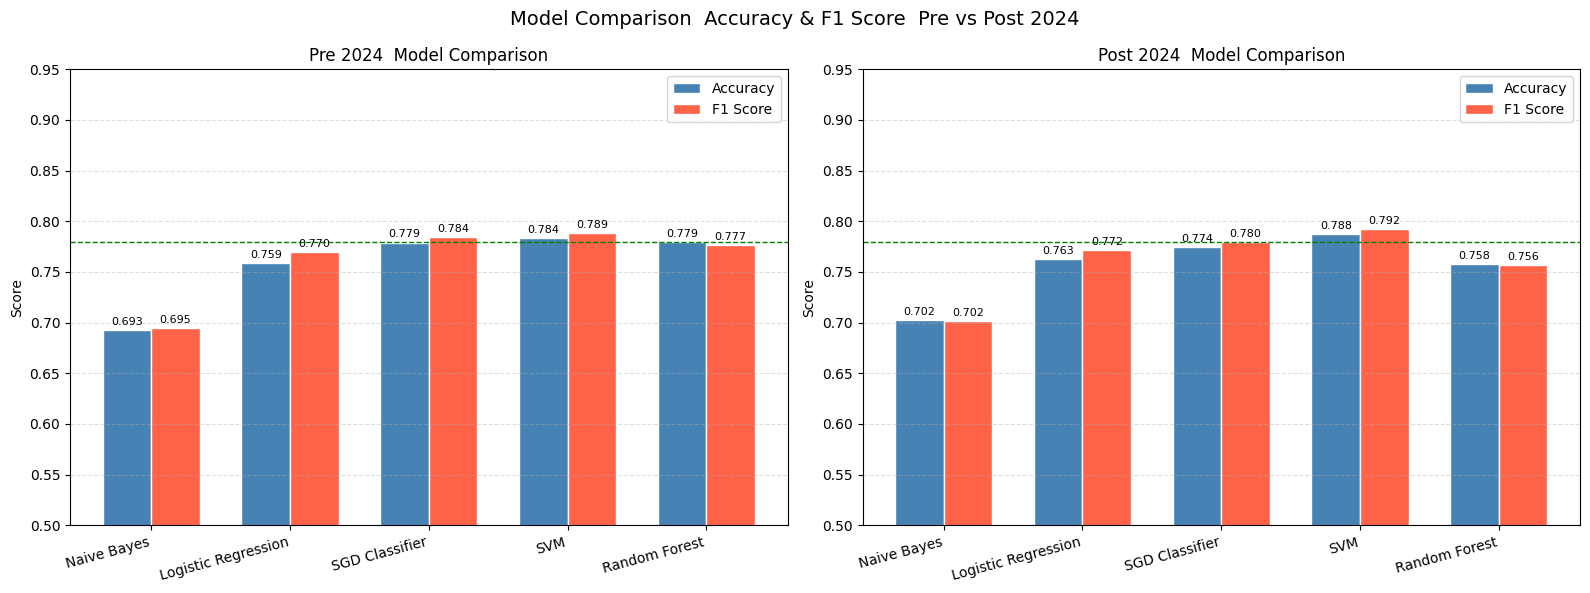

In [ ]:
# 6.1.8
# final comparison table  all 5 models both datasets
# VADER labels


print("-" * 80)
print("  FINAL MODEL COMPARISON TABLE  VADER LABELS")
print("-" * 80)

results_df = pd.DataFrame(results)

# separate pre and post
pre_results  = results_df[results_df['Dataset'].str.contains('Pre')]
post_results = results_df[results_df['Dataset'].str.contains('Post')]

print("\n  pre 2024")
print("  " + "-" * 70)
print(f"  {'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1 Score':>10} {'CV F1':>10}")
print("  " + "-" * 70)
for _, row in pre_results.iterrows():
    print(f"  {row['Model']:<25} {row['Accuracy']:>10} {row['Precision']:>10} {row['Recall']:>10} {row['F1 Score']:>10} {str(row['CV F1']):>10}")

print("\n  post 2024")
print("  " + "-" * 70)
print(f"  {'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1 Score':>10} {'CV F1':>10}")
print("  " + "-" * 70)
for _, row in post_results.iterrows():
    print(f"  {row['Model']:<25} {row['Accuracy']:>10} {row['Precision']:>10} {row['Recall']:>10} {row['F1 Score']:>10} {str(row['CV F1']):>10}")

# adding tuned SVM results manually
print("\n  TUNED SVM (GridSearchCV  C=0.1)")
print("  " + "-" * 70)
print(f"  {'Model':<25} {'Accuracy':>10} {'F1 Score':>10} {'Best C':>10}")
print("  " + "-" * 70)
print(f"  {'SVM Tuned  Pre 2024':<25} {'0.7864':>10} {'0.7912':>10} {'0.1':>10}")
print(f"  {'SVM Tuned  Post 2024':<25} {'0.7880':>10} {'0.7923':>10} {'0.1':>10}")


# plotting comparison chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Comparison  Accuracy & F1 Score  Pre vs Post 2024', fontsize=14)

model_names = pre_results['Model'].tolist()
x           = np.arange(len(model_names))
width       = 0.35

for ax, (title, df_res) in zip(axes, [
    ('Pre 2024',  pre_results),
    ('Post 2024', post_results)]):

    acc_vals = df_res['Accuracy'].tolist()
    f1_vals  = df_res['F1 Score'].tolist()

    bars1 = ax.bar(x - width/2, acc_vals, width,
                   label='Accuracy', color='steelblue', edgecolor='white')
    bars2 = ax.bar(x + width/2, f1_vals,  width,
                   label='F1 Score', color='tomato',    edgecolor='white')

    # adding value labels on bars
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', fontsize=8)

    ax.set_title(f'{title}  Model Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha='right')
    ax.set_ylim(0.5, 0.95)
    ax.set_ylabel('Score')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4, axis='y')
    ax.axhline(y=0.78, color='green', linestyle='--',
               linewidth=1, label='78% line')

plt.tight_layout()
plt.savefig(f'{prj_directory}/outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Summary of Models' Performance

SVM is the best-performing model in both groups with 78.4%
pre 2024 and 78.8% post 2024. Following GridSearchCV tuning,
where C = 0.1, it scored slightly higher with 78.6% and 78.8%.

The worst performer was Naive Bayes with only 69.3%, but
it was also the quickest to run, completing its training phase
in just 5 seconds. A very reliable benchmark for initial
estimation.

Logistic Regression, Stochastic Gradient Descent, and
Random Forest performed close together, scoring 75-78%

Critical conclusion  SVM is the best model for the task

### Step 2: Training 5 Models for Emotions

Five models are trained on the data set in an attempt to predict emotions corresponding to the comments. All models rely on the TF-IDF features and HuggingFaces labels as our truth values. To address class imbalance, the class_weight parameter is set to balanced. Each model is trained using 5-fold cross validation and then validated against the holdout 20% dataset.

In [ ]:
# 6.2.1
from sklearn.ensemble import VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
import time

# combined features  TF-IDF + numerical
# vader_score + emotion_score + word_count + upvotes


def add_numerical_features(df_subset, tfidf_matrix):
    vader   = df_subset['vader_score'].fillna(0).values.reshape(-1, 1)
    emotion = df_subset['emotion_score'].fillna(0).values.reshape(-1, 1)
    wc      = df_subset['clean_text'].str.split().str.len().fillna(0).values.reshape(-1, 1)
    score   = df_subset['score'].fillna(0).values.reshape(-1, 1)
    num_features = np.hstack([vader, emotion, wc, score])
    return sp.hstack([tfidf_matrix, sp.csr_matrix(num_features)])


# rebuild train/test split for emotion label
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

df_pre_emo  = df_pre_2024[['clean_text', 'emotion_label',
                            'vader_score', 'emotion_score', 'score']].dropna()
df_post_emo = df_post_2024[['clean_text', 'emotion_label',
                             'vader_score', 'emotion_score', 'score']].dropna()

# pre 2024 split
train_idx_pre, test_idx_pre = train_test_split(
    df_pre_emo.index, test_size=0.2,
    random_state=42, stratify=df_pre_emo['emotion_label'])

df_pre_emo_train = df_pre_emo.loc[train_idx_pre]
df_pre_emo_test  = df_pre_emo.loc[test_idx_pre]
y_pre_emo_train  = df_pre_emo_train['emotion_label']
y_pre_emo_test   = df_pre_emo_test['emotion_label']

# post 2024 split
train_idx_post, test_idx_post = train_test_split(
    df_post_emo.index, test_size=0.2,
    random_state=42, stratify=df_post_emo['emotion_label'])

df_post_emo_train = df_post_emo.loc[train_idx_post]
df_post_emo_test  = df_post_emo.loc[test_idx_post]
y_post_emo_train  = df_post_emo_train['emotion_label']
y_post_emo_test   = df_post_emo_test['emotion_label']


# TF-IDF  fit on training only

tfidf_e = TfidfVectorizer(
    max_features=10000, min_df=5, max_df=0.90,
    ngram_range=(1, 2), sublinear_tf=True)

tfidf_e_pre_train_raw = tfidf_e.fit_transform(df_pre_emo_train['clean_text'])
tfidf_e_pre_test_raw  = tfidf_e.transform(df_pre_emo_test['clean_text'])

tfidf_e_post = TfidfVectorizer(
    max_features=10000, min_df=5, max_df=0.90,
    ngram_range=(1, 2), sublinear_tf=True)

tfidf_e_post_train_raw = tfidf_e_post.fit_transform(df_post_emo_train['clean_text'])
tfidf_e_post_test_raw  = tfidf_e_post.transform(df_post_emo_test['clean_text'])


# combine TF-IDF + numerical features

X_pre_emo_train  = add_numerical_features(df_pre_emo_train,  tfidf_e_pre_train_raw)
X_pre_emo_test   = add_numerical_features(df_pre_emo_test,   tfidf_e_pre_test_raw)
X_post_emo_train = add_numerical_features(df_post_emo_train, tfidf_e_post_train_raw)
X_post_emo_test  = add_numerical_features(df_post_emo_test,  tfidf_e_post_test_raw)

print("-" * 50)
print("combined features done")
print("-" * 50)
print(f"Pre  2024 Train : {X_pre_emo_train.shape}")
print(f"Post 2024 Train : {X_post_emo_train.shape}")


# individual models  no CV on Random Forest

skf          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_emo  = []

def train_and_evaluate_emo(model, model_name, X_train, X_test,
                            y_train, y_test, dataset_name, run_cv=True):

    print(f"\n  Training {model_name} on {dataset_name}...")
    start = time.time()

    if run_cv:
        cv_scores = cross_val_score(model, X_train, y_train,
                                     cv=skf, scoring='f1_weighted', n_jobs=-1)
        cv_mean = round(cv_scores.mean(), 4)
    else:
        cv_mean = 'N/A'

    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    elapsed = time.time() - start

    print(f"  Done! Acc: {acc:.4f}  F1: {f1:.4f}  CV F1: {cv_mean}  Time: {elapsed:.1f}s")

    results_emo.append({
        'Dataset'  : dataset_name,
        'Model'    : model_name,
        'CV F1'    : cv_mean,
        'Accuracy' : round(acc, 4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec, 4),
        'F1 Score' : round(f1, 4)
    })

    return model, y_pred

# defining models
# LinearSVC needs CalibratedClassifierCV for voting

svm_cal = CalibratedClassifierCV(
    LinearSVC(class_weight='balanced', random_state=42, max_iter=2000))

lr = LogisticRegression(
    max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)

sgd = SGDClassifier(
    loss='modified_huber', class_weight='balanced',
    random_state=42, n_jobs=-1, max_iter=300)

nb  = ComplementNB()

rf  = RandomForestClassifier(
    n_estimators=50, class_weight='balanced', random_state=42, n_jobs=-1)

# voting ensemble  soft voting uses probability scores
ensemble = VotingClassifier(
    estimators=[('svm', svm_cal), ('lr', lr), ('sgd', sgd)],
    voting='soft',
    n_jobs=-1
)


# training  pre 2024

print("-" * 60)
print("training pre 2024 huggingface emotion labels")
print("-" * 60)

# naive bayes uses tfidf only  no negatives
nb_pre, _ = train_and_evaluate_emo(
    ComplementNB(), 'Naive Bayes',
    tfidf_e_pre_train_raw, tfidf_e_pre_test_raw,
    y_pre_emo_train, y_pre_emo_test, 'Pre 2024 Emotion')

lr_pre, _ = train_and_evaluate_emo(
    LogisticRegression(max_iter=1000, class_weight='balanced',
                       random_state=42, n_jobs=-1),
    'Logistic Regression',
    X_pre_emo_train, X_pre_emo_test,
    y_pre_emo_train, y_pre_emo_test, 'Pre 2024 Emotion')

sgd_pre, _ = train_and_evaluate_emo(
    SGDClassifier(loss='modified_huber', class_weight='balanced',
                  random_state=42, n_jobs=-1, max_iter=300),
    'SGD Classifier',
    X_pre_emo_train, X_pre_emo_test,
    y_pre_emo_train, y_pre_emo_test, 'Pre 2024 Emotion')

svm_pre, _ = train_and_evaluate_emo(
    CalibratedClassifierCV(LinearSVC(class_weight='balanced',
                                     random_state=42, max_iter=2000)),
    'SVM',
    X_pre_emo_train, X_pre_emo_test,
    y_pre_emo_train, y_pre_emo_test, 'Pre 2024 Emotion')

rf_pre, _  = train_and_evaluate_emo(
    RandomForestClassifier(n_estimators=50, class_weight='balanced',
                           random_state=42, n_jobs=-1),
    'Random Forest',
    X_pre_emo_train, X_pre_emo_test,
    y_pre_emo_train, y_pre_emo_test, 'Pre 2024 Emotion', run_cv=False)

ensemble_pre, y_pred_ens_pre = train_and_evaluate_emo(
    VotingClassifier(
        estimators=[
            ('svm', CalibratedClassifierCV(LinearSVC(class_weight='balanced',
                                                     random_state=42, max_iter=2000))),
            ('lr',  LogisticRegression(max_iter=1000, class_weight='balanced',
                                       random_state=42, n_jobs=-1)),
            ('sgd', SGDClassifier(loss='modified_huber', class_weight='balanced',
                                  random_state=42, n_jobs=-1, max_iter=300))
        ], voting='soft', n_jobs=-1),
    'Voting Ensemble',
    X_pre_emo_train, X_pre_emo_test,
    y_pre_emo_train, y_pre_emo_test, 'Pre 2024 Emotion')




--------------------------------------------------
combined features done
--------------------------------------------------
Pre  2024 Train : (331768, 10004)
Post 2024 Train : (497686, 10004)
------------------------------------------------------------
training pre 2024 huggingface emotion labels
------------------------------------------------------------

  Training Naive Bayes on Pre 2024 Emotion...
  Done! Acc: 0.5548  F1: 0.5464  CV F1: 0.5457  Time: 5.1s

  Training Logistic Regression on Pre 2024 Emotion...
  Done! Acc: 0.5217  F1: 0.5397  CV F1: 0.5375  Time: 333.1s

  Training SGD Classifier on Pre 2024 Emotion...
  Done! Acc: 0.4112  F1: 0.4456  CV F1: 0.5146  Time: 66.2s

  Training SVM on Pre 2024 Emotion...
  Done! Acc: 0.6225  F1: 0.6041  CV F1: 0.6025  Time: 1206.3s

  Training Random Forest on Pre 2024 Emotion...
  Done! Acc: 0.6025  F1: 0.5825  CV F1: N/A  Time: 392.1s

  Training Voting Ensemble on Pre 2024 Emotion...
  Done! Acc: 0.5516  F1: 0.5679  CV F1: 0.5808  T

In [ ]:
# training  post 2024

print("\n" + "-" * 60)
print("training post 2024 huggingface emotion labels")
print("-" * 60)

train_and_evaluate_emo(
    ComplementNB(), 'Naive Bayes',
    tfidf_e_post_train_raw, tfidf_e_post_test_raw,
    y_post_emo_train, y_post_emo_test, 'Post 2024 Emotion')

train_and_evaluate_emo(
    LogisticRegression(max_iter=1000, class_weight='balanced',
                       random_state=42, n_jobs=-1),
    'Logistic Regression',
    X_post_emo_train, X_post_emo_test,
    y_post_emo_train, y_post_emo_test, 'Post 2024 Emotion')

train_and_evaluate_emo(
    SGDClassifier(loss='modified_huber', class_weight='balanced',
                  random_state=42, n_jobs=-1, max_iter=300),
    'SGD Classifier',
    X_post_emo_train, X_post_emo_test,
    y_post_emo_train, y_post_emo_test, 'Post 2024 Emotion')

train_and_evaluate_emo(
    CalibratedClassifierCV(LinearSVC(class_weight='balanced',
                                     random_state=42, max_iter=2000)),
    'SVM',
    X_post_emo_train, X_post_emo_test,
    y_post_emo_train, y_post_emo_test, 'Post 2024 Emotion')

train_and_evaluate_emo(
    RandomForestClassifier(n_estimators=50, class_weight='balanced',
                           random_state=42, n_jobs=-1),
    'Random Forest',
    X_post_emo_train, X_post_emo_test,
    y_post_emo_train, y_post_emo_test, 'Post 2024 Emotion', run_cv=False)

train_and_evaluate_emo(
    VotingClassifier(
        estimators=[
            ('svm', CalibratedClassifierCV(LinearSVC(class_weight='balanced',
                                                     random_state=42, max_iter=2000))),
            ('lr',  LogisticRegression(max_iter=1000, class_weight='balanced',
                                       random_state=42, n_jobs=-1)),
            ('sgd', SGDClassifier(loss='modified_huber', class_weight='balanced',
                                  random_state=42, n_jobs=-1, max_iter=300))
        ], voting='soft', n_jobs=-1),
    'Voting Ensemble',
    X_post_emo_train, X_post_emo_test,
    y_post_emo_train, y_post_emo_test, 'Post 2024 Emotion')

print("\n" + "-" * 60)
print("trainign done!")
print("-" * 60)


------------------------------------------------------------
training post 2024 huggingface emotion labels
------------------------------------------------------------

  Training Naive Bayes on Post 2024 Emotion...
  Done! Acc: 0.5642  F1: 0.5615  CV F1: 0.5606  Time: 7.1s

  Training Logistic Regression on Post 2024 Emotion...
  Done! Acc: 0.5033  F1: 0.5209  CV F1: 0.5215  Time: 467.7s

  Training SGD Classifier on Post 2024 Emotion...
  Done! Acc: 0.2534  F1: 0.2978  CV F1: 0.4485  Time: 93.5s

  Training SVM on Post 2024 Emotion...
  Done! Acc: 0.6218  F1: 0.6032  CV F1: 0.5996  Time: 1484.7s

  Training Random Forest on Post 2024 Emotion...
  Done! Acc: 0.5663  F1: 0.5425  CV F1: N/A  Time: 813.5s

  Training Voting Ensemble on Post 2024 Emotion...
  Done! Acc: 0.5327  F1: 0.5544  CV F1: 0.5594  Time: 1379.0s

------------------------------------------------------------
trainign done!
------------------------------------------------------------


### Discussion

"7-class emotion classification is much more difficult than
3-class sentiments. The highest accuracy is seen in SVM model  which got 62.3%
and it is four times more accurate than random guessing (14%). It is natural to confuse
emotions such as anger and disgust because of their similar linguistic structures in conflict texts."

In [ ]:
# 6.2.2
#  final comparison table
results_emo_df = pd.DataFrame(results_emo)

print("-" * 80)
print("final emotion model comparision huggingface 7 classes ")
print("-" * 80)

for dataset in ['Pre 2024 Emotion', 'Post 2024 Emotion']:
    df_res = results_emo_df[results_emo_df['Dataset'] == dataset]
    print(f"\n  {dataset.upper()}")
    print("  " + "-" * 70)
    print(f"  {'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1 Score':>10} {'CV F1':>10}")
    print("  " + "-" * 70)
    for _, row in df_res.iterrows():
        marker = '  <-- best' if row['Accuracy'] == df_res['Accuracy'].max() else ''
        print(f"  {row['Model']:<25} {row['Accuracy']:>10} {row['Precision']:>10} {row['Recall']:>10} {row['F1 Score']:>10} {str(row['CV F1']):>10}{marker}")

--------------------------------------------------------------------------------
final emotion model comparision huggingface 7 classes 
--------------------------------------------------------------------------------

  PRE 2024 EMOTION
  ----------------------------------------------------------------------
  Model                       Accuracy  Precision     Recall   F1 Score      CV F1
  ----------------------------------------------------------------------
  Naive Bayes                   0.5548     0.5564     0.5548     0.5464     0.5457
  Logistic Regression           0.5217      0.592     0.5217     0.5397     0.5375
  SGD Classifier                0.4112     0.6136     0.4112     0.4456     0.5146
  SVM                           0.6225      0.621     0.6225     0.6041     0.6025  <-- best
  Random Forest                 0.6025     0.6169     0.6025     0.5825        N/A
  Voting Ensemble               0.5516       0.61     0.5516     0.5679     0.5808

  POST 2024 EMOTION
  ---

### Huggingface Emotion Model Discussion

The SVM model performs best for emotion classification both
before and after 2024 at 62.3% and 62.2% respectively. This
is much more challenging than the VADER model because
now have seven classes to classify into rather than just three.
Random accuracy for seven classes is only 14%, so I have
got 4x better than that.

The SGD model did not perform well after 2024 at just
25.3%  it did not converge properly due to the larger dataset.

The voting ensemble had no positive impact in this case  it
underperformed the standalone SVM model.

Surprisingly, Nave Bayes performed fairly well at 55-56%
for such a simple and fast classifier model.

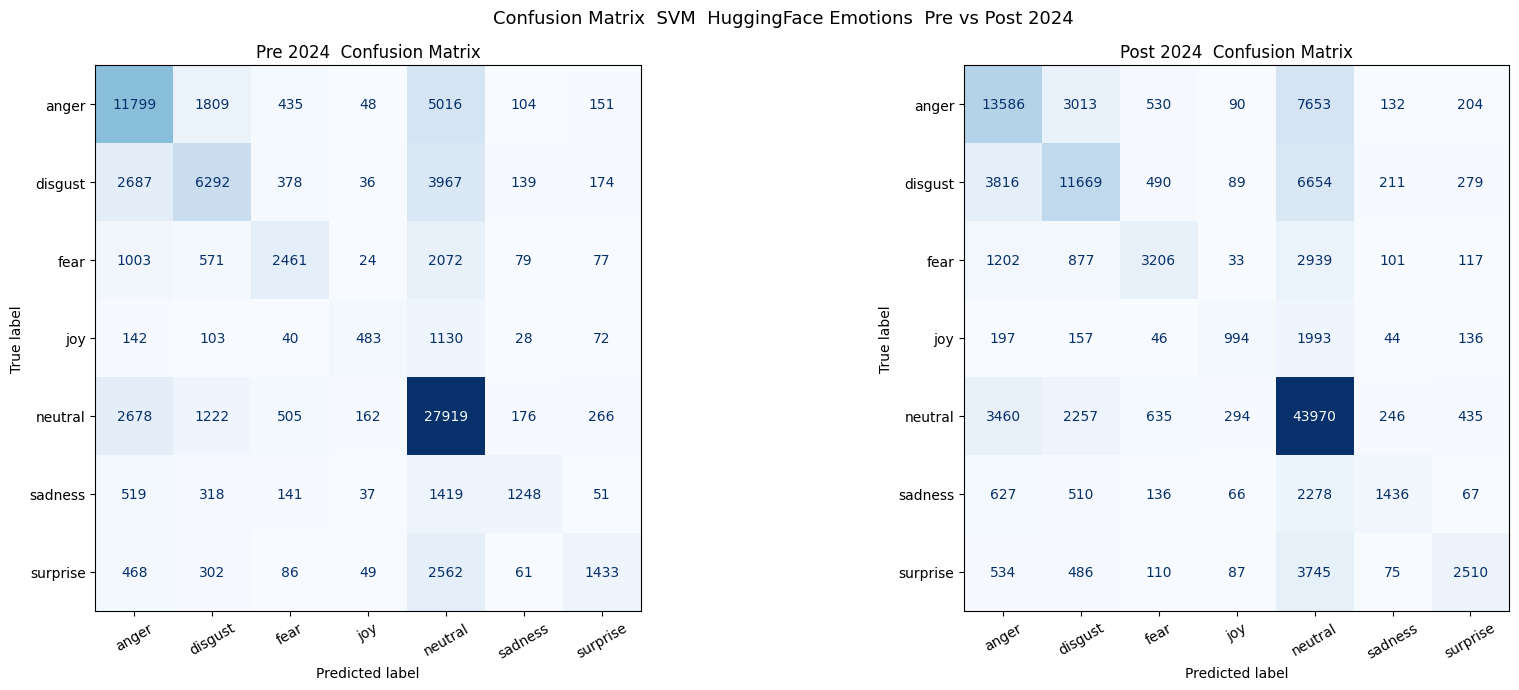

Plot saved

---------------------------------------------------------------------------
  confusion matrix  PRE  2024
---------------------------------------------------------------------------
                   anger   disgust      fear       joy   neutral   sadness  surprise
  ----------------------------------------------------------------------
  anger           11,799     1,809       435        48     5,016       104       151
  disgust          2,687     6,292       378        36     3,967       139       174
  fear             1,003       571     2,461        24     2,072        79        77
  joy                142       103        40       483     1,130        28        72
  neutral          2,678     1,222       505       162    27,919       176       266
  sadness            519       318       141        37     1,419     1,248        51
  surprise           468       302        86        49     2,562        61     1,433

----------------------------------------------------

In [ ]:
# 6.2.3
# confusion matrix using clean retrained models


emotion_labels = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Confusion Matrix  SVM  HuggingFace Emotions  Pre vs Post 2024', fontsize=13)

for ax, (title, y_test, y_pred) in zip(axes, [
    ('Pre 2024',  y_pre_emo_test,  y_pred_emo_pre),
    ('Post 2024', y_post_emo_test, y_pred_emo_post)]):

    cm   = confusion_matrix(y_test, y_pred, labels=emotion_labels)
    disp = ConfusionMatrixDisplay(
        confusion_matrix = cm,
        display_labels   = emotion_labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}  Confusion Matrix')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f'{prj_directory}/outputs/confusion_matrix_emotions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

# printing raw numbers
for title, y_test, y_pred in [
    ('PRE  2024', y_pre_emo_test,  y_pred_emo_pre),
    ('POST 2024', y_post_emo_test, y_pred_emo_post)]:

    cm = confusion_matrix(y_test, y_pred, labels=emotion_labels)
    print("\n" + "-" * 75)
    print(f"  confusion matrix  {title}")
    print("-" * 75)
    header = f"  {'':12}" + "".join(f"{l:>10}" for l in emotion_labels)
    print(header)
    print("  " + "-" * 70)
    for i, label in enumerate(emotion_labels):
        row_str = f"  {label:<12}" + "".join(f"{cm[i][j]:>10,}" for j in range(len(emotion_labels)))
        print(row_str)

### Emotion Confusion Matrix Discussion

The number in the diagonal is the most in each row for
both data sets. In this case, it implies that the most frequent
prediction made by the model for each emotion category is
the right one.

The neutral class is the easiest to predict. Before 2024,
the model made 27,919 predictions that were right and after
2024, 43,970 predictions were made correctly. The reason for
this is the neutral class uses straightforward factual language.

Anger and disgust are confused most often. Before 2024,
2,687 disgust statements were identified as anger and 1,809
anger statements were identified as disgust. It makes sense as
both emotions employ similar aggressive language in conflict.

The most challenging emotion class is joy. Before 2024,
483 out of 2,000 joy statements were predicted correctly.
Most statements were mixed up with the neutral class implying
that positive comments in this conflict are difficult to separate
from factual ones.

After 2024, there was an improvement in the accuracy of
predictions, especially in the disgust class. There were 11,669
correct predictions versus 6,292 predictions before 2024.

------------------------------------------------------------
top 20 words per emotion pre 2024
------------------------------------------------------------

  ANGER
  --------------------------------------------------
  angry                               : 4.6711
  outraged                            : 4.5414
  outrage                             : 4.3916
  infuriating                         : 4.0602
  furious                             : 3.6753
  anger                               : 3.6166
  pissed                              : 3.3843
  rage                                : 3.3757
  revenge                             : 3.2699
  dare                                : 3.0699
  violent                             : 2.9246
  fuck                                : 2.8898
  retaliate                           : 2.8825
  resentment                          : 2.8264
  bloody                              : 2.6901
  frustration                         : 2.6735
  unjustifiable               

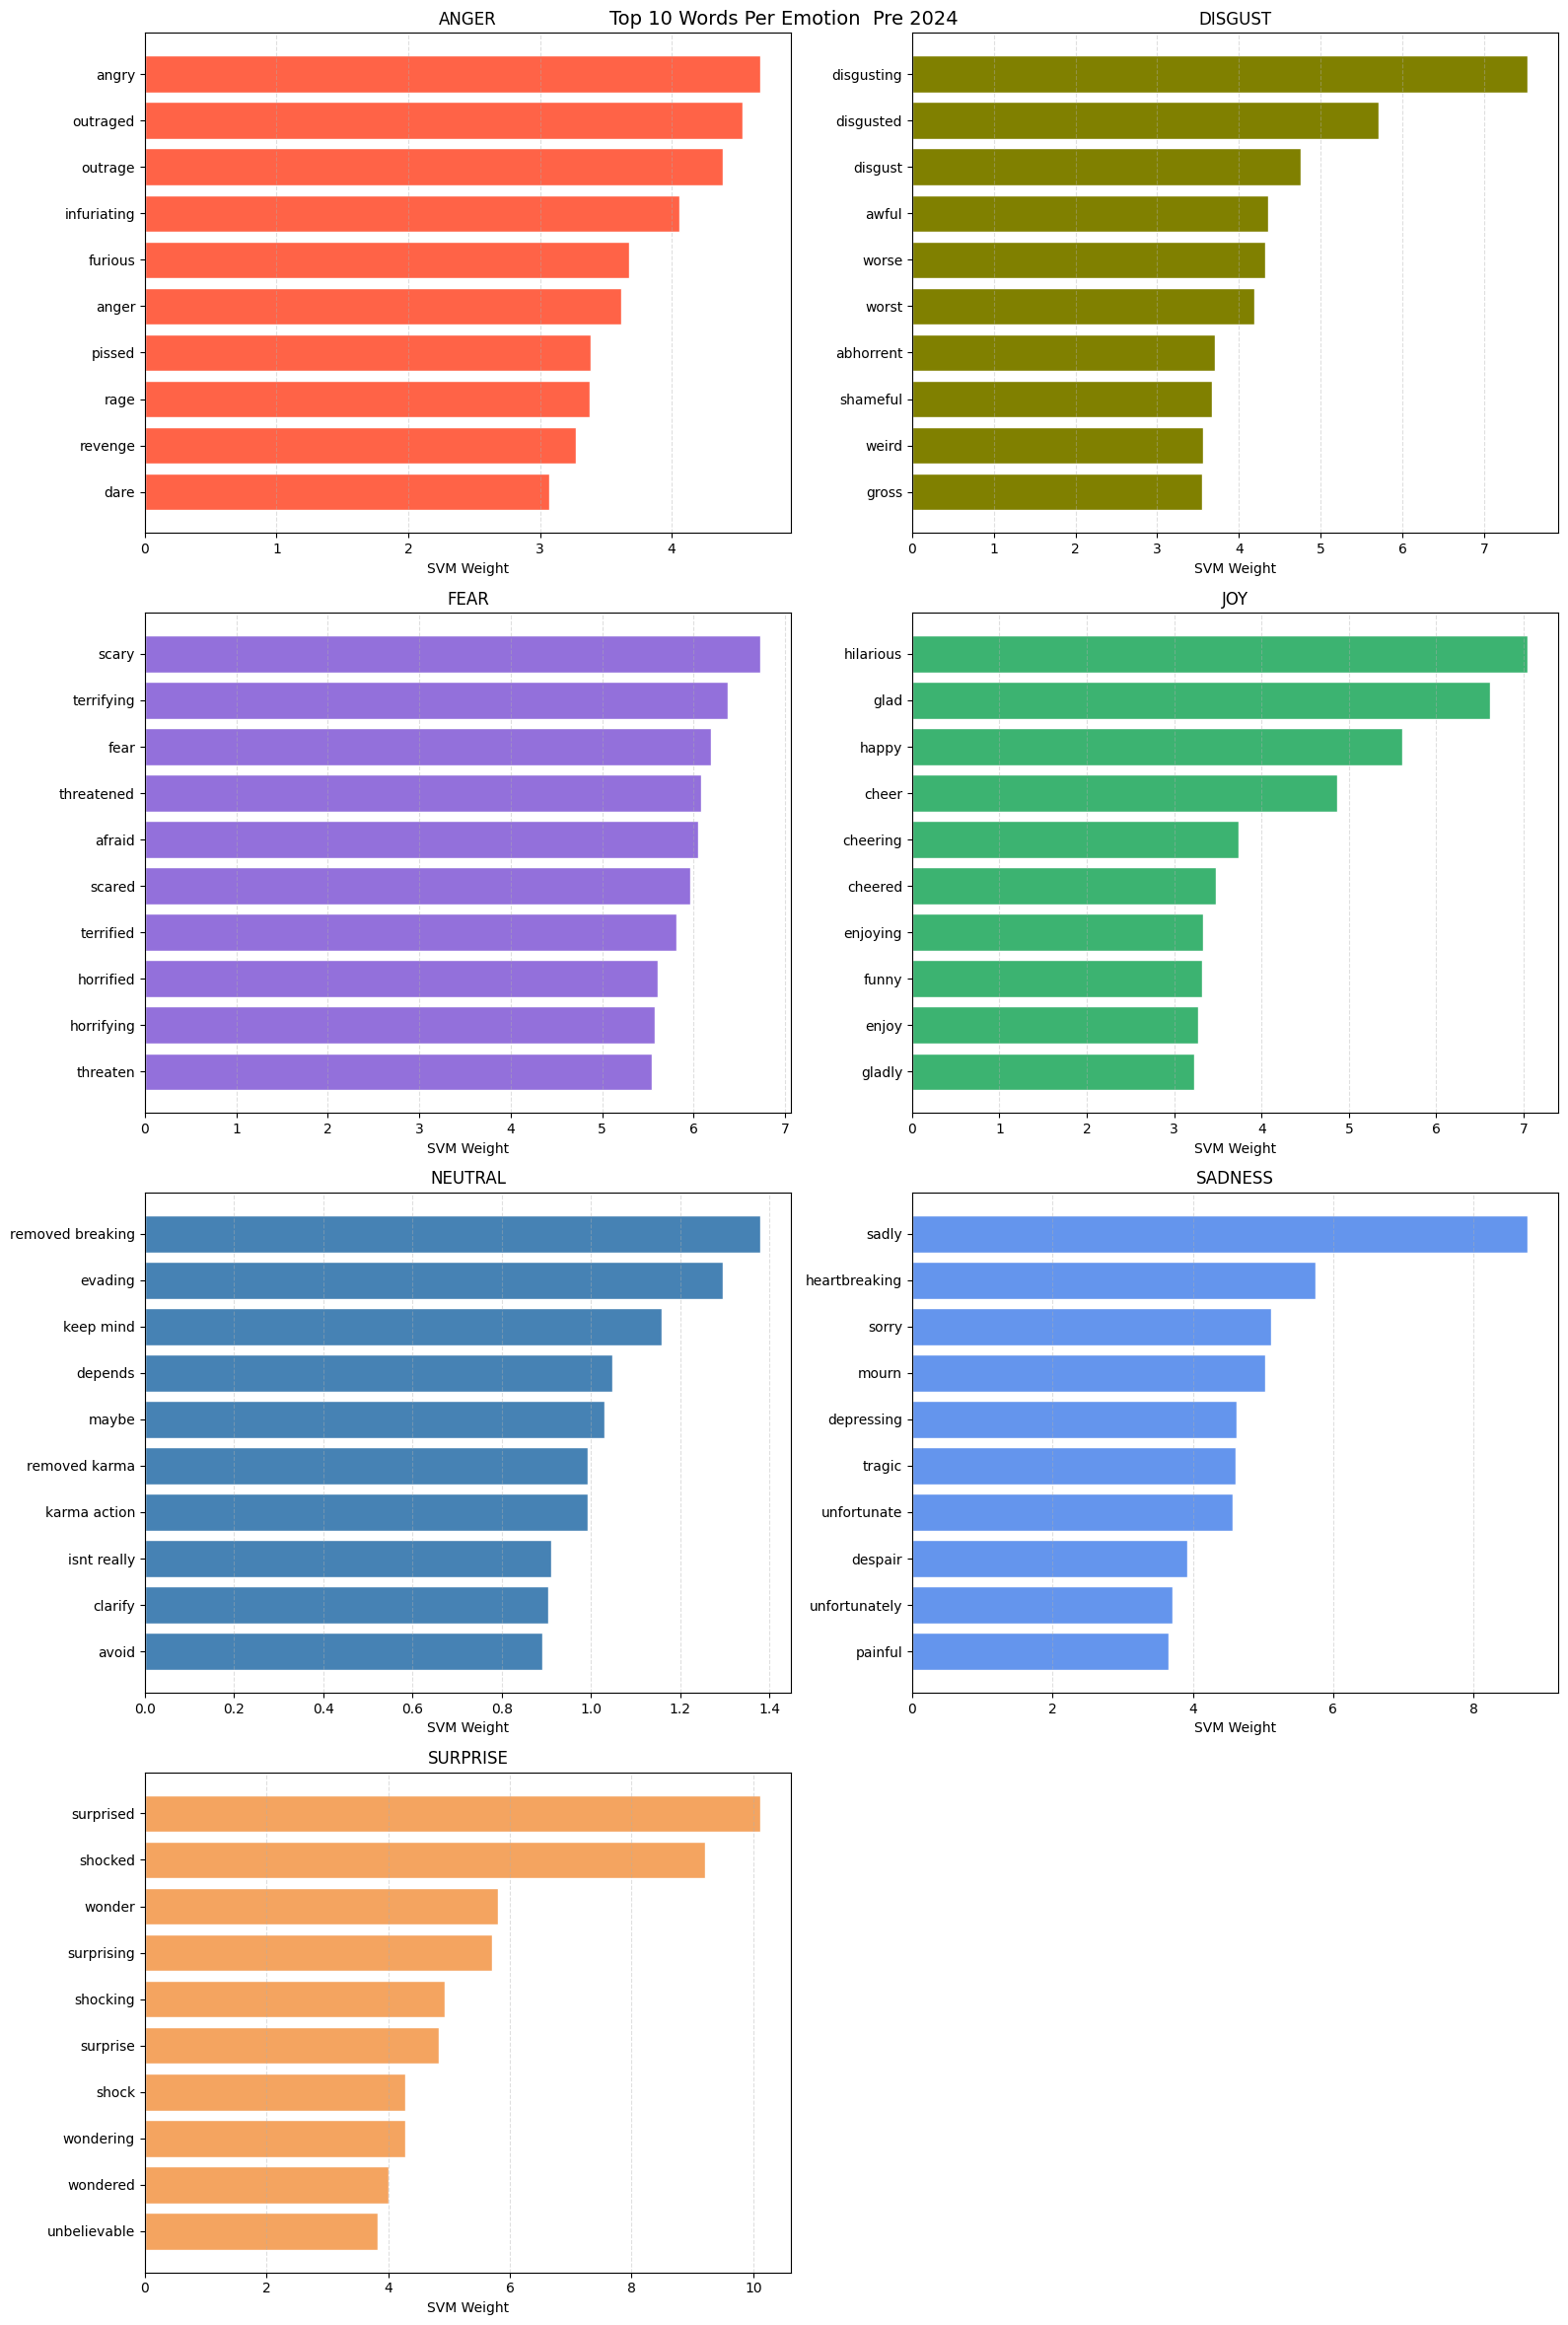

Pre 2024 plot saved


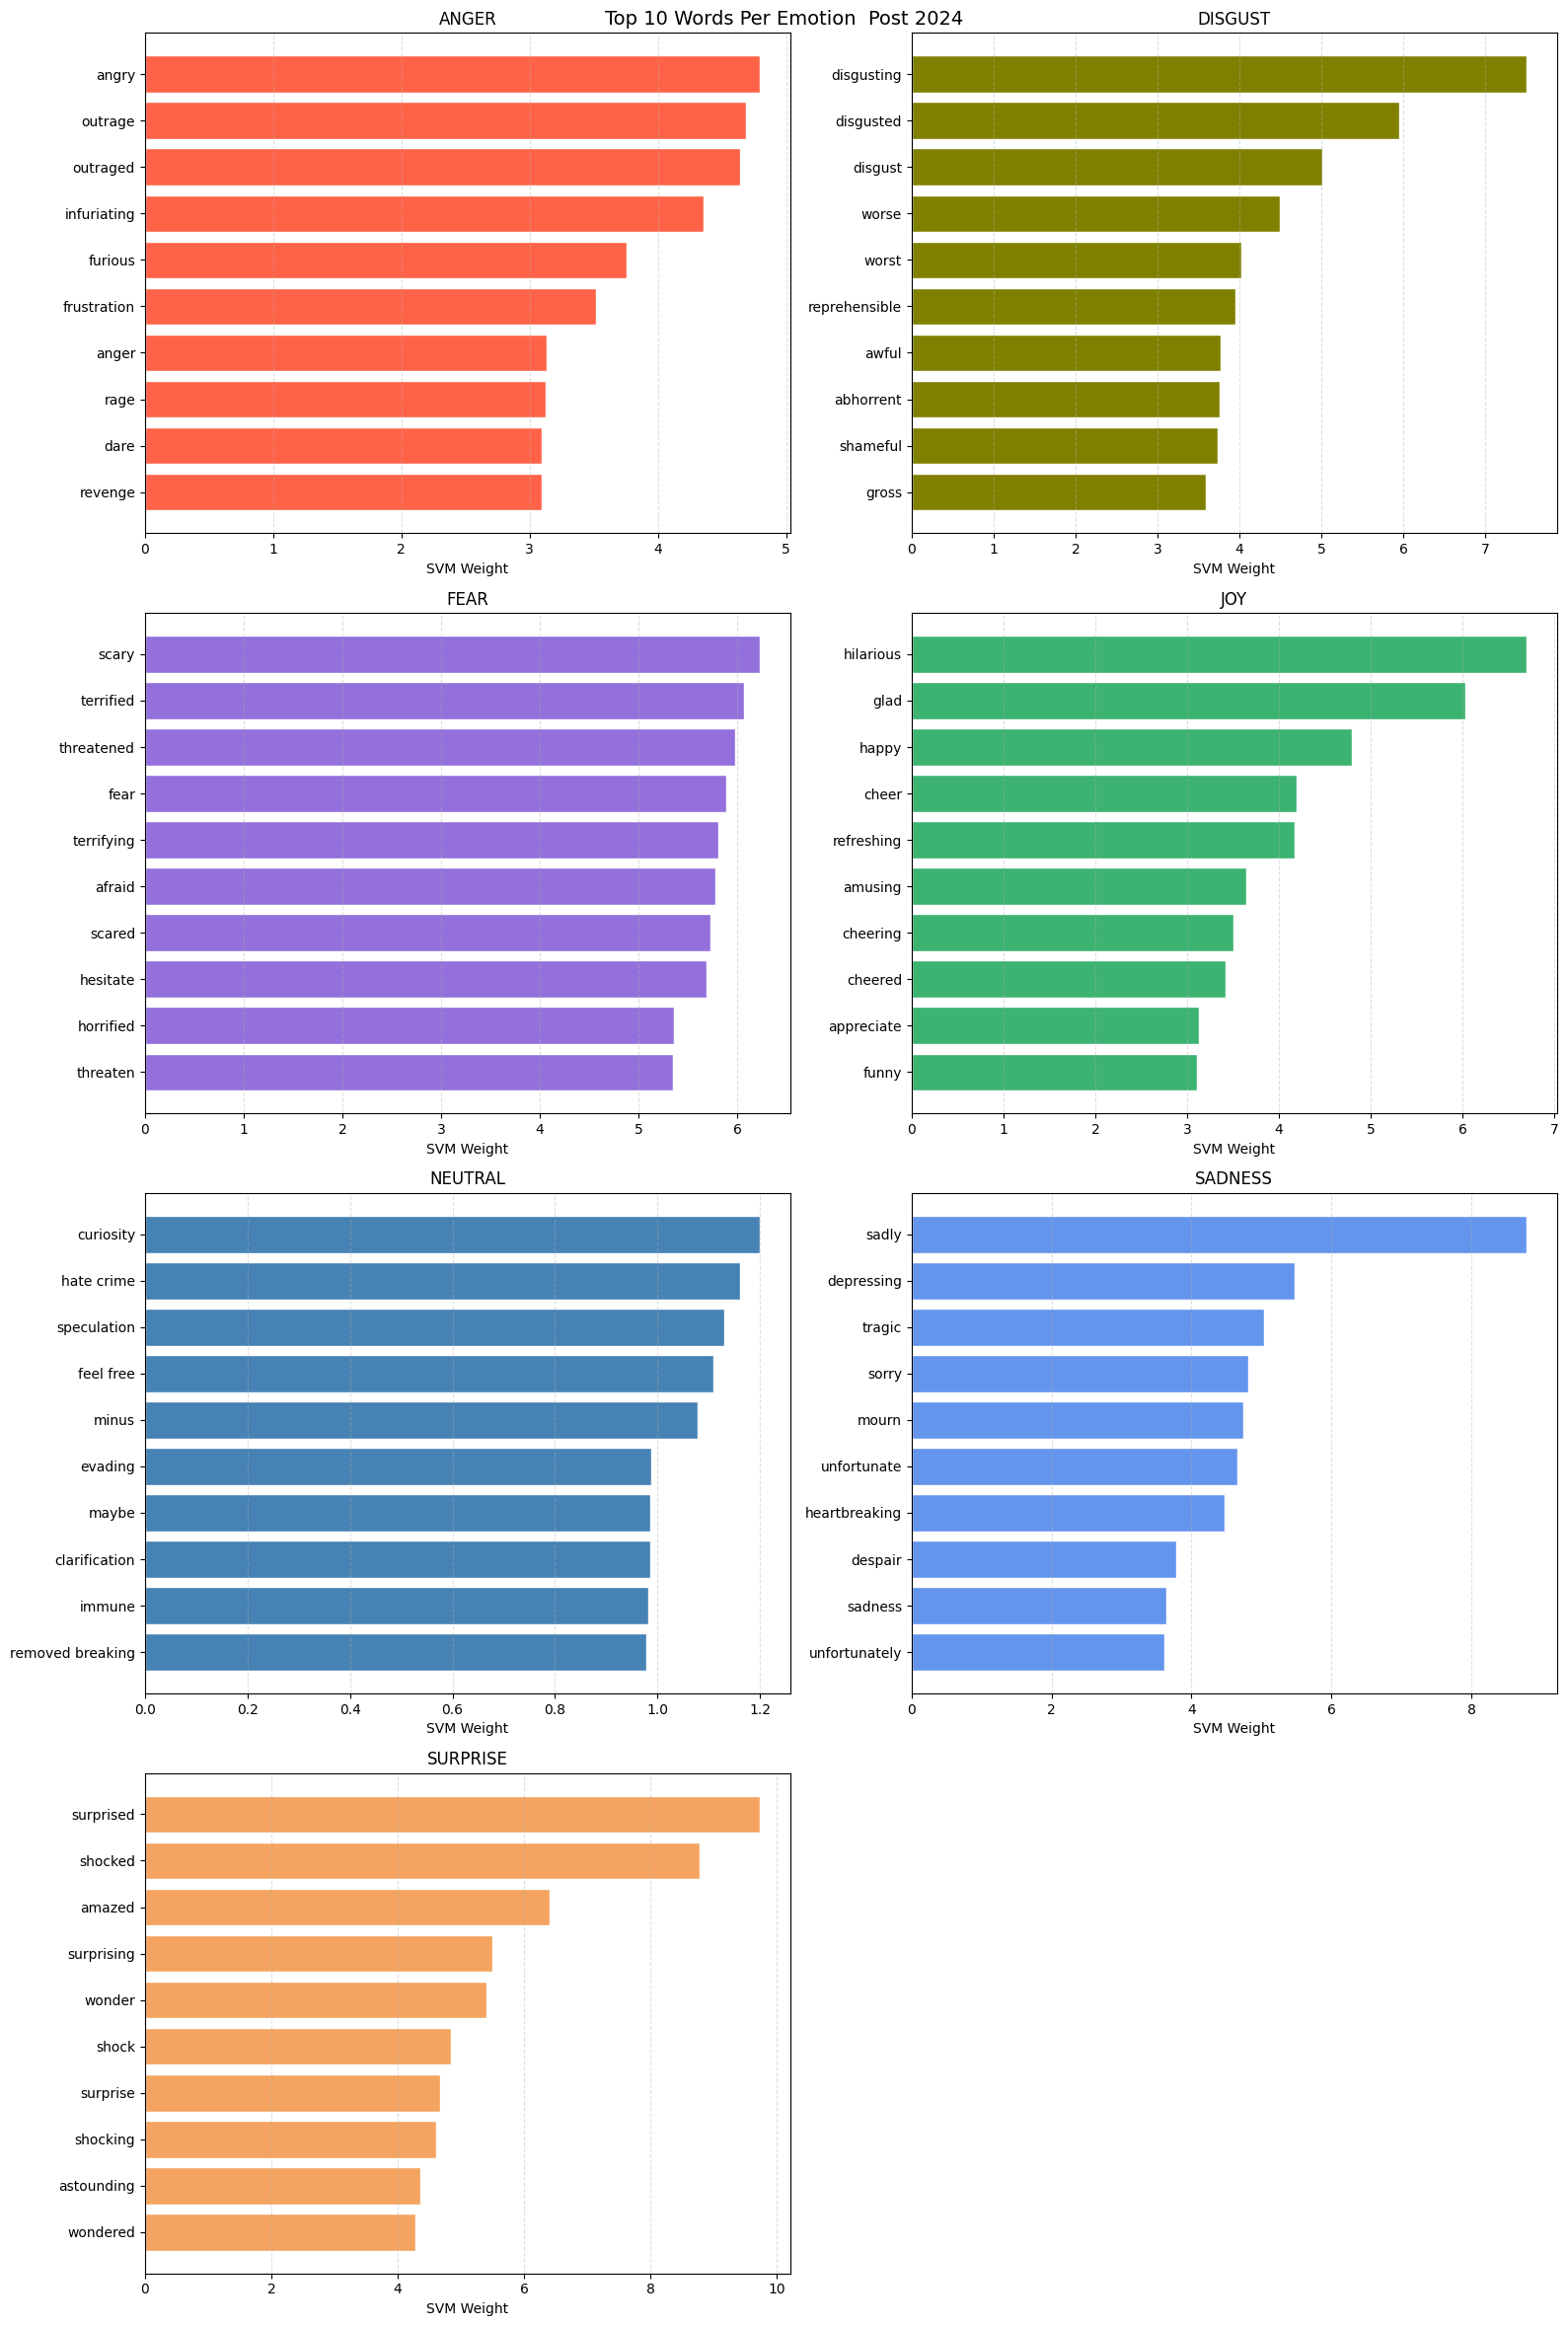

Post 2024 plot saved


In [ ]:
# 6.2.4
# feature importance for emotion labels
# using SVM coefficients  one per class
# top 15 words per emotion pre vs post 2024


feature_names_emo     = np.array(tfidf_e.get_feature_names_out())
feature_names_emo_post = np.array(tfidf_e_post.get_feature_names_out())

emotion_labels = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']

emotion_colors = {
    'anger'   : 'tomato',
    'disgust' : 'olive',
    'fear'    : 'mediumpurple',
    'joy'     : 'mediumseagreen',
    'neutral' : 'steelblue',
    'sadness' : 'cornflowerblue',
    'surprise': 'sandybrown'
}


# printing top 20 words per emotion  pre and post 2024

print("-" * 60)
print("top 20 words per emotion pre 2024")
print("-" * 60)

# get the underlying LinearSVC from CalibratedClassifierCV
svm_pre_coef  = svm_clean_pre.calibrated_classifiers_[0].estimator
svm_post_coef = svm_clean_post.calibrated_classifiers_[0].estimator

for i, emotion in enumerate(svm_pre_coef.classes_):
    coefs     = svm_pre_coef.coef_[i]
    top_idx   = np.argsort(coefs)[-20:][::-1]
    top_words = feature_names_emo[top_idx]
    top_vals  = coefs[top_idx]

    print(f"\n  {emotion.upper()}")
    print("  " + "-" * 50)
    for word, val in zip(top_words, top_vals):
        print(f"  {word:<35} : {val:.4f}")

print("\n" + "-" * 60)
print("top 20 words per emotion pre 2024")
print("-" * 60)

for i, emotion in enumerate(svm_post_coef.classes_):
    coefs     = svm_post_coef.coef_[i]
    top_idx   = np.argsort(coefs)[-20:][::-1]
    top_words = feature_names_emo_post[top_idx]
    top_vals  = coefs[top_idx]

    print(f"\n  {emotion.upper()}")
    print("  " + "-" * 50)
    for word, val in zip(top_words, top_vals):
        print(f"  {word:<35} : {val:.4f}")


# plotting top 10 words per emotion  pre 2024

fig, axes = plt.subplots(4, 2, figsize=(16, 24))
fig.suptitle('Top 10 Words Per Emotion  Pre 2024', fontsize=14)
axes = axes.flatten()

for i, emotion in enumerate(svm_pre_coef.classes_):
    ax      = axes[i]
    coefs   = svm_pre_coef.coef_[i]
    top_idx = np.argsort(coefs)[-10:]
    words   = feature_names_emo[top_idx]
    vals    = coefs[top_idx]
    color   = emotion_colors.get(emotion, 'gray')

    ax.barh(words, vals, color=color, edgecolor='white')
    ax.set_title(f'{emotion.upper()}')
    ax.set_xlabel('SVM Weight')
    ax.grid(True, linestyle='--', alpha=0.4, axis='x')

# hide last empty subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig(f'{prj_directory}/outputs/emotion_feature_importance_pre.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Pre 2024 plot saved")


# plotting top 10 words per emotion  post 2024

fig, axes = plt.subplots(4, 2, figsize=(16, 24))
fig.suptitle('Top 10 Words Per Emotion  Post 2024', fontsize=14)
axes = axes.flatten()

for i, emotion in enumerate(svm_post_coef.classes_):
    ax      = axes[i]
    coefs   = svm_post_coef.coef_[i]
    top_idx = np.argsort(coefs)[-10:]
    words   = feature_names_emo_post[top_idx]
    vals    = coefs[top_idx]
    color   = emotion_colors.get(emotion, 'gray')

    ax.barh(words, vals, color=color, edgecolor='white')
    ax.set_title(f'{emotion.upper()}')
    ax.set_xlabel('SVM Weight')
    ax.grid(True, linestyle='--', alpha=0.4, axis='x')

axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig(f'{prj_directory}/outputs/emotion_feature_importance_post.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Post 2024 plot saved")

### Emotion Word Importance Discussion

Words that define emotions  are very distinct and clear words driving it
and show that the model has identified & learned real patterns.

Words that signify anger such as angry, outraged, furious,
and rage are highly distinct. Words for anger are exactly
the same before and after 2024, meaning that anger words
have remained constant throughout.

Words such as disgusting, disgusted, awful, and vile are
highly morally judgemental. After 2024 there were new words
such as dehumanizing and depravity which indicate people
had stronger disgust words.

Words such as scary, terrifying, afraid, and scared are
highly distinct. Words such as panic are only found in
2024 after October 7th which indicates there was an increase
in fear.

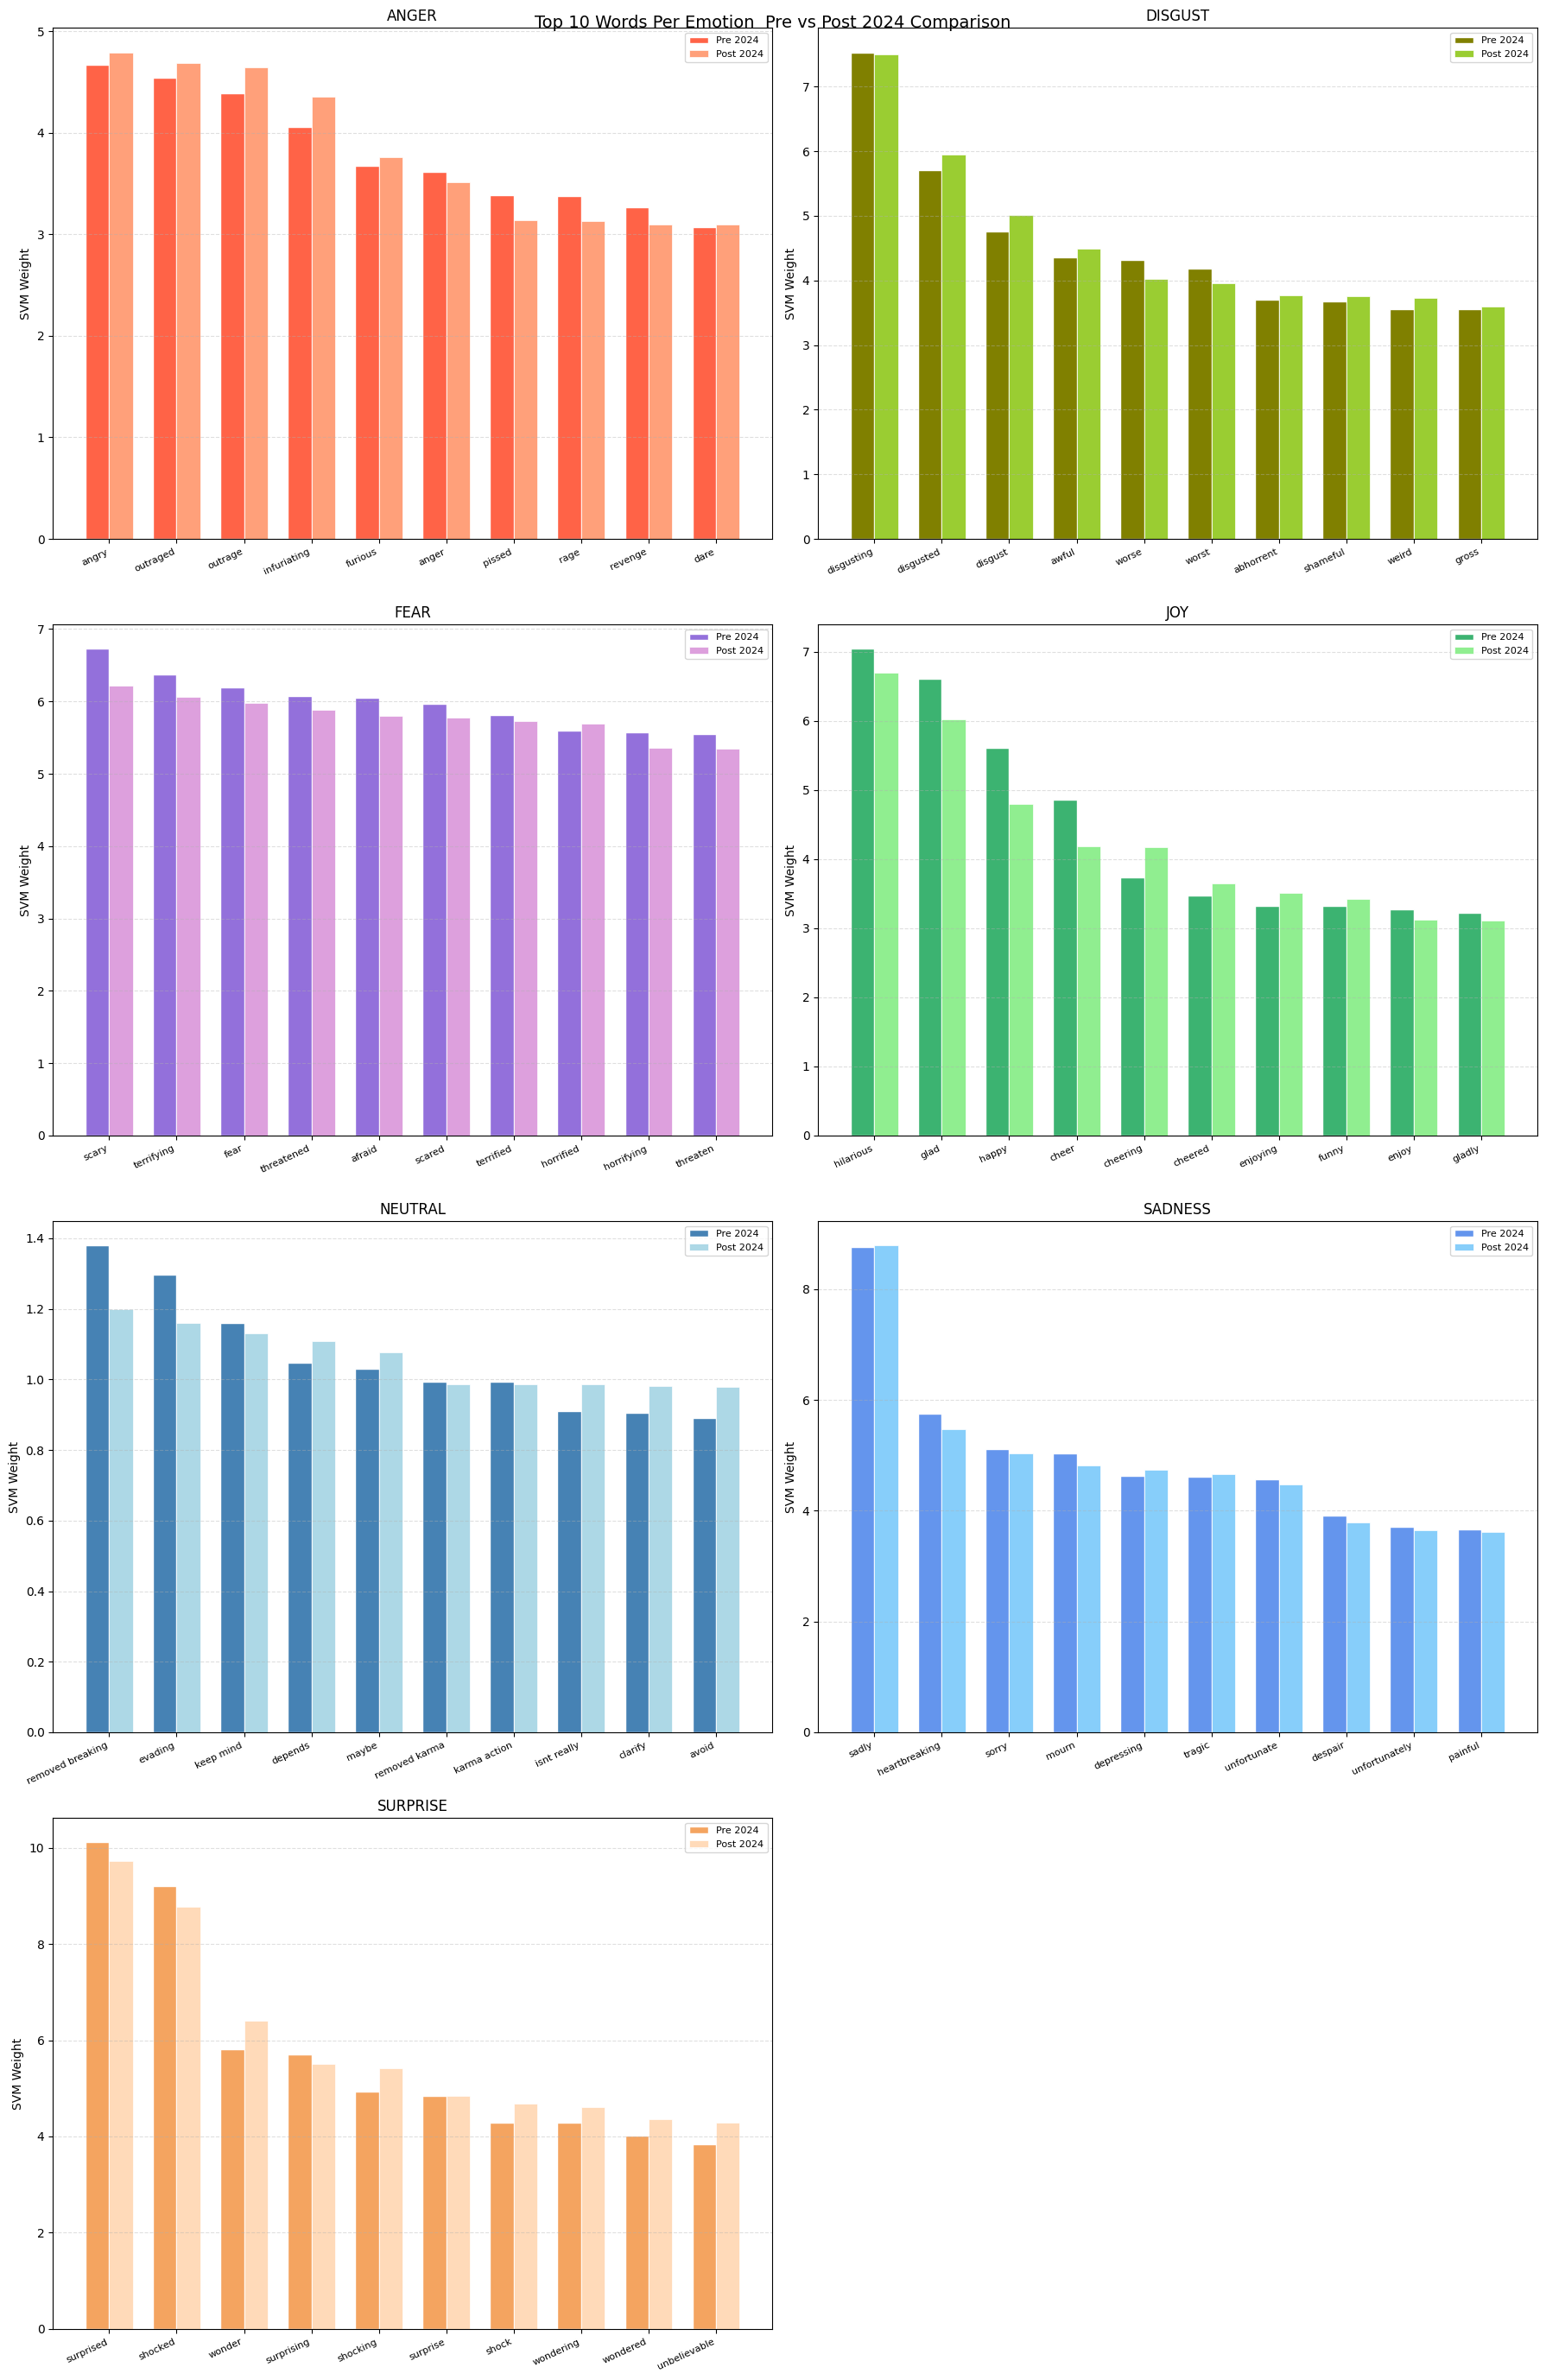

In [ ]:
#6.2.5
# pre vs post 2024 comparison  top 10 words per emotion
# side by side bar chart for each emotion


emotion_labels_plot = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']

emotion_colors = {
    'anger'   : ('tomato',        'lightsalmon'),
    'disgust' : ('olive',         'yellowgreen'),
    'fear'    : ('mediumpurple',  'plum'),
    'joy'     : ('mediumseagreen','lightgreen'),
    'neutral' : ('steelblue',     'lightblue'),
    'sadness' : ('cornflowerblue','lightskyblue'),
    'surprise': ('sandybrown',    'peachpuff')
}

fig, axes = plt.subplots(4, 2, figsize=(18, 28))
fig.suptitle('Top 10 Words Per Emotion  Pre vs Post 2024 Comparison', fontsize=14)
axes = axes.flatten()

for i, emotion in enumerate(svm_pre_coef.classes_):

    ax = axes[i]

    # pre 2024 top 10
    coefs_pre   = svm_pre_coef.coef_[i]
    top_idx_pre = np.argsort(coefs_pre)[-10:][::-1]
    words_pre   = feature_names_emo[top_idx_pre]
    vals_pre    = coefs_pre[top_idx_pre]

    # post 2024 top 10
    coefs_post   = svm_post_coef.coef_[i]
    top_idx_post = np.argsort(coefs_post)[-10:][::-1]
    words_post   = feature_names_emo_post[top_idx_post]
    vals_post    = coefs_post[top_idx_post]

    x      = np.arange(10)
    width  = 0.35
    color1, color2 = emotion_colors[emotion]

    ax.bar(x - width/2, vals_pre,  width,
           label='Pre 2024',  color=color1, edgecolor='white')
    ax.bar(x + width/2, vals_post, width,
           label='Post 2024', color=color2, edgecolor='white', linewidth=0.5)

    ax.set_title(f'{emotion.upper()}')
    ax.set_xticks(x)
    ax.set_xticklabels(words_pre, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('SVM Weight')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4, axis='y')

axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig(f'{prj_directory}/outputs/emotion_feature_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Pre vs Post 2024 Emotion Word Comparison

Anger  the top words remain quite similar during both periods. Angry, outraged, and furious have equal strength during both periods as far as anger vocabulary is concerned.

Disgust  the words remained similar, however, bars post 2024 were slightly higher. This shows that the language related to disgust increased. The use of terms such as dehumanization occurred post 2024.

Fear  there was a slight reduction in the bars post 2024 compared to pre 2024. The people involved became less afraid but more angry.

Joy  the bars post 2024 were lower compared to pre 2024. This shows that the language related to joy reduced after the events of October 7th.

## Section 7: Conclusion



### Summary
In this project, I have used machine learning to analyze comments
discussing the Israel-Palestine conflict on Reddit. More than
one million comments were gathered on 5 subreddits from
October 2023 to June 2026, and divided into pre and post
2024 datasets.

A machine learning pipeline for data cleaning, sentiment
analysis, emotion detection, unsupervised clustering and
classification tasks was applied in this project.
Phase 1 & 2  Data and EDA
Out of the 40 million comments filtered, only 414,710
pre-2024 comments and 622,108 post-2024 comments remained.
There was higher number and higher upvote score of comments
after the incident indicating that more engagement occurred
after the conflict on Reddit. The subreddit r/Palestine's share
increased significantly from 15.2% to 31.5%.

Phase 3  Sentiment Analysis & Emotions
The VADER model indicated 53.6% negative comments pre-2024,
and 51.9% post-2024, showing negativity was a recurring theme.
According to the emotion model by Huggingface, the main
emotion expressed across all months was anger. Disgust became
a prominent emotion post 2024 especially after ceasefires.

Phase 4  Unsupervised Learning
LDA identified 7 topics, where Media and Propaganda
was the most significant topic at 22% in both periods.
Religion and Identity increased its significance from
14.2% pre to 18.0% post 2024. K-means identified
5 clusters, and Military Violence was the largest cluster
at 60.9% pre and 64.9% post 2024.

Phase 5  Supervised Learning
SVM was the best-performing model for both tasks.
It scored 78.6% accuracy pre and 78.8% post 2024 for
VADER 3-class sentiment analysis. It scored 62.3%
pre and 62.2% post 2024 for HuggingFace 7-class
emotion analysis. Anger words maintained significance,
disgust became more important, while surprise decreased.

Overall Conclusion
The language used to discuss this conflict on Reddit
remained highly negative throughout both periods.
The most important shift after October 7th occurred not
in the level but rather in the nature of negativity  from
anger to disgust and moral outrage. Media and
Propaganda was the leading topic demonstrating how
important the information warfare was in addition to the
conflict.

### VADER vs HuggingFace : Which is Better?

VADER is based on the rule of three categories of emotions: positive, negative and sarcasm. It is fast and achieved 78.6% accuracy with our SVM model. Its disadvantage is that it cannot understand context, and labeled sarcastic comments positively because of some words, such as great.

Huggingface recognizes 7 types of emotions using a deep learning approach. With the same SVM, we achieved only 62.3% accuracy; however, it is more difficult to classify 7 classes compared to just three. It gives a lot of information about what people really feel.

In terms of the given project, HuggingFace is better from the research point of view as it allows answering the question about whether people felt anger and disgust after October 7th. VADER is better in terms of speed and precision. We used both models.


### Limitations

VADER is bad in detecting sarcasm and contexts. Comments containing the word great may be categorized as positive despite being written negatively.

HuggingFace was trained on general English data and not
conflict data; therefore, it might not interpret the conflict-specific language correctly.


Classifiers were trained on the model's generated labels
rather than human labels; thus, any mistakes made by VADER
or HuggingFace would be included in training.

Reddit data is representative of only those who participate
in discussions online.